# FINANCIAL DATA ANALYSIS WITH PYTHON - Portfolios

**Workflow:**
1.  **Part I:** Data Preparation
2.  **Part II:** Portfolio Optimization
3.  **Part III:** Algotithmic Trading
4.  **Part IV:** Conclusions and Indicator reports

## **PART I: DATA PREPARATION**

### 1: Setup and Global Imports

We will install and import all necessary libraries for the entire lecture here.

In [4]:
#SETUP 
import numpy as np
import pandas as pd
id_student = 11230992 
df_close = pd.read_csv('stock_close_prices.csv', index_col=0,parse_dates=True)
np.random.seed (id_student)
assets = np.random.choice(df_close.columns, size=5, replace=False).tolist()
print(f"Selected portfolio: {assets}")

Selected portfolio: ['KO', 'TSLA', 'AAPL', 'JNJ', 'PEP']


In [5]:
# --- 1. INSTALLATION ---

#!pip install yfinance plotly scipy statsmodels ta scikit-learn -q

# --- 2. GLOBAL IMPORTS ---
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pypfopt import CLA, plotting
import seaborn as sns
import itertools
import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller
from pypfopt import expected_returns, risk_models, EfficientFrontier, plotting
try:
    import ta
    print("TA-Lib imported successfully")
except ImportError:
    print("Optional: install ta library with 'pip install ta'")

import warnings
warnings.filterwarnings('ignore') 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x) 

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print("All libraries are ready for your financial data analysis project!")

TA-Lib imported successfully
All libraries are ready for your financial data analysis project!


### 2. Load Data 

To learn the foundational concepts, we will load a large dataset (5 years) as an example.

In [6]:
intro_tickers = ['KO', 'TSLA', 'AAPL', 'JNJ', 'PEP']
years_of_data = 5 # Load 5 years to have enough data for examples

# Load data
intro_end_date = pd.Timestamp.today()
intro_start_date = intro_end_date - pd.DateOffset(years=years_of_data)

print(f"Loading data for {len(intro_tickers)} tickers (For Part 1 introduction only)")

try:
    intro_raw_data = yf.download(intro_tickers, start=intro_start_date, end=intro_end_date)['Close']
    intro_raw_data = intro_raw_data.ffill().dropna() 
    print("Introductory data loaded successfully.")
    print(intro_raw_data.tail())
except Exception as e:
    print(f"ERROR: {e}")

Loading data for 5 tickers (For Part 1 introduction only)


[*********************100%***********************]  5 of 5 completed


Introductory data loaded successfully.
Ticker         AAPL      JNJ      KO      PEP     TSLA
Date                                                  
2025-11-28 278.8500 206.9200 72.6100 148.7400 430.1700
2025-12-01 283.1000 205.3400 71.9500 149.5100 430.1400
2025-12-02 286.1900 205.4200 70.6700 148.6100 429.2400
2025-12-03 284.1500 205.3300 70.8100 148.0600 446.7400
2025-12-04 280.7000 202.4800 70.4500 146.9100 454.5300


### 3. Time Series

- **Concept:** A **time series** is a sequence of data points indexed in time order. Its most critical characteristic is **time dependence**; the order of the data is paramount.
- **Tool:** In `pandas`, this is represented by a `DatetimeIndex`. This special index allows for intelligent access, slicing, and processing based on dates/months/years.
- **Code:**

In [7]:
print(f"Index Type: {type(intro_raw_data.index)}")

# Benefit of DatetimeIndex: Slicing
print("\nData from 2023:")
# We can slice using a 'YYYY-MM-DD' string or just 'YYYY'
print(intro_raw_data.loc['2023'].head())

Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Data from 2023:
Ticker         AAPL      JNJ      KO      PEP     TSLA
Date                                                  
2023-01-03 123.2112 162.6559 57.5192 164.0875 108.1000
2023-01-04 124.4820 164.4268 57.4917 163.6850 113.6400
2023-01-05 123.1619 163.2127 56.8339 161.9747 110.3400
2023-01-06 127.6936 164.5363 57.9303 165.6332 113.0600
2023-01-09 128.2157 160.2734 57.2085 164.0143 119.7700


### 4. Timezones

- **Concept:** Time data can be 'naive' (unaware of timezones) or 'aware' (has timezone information). Financial data must always be handled carefully regarding timezones (e.g., NYSE opening time vs. London time).
- **Tools:** 
  - `tz_localize(timezone_name)`: Assigns a timezone to naive data. Used once.
  - `tz_convert(timezone_name)`: Converts aware data from one timezone to another.
- **Code:**

In [8]:
print(f"Original Timezone Info: {intro_raw_data.index.tz}")

try:
    # 1. Localize (Assign the original market timezone - New York)
    data_localized = intro_raw_data.tz_localize('America/New_York', ambiguous='infer')
    print(f"Timezone after localization: {data_localized.index.tz}")
    print("New York Time:")
    print(data_localized.head(1))

    # 2. Convert (To Vietnam time)
    data_hcm = data_localized.tz_convert('Asia/Ho_Chi_Minh')
    print(f"\nTimezone after conversion: {data_hcm.index.tz}")
    print("Vietnam Time (corresponding):")
    print(data_hcm.head(1))
except TypeError as e:
    print(f"Error: {e}. Data may already be timezone-aware.")

Original Timezone Info: None
Timezone after localization: America/New_York
New York Time:
Ticker                        AAPL      JNJ      KO      PEP     TSLA
Date                                                                 
2020-12-07 00:00:00-05:00 120.4647 129.2447 45.5898 125.8143 213.9200

Timezone after conversion: Asia/Ho_Chi_Minh
Vietnam Time (corresponding):
Ticker                        AAPL      JNJ      KO      PEP     TSLA
Date                                                                 
2020-12-07 12:00:00+07:00 120.4647 129.2447 45.5898 125.8143 213.9200


- **Observation:** 00:00 (midnight) New York time (UTC-4 or -5) corresponds to 11:00 (or 12:00) AM Vietnam time (UTC+7). Timezone handling is critical when working with high-frequency (intraday) data.

### 5. Resampling (Changing Frequency)

- **Concept:** Resampling is the process of changing the frequency of data (e.g., from daily to monthly, or daily to hourly). There are 2 types:
  1. **Downsampling:** Aggregating data from a high frequency to a low frequency (e.g., daily -> monthly). Requires an **aggregation function**.
  2. **Upsampling:** Converting data from a low frequency to a high frequency (e.g., daily -> hourly). Requires a **filling method**.
- **Tools:**
  - `data.resample(new_frequency)`: Creates a Resampler object.
  - **Aggregation (Downsampling):** `.mean()`, `.last()`, `.sum()`, `.ohlc()`.
  - **Filling (Upsampling):** `.ffill()` (forward-fill), `.bfill()` (back-fill), `.asfreq()` (creates `NaN`).
- **Code (Downsampling):**

In [9]:
# Use 'AAPL' as an example
aapl = intro_raw_data[['AAPL']].copy().dropna()

# Downsampling: Daily -> Monthly ('M')
# We take the last value of each month
aapl_monthly = aapl.resample('M').last()
print("--- Monthly Data (Last value) ---")
print(aapl_monthly.head())

# Downsampling: Create weekly OHLC (Open-High-Low-Close) ('W')
aapl_ohlc_weekly = aapl['AAPL'].resample('W').ohlc()
print("\n--- Weekly OHLC Data --- (Open, High, Low, Close)")
print(aapl_ohlc_weekly.head())

--- Monthly Data (Last value) ---
Ticker         AAPL
Date               
2020-12-31 129.1674
2021-01-31 128.4567
2021-02-28 118.2172
2021-03-31 119.0849
2021-04-30 128.1613

--- Weekly OHLC Data --- (Open, High, Low, Close)
               open     high      low    close
Date                                          
2020-12-13 120.4647 121.0780 118.5470 119.1603
2020-12-20 118.5470 125.2833 118.5470 123.2975
2020-12-27 124.8258 128.4665 124.8258 128.4665
2021-01-03 133.0612 133.0612 129.1674 129.1674
2021-01-10 125.9745 128.5444 123.2391 128.5444


- **Visualization (Downsampling):**

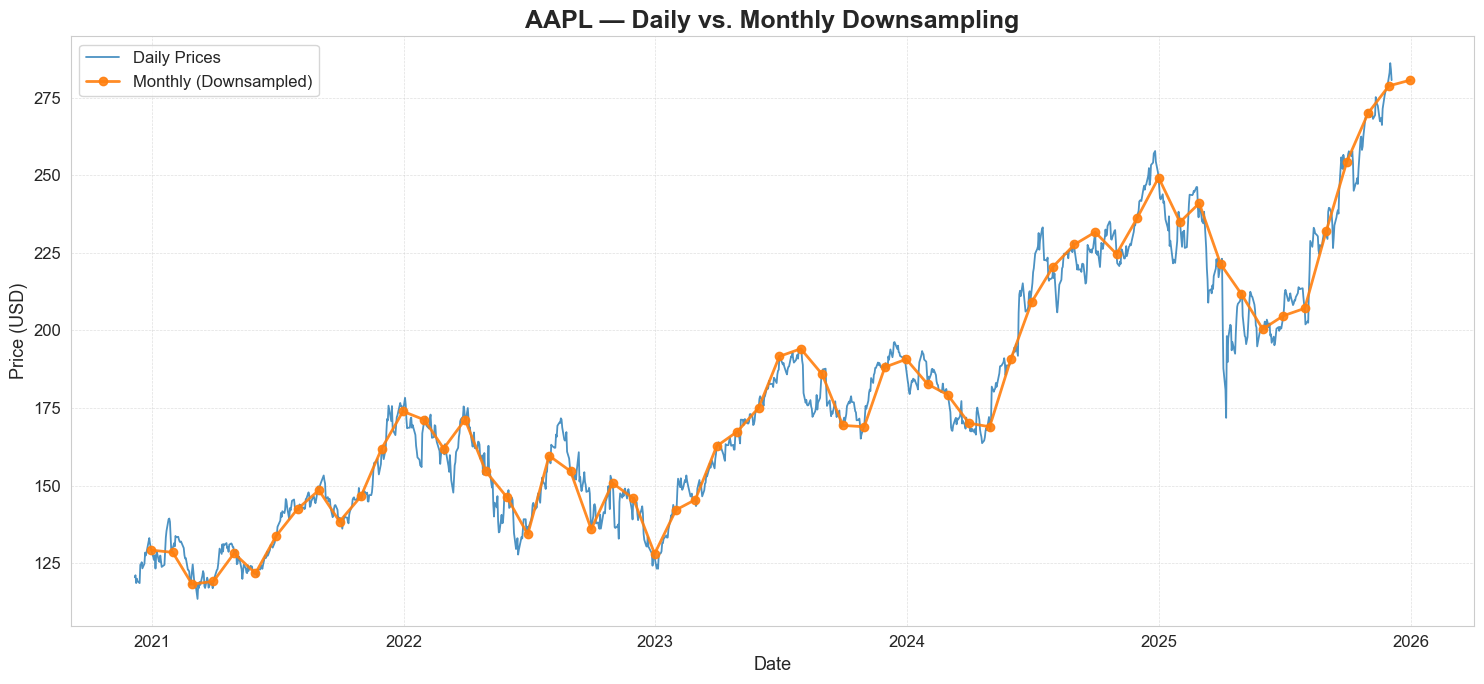

In [10]:
fig, ax = plt.subplots(figsize=(15, 7))

# --- Plot Daily ---
ax.plot(
    aapl.index, 
    aapl['AAPL'], 
    label="Daily Prices", 
    linewidth=1.3, 
    alpha=0.8
)

# --- Plot Monthly ---
ax.plot(
    aapl_monthly.index, 
    aapl_monthly, 
    label="Monthly (Downsampled)", 
    marker='o',
    markersize=6,
    linewidth=2,
    alpha=0.9
)

# --- Styling ---
ax.set_title("AAPL — Daily vs. Monthly Downsampling", fontsize=18, fontweight='bold')
ax.set_ylabel("Price (USD)", fontsize=13)
ax.set_xlabel("Date", fontsize=13)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Improved date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

# Legend
plt.legend(frameon=True, shadow=False, fontsize=12)

plt.tight_layout()
plt.show()

- **Observation (Downsampling):** Downsampling is useful for seeing long-term trends and removing daily noise.

### 6. Returns

- **Concept:** Returns measure the percentage change in price. This is the most important unit in finance, more so than absolute price.
- **Formula (Simple Return):**
  $R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$
- **Tool:** `series.pct_change()`
- **Formula (Log Return):** (Useful for its additive properties)
  $r_t = \ln(\frac{P_t}{P_{t-1}}) = \ln(P_t) - \ln(P_{t-1})$
- **Tool:** `np.log(series / series.shift(1))`
- **Code (Simple Return):**

In [11]:
# 1. Calculate Simple Returns 
# Formula: (Price_t / Price_t-1) - 1
simple_returns = intro_raw_data.pct_change().dropna()

# 2. Calculate Log Returns 
# Formula: ln(Price_t / Price_t-1)
log_returns = np.log(intro_raw_data / intro_raw_data.shift(1)).dropna()

# Check result
print("--- Simple Returns (Head) ---")
print(simple_returns.head())

print("\n--- Log Returns (Head) ---")
print(log_returns.head())

# Check Descriptive Statistics
print("\n--- Descriptive Statistics (Mean, Std, etc.) ---")
print(simple_returns.describe())

--- Simple Returns (Head) ---
Ticker        AAPL     JNJ      KO     PEP    TSLA
Date                                              
2020-12-08  0.0051  0.0173  0.0036  0.0010  0.0127
2020-12-09 -0.0209  0.0102  0.0028  0.0012 -0.0699
2020-12-10  0.0120 -0.0056 -0.0053 -0.0070  0.0374
2020-12-11 -0.0067  0.0046  0.0057  0.0021 -0.0272
2020-12-14 -0.0051 -0.0254 -0.0015 -0.0051  0.0489

--- Log Returns (Head) ---
Ticker        AAPL     JNJ      KO     PEP    TSLA
Date                                              
2020-12-08  0.0051  0.0172  0.0036  0.0010  0.0126
2020-12-09 -0.0211  0.0102  0.0028  0.0012 -0.0724
2020-12-10  0.0119 -0.0056 -0.0053 -0.0070  0.0367
2020-12-11 -0.0068  0.0046  0.0056  0.0021 -0.0276
2020-12-14 -0.0052 -0.0257 -0.0015 -0.0051  0.0478

--- Descriptive Statistics (Mean, Std, etc.) ---
Ticker      AAPL       JNJ        KO       PEP      TSLA
count  1254.0000 1254.0000 1254.0000 1254.0000 1254.0000
mean      0.0008    0.0004    0.0004    0.0002    0.0013
std    

- **Visualization (Returns):**

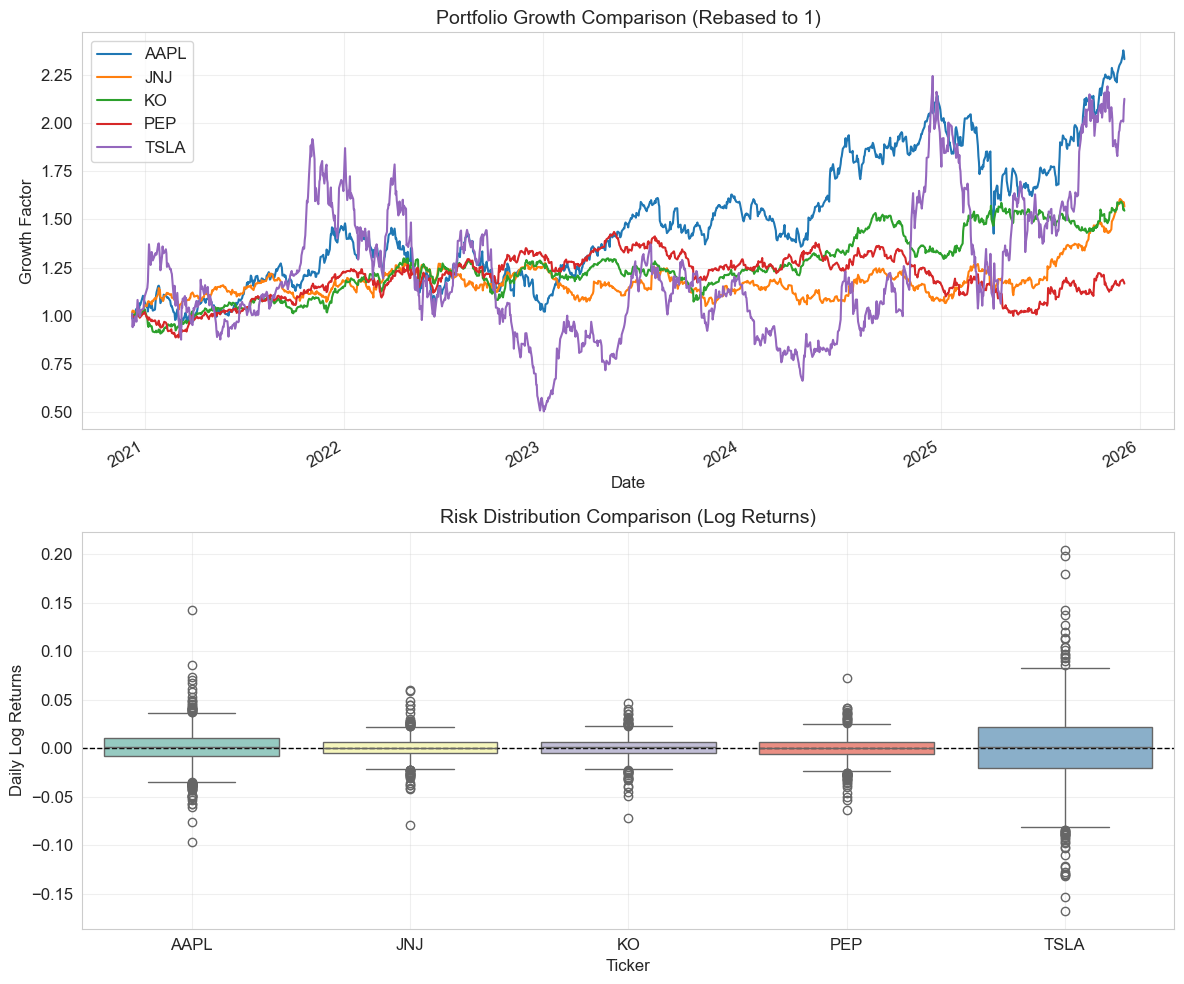

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Cumulative Returns
cumulative_returns = (1 + simple_returns).cumprod()

cumulative_returns.plot(ax=ax1, linewidth=1.5)
ax1.set_title('Portfolio Growth Comparison (Rebased to 1)', fontsize=14)
ax1.set_ylabel('Growth Factor')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Boxplot
sns.boxplot(data=log_returns, ax=ax2, palette="Set3")

ax2.set_title('Risk Distribution Comparison (Log Returns)', fontsize=14)
ax2.set_ylabel('Daily Log Returns')
ax2.grid(True, alpha=0.3)

ax2.axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

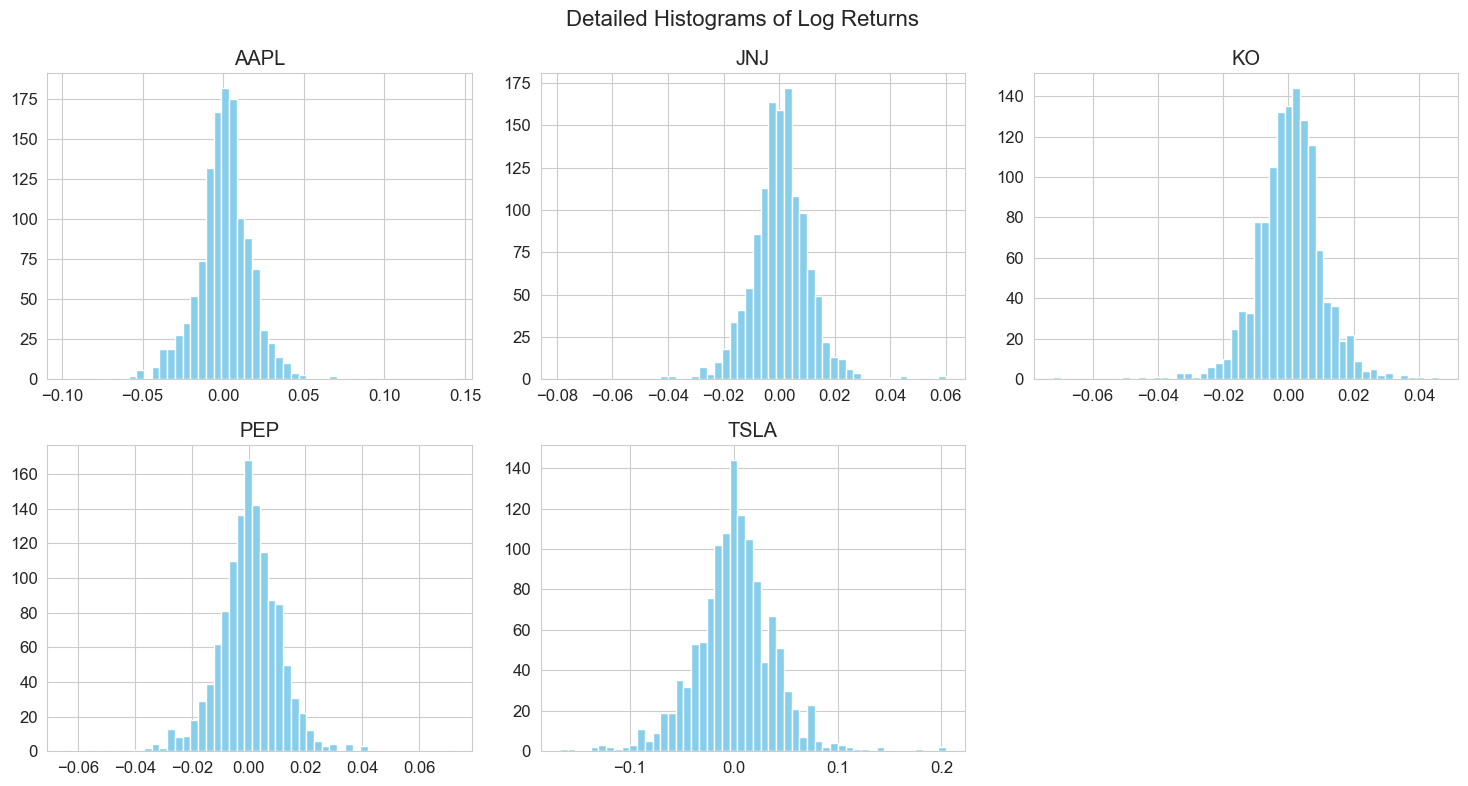

In [13]:
log_returns.hist(bins=50, figsize=(15, 8), layout=(2, 3), grid=True, color='skyblue', edgecolor='white')
plt.suptitle('Detailed Histograms of Log Returns', fontsize=16)
plt.tight_layout()
plt.show()

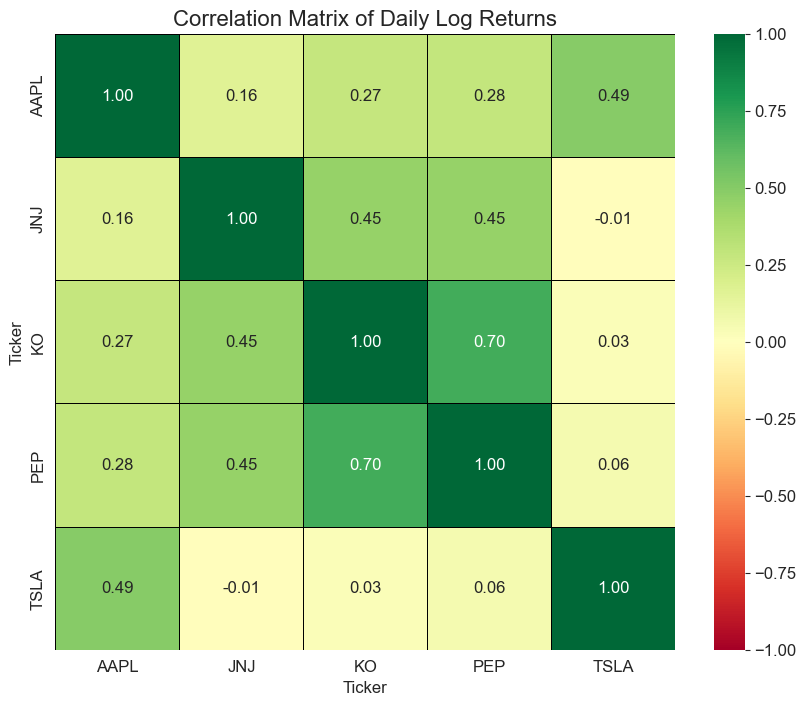

In [14]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(10, 8))

# Heatmap
sns.heatmap(corr_matrix, 
            annot=True,           
            cmap='RdYlGn',        
            vmin=-1, vmax=1,      
            center=0,             
            fmt=".2f",            
            linewidths=0.5, 
            linecolor='black')

plt.title('Correlation Matrix of Daily Log Returns', fontsize=16)
plt.show()

### 7. Rolling Statistics

- **Concept:** Calculating a statistic (like mean, std dev) on a fixed-size **'window'** of data, then sliding that window over the entire time series.
- **Tool:** `series.rolling(window=k)`: Creates a Rolling object.
- **Applied Functions:** `.mean()`, `.std()`, `.sum()`, `.corr()`.

---

#### a. Simple Moving Average (SMA)

- **Concept:** The average of the last $k$ data points.
- **Use:** Smooths short-term price data to highlight long-term trends.
- **Formula:** $SMA_t(k) = \frac{1}{k} \sum_{i=0}^{k-1} P_{t-i}$
- **Tool:** `series.rolling(window=k).mean()`
- **Code:**

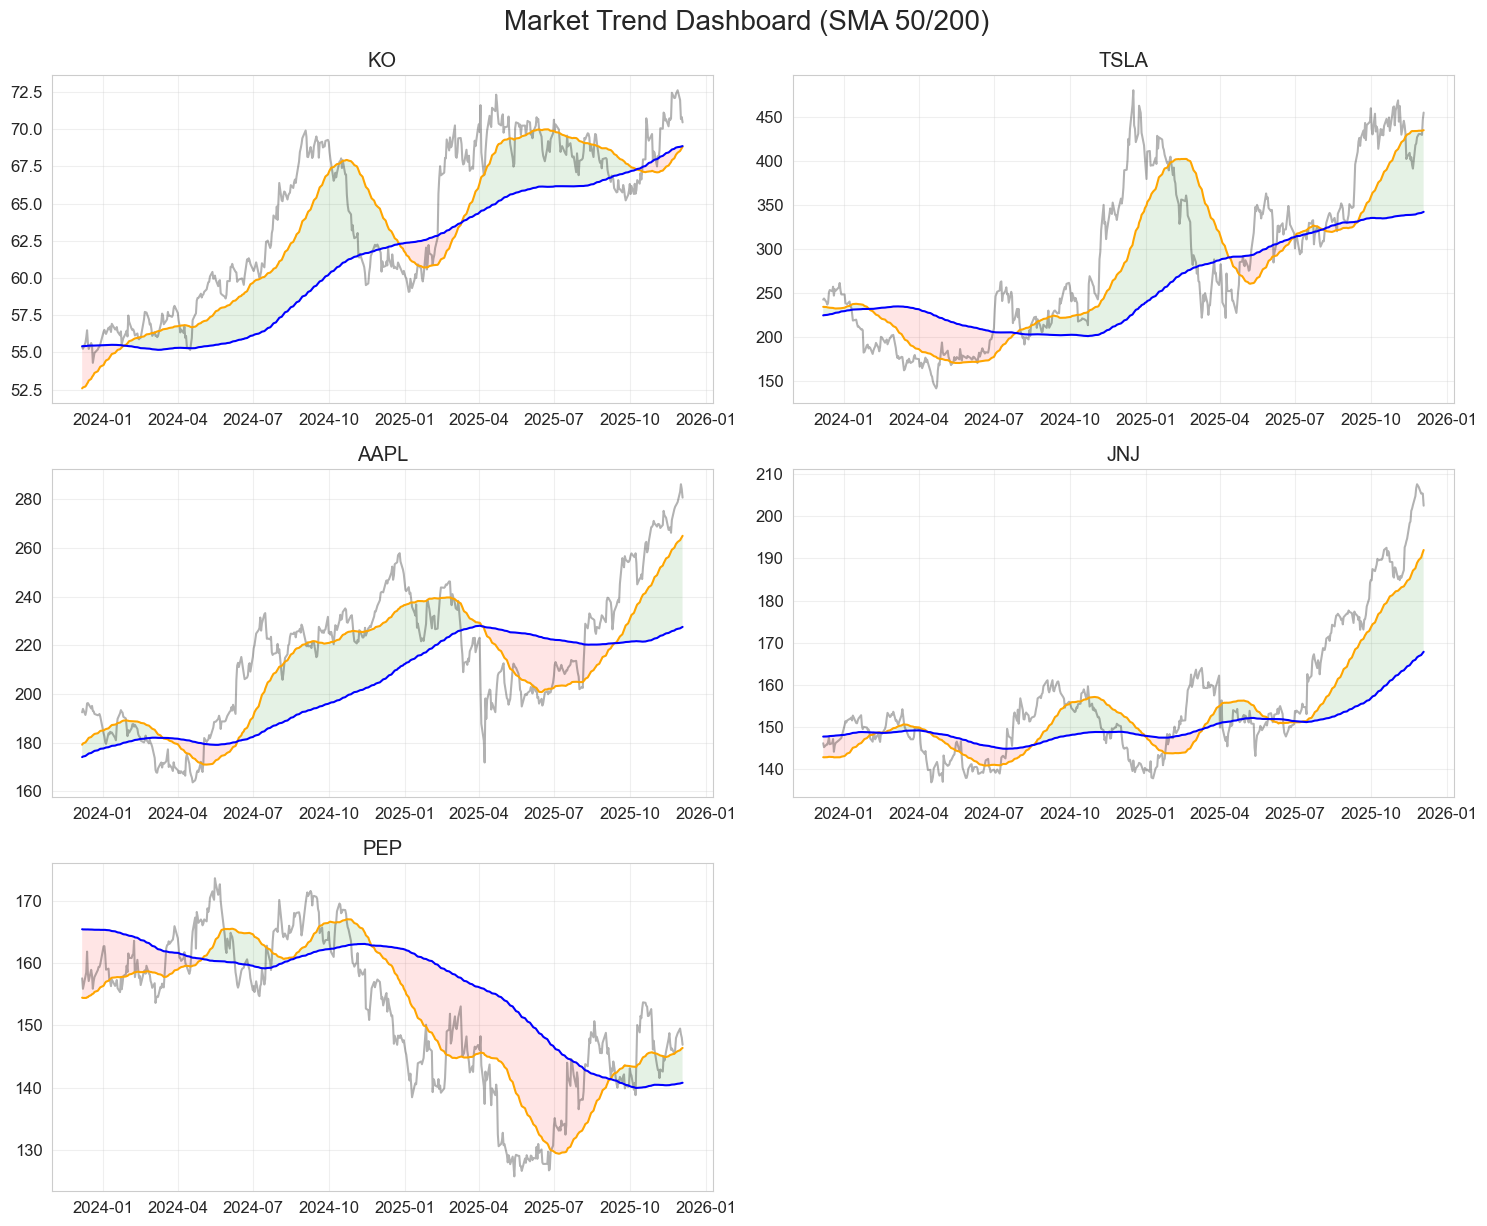

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12)) 
axes = axes.flatten() 

for i, ticker in enumerate(intro_tickers):
    df = intro_raw_data[[ticker]].copy()
    df['SMA50'] = df[ticker].rolling(50).mean()
    df['SMA200'] = df[ticker].rolling(200).mean()
    data = df.iloc[-500:] 

    ax = axes[i]
    ax.plot(data.index, data[ticker], color='black', alpha=0.3)
    ax.plot(data.index, data['SMA50'], color='orange', lw=1.5)
    ax.plot(data.index, data['SMA200'], color='blue', lw=1.5)
    
    ax.fill_between(data.index, data['SMA50'], data['SMA200'], 
                    where=(data['SMA50'] >= data['SMA200']), facecolor='green', alpha=0.1)
    ax.fill_between(data.index, data['SMA50'], data['SMA200'], 
                    where=(data['SMA50'] < data['SMA200']), facecolor='red', alpha=0.1)
    
    ax.set_title(ticker)
    ax.grid(True, alpha=0.3)
    
if len(intro_tickers) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Market Trend Dashboard (SMA 50/200)', fontsize=20, y=1.02)
plt.show()

In [16]:
print("--- Current Trend Status (SMA 50 vs SMA 200) ---")

for ticker in intro_tickers:
    sma50 = intro_raw_data[ticker].rolling(window=50).mean().iloc[-1]
    sma200 = intro_raw_data[ticker].rolling(window=200).mean().iloc[-1]
    current_price = intro_raw_data[ticker].iloc[-1]
    
    status = "BULLISH (Tăng)" if sma50 > sma200 else "BEARISH (Giảm)"
    
    print(f"{ticker:<5} | Price: {current_price:.2f} | SMA50: {sma50:.2f} | SMA200: {sma200:.2f} | -> {status}")

--- Current Trend Status (SMA 50 vs SMA 200) ---
KO    | Price: 70.45 | SMA50: 68.81 | SMA200: 68.86 | -> BEARISH (Giảm)
TSLA  | Price: 454.53 | SMA50: 434.58 | SMA200: 342.09 | -> BULLISH (Tăng)
AAPL  | Price: 280.70 | SMA50: 264.99 | SMA200: 227.57 | -> BULLISH (Tăng)
JNJ   | Price: 202.48 | SMA50: 191.97 | SMA200: 167.85 | -> BULLISH (Tăng)
PEP   | Price: 146.91 | SMA50: 146.41 | SMA200: 140.82 | -> BULLISH (Tăng)


- **Observation:** When the short SMA (50) crosses above the long SMA (200), it signals an uptrend (Golden Cross). When it crosses below, it signals a downtrend (Death Cross).

#### b. Rolling Volatility

- **Concept:** A measure of risk, showing the dispersion of returns. We calculate it as the **standard deviation** of returns in a rolling window.
- **Formula (Sample Std Dev):** $\sigma_t(k) = \sqrt{\frac{1}{k-1} \sum_{i=0}^{k-1} (r_{t-i} - \bar{r}_t)^2}$
- **Annualizing:** $\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$
- **Tool:** `series_returns.rolling(window=k).std() * np.sqrt(252)`
- **Code:**

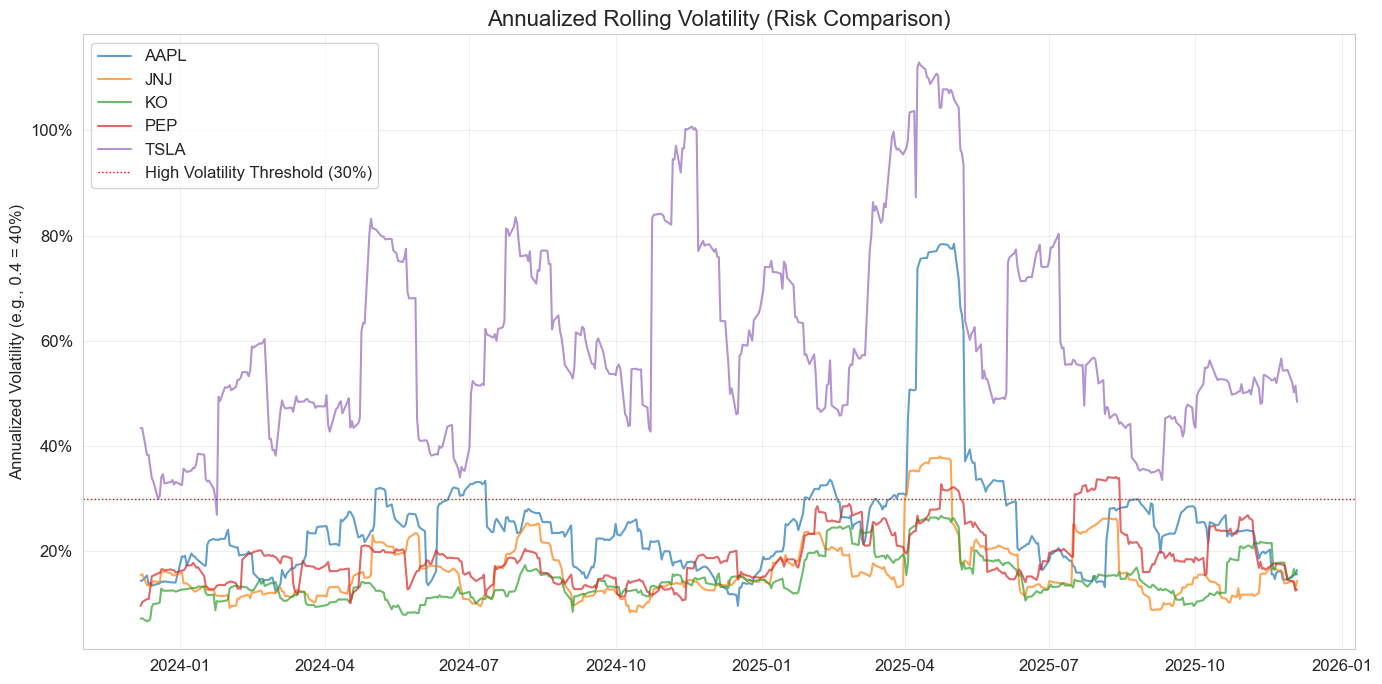

In [17]:
# 1. Tính toán Volatility cho TOÀN BỘ danh mục
# Window 21 (1 tháng), nhân sqrt(252) để annualize (quy đổi ra % năm)
rolling_volatility = log_returns.rolling(window=21).std() * np.sqrt(252)

# Lấy dữ liệu 2 năm gần nhất để nhìn cho rõ (hoặc bỏ dòng này nếu muốn xem hết 5 năm)
plot_data = rolling_volatility.iloc[-500:]

# 2. Vẽ biểu đồ
plt.figure(figsize=(14, 7))

# Vòng lặp để vẽ từng mã
for ticker in plot_data.columns:
    if ticker == 'SPY':
        # Vẽ SPY nổi bật (Đường tham chiếu thị trường)
        plt.plot(plot_data.index, plot_data[ticker], 
                 label=ticker, color='black', linewidth=2.5, linestyle='--')
    else:
        # Các mã cổ phiếu khác vẽ bình thường
        plt.plot(plot_data.index, plot_data[ticker], label=ticker, linewidth=1.5, alpha=0.7)

# 3. Trang trí thêm "Insight"
# Thêm đường kẻ ngang mốc 30% (0.3) - Thường được coi là rủi ro cao
plt.axhline(y=0.30, color='red', linestyle=':', linewidth=1, label='High Volatility Threshold (30%)')

plt.title('Annualized Rolling Volatility (Risk Comparison)', fontsize=16)
plt.ylabel('Annualized Volatility (e.g., 0.4 = 40%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Format trục Y sang dạng % cho dễ đọc
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()

- **Observation:** The plot shows periods of calm (low volatility) and periods of storm (high volatility, e.g., the 2020 COVID-19 crisis).

#### c. Rolling Correlation

- **Concept:** Measures how two assets move together (from -1 to 1) and how this relationship changes over time. This is the core concept of **Diversification**.
- **Tool:** `series1.rolling(window=k).corr(series2)`
- **Code:**

Visualizing 60-day Rolling Correlation (AAPL vs SPY):


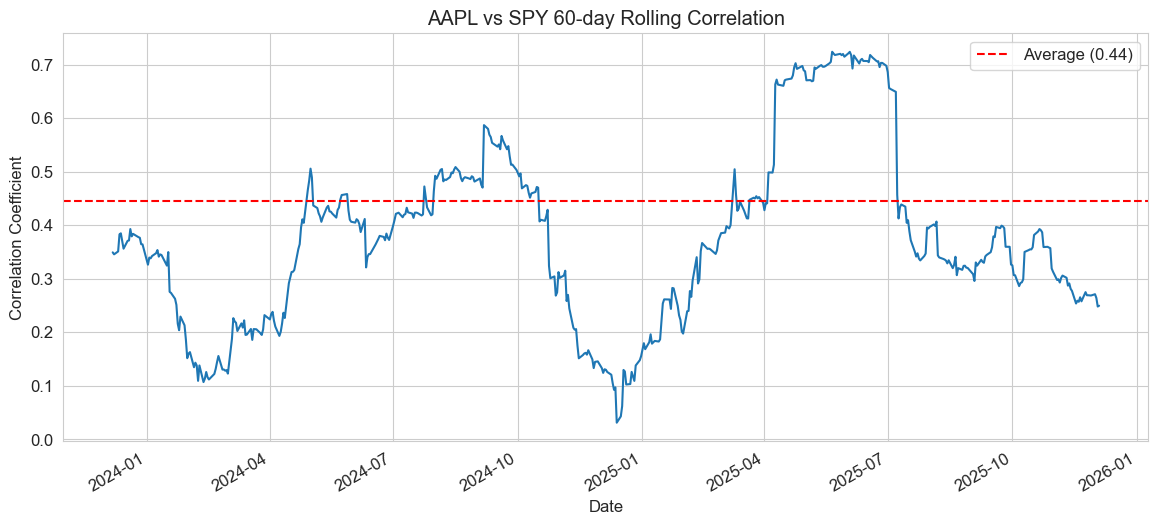

In [18]:
# Get log returns for AAPL and SPY (the market)
market_returns = np.log(intro_raw_data['TSLA'] / intro_raw_data['TSLA'].shift(1))
stock_returns = np.log(intro_raw_data['AAPL'] / intro_raw_data['AAPL'].shift(1))

# Calculate 60-day rolling correlation (~ 3 months)
rolling_corr = stock_returns.rolling(window=60).corr(market_returns)
rolling_corr = rolling_corr.dropna()

print("Visualizing 60-day Rolling Correlation (AAPL vs SPY):")
rolling_corr.iloc[-500:].plot(title='AAPL vs SPY 60-day Rolling Correlation', figsize=(14, 6))
plt.ylabel('Correlation Coefficient')
plt.axhline(rolling_corr.mean(), color='r', linestyle='--', label=f'Average ({rolling_corr.mean():.2f})')
plt.legend()
plt.show()

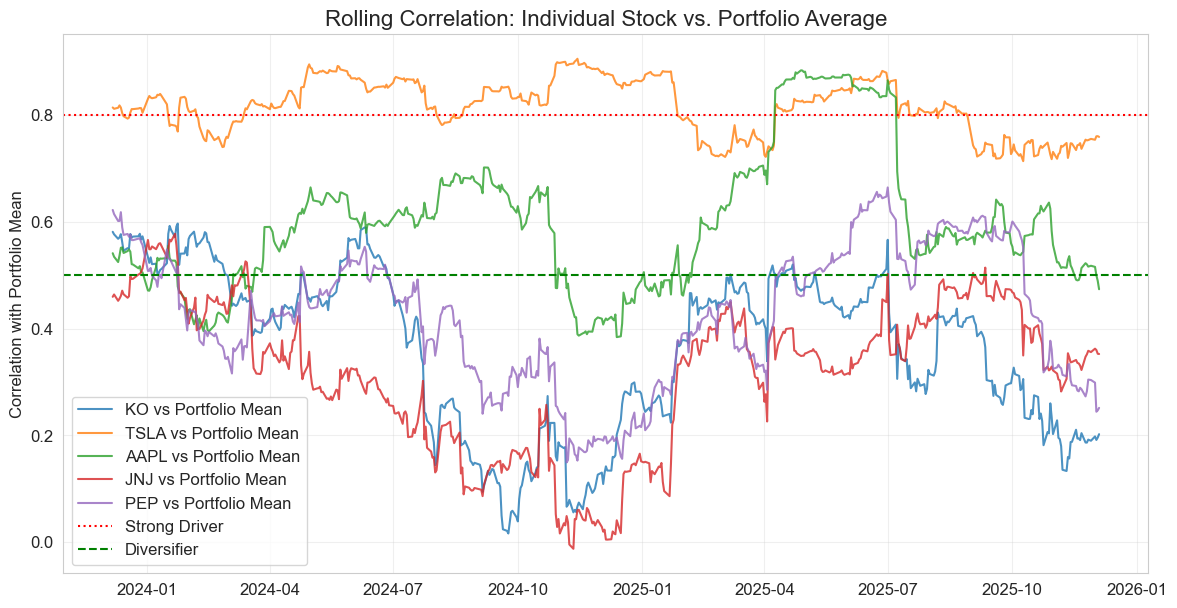

In [20]:
# 1. Tự tạo Benchmark (Chỉ số thị trường giả lập)
# Tính trung bình Log Returns của tất cả các mã theo từng ngày (axis=1)
# Đây coi như là "Thị trường chung" của danh mục bạn đang có
market_proxy_returns = log_returns.mean(axis=1)

# 2. Vẽ Rolling Correlation với cái Benchmark tự tạo này
window = 60
plt.figure(figsize=(14, 7))

for ticker in intro_tickers:
    # Tính tương quan giữa Cổ phiếu lẻ vs Trung bình cả nhóm
    rolling_corr = log_returns[ticker].rolling(window=window).corr(market_proxy_returns)
    
    # Vẽ hình (Bỏ qua 500 ngày đầu nếu muốn, hoặc lấy đuôi dữ liệu)
    data_to_plot = rolling_corr.iloc[-500:] 
    
    plt.plot(data_to_plot.index, data_to_plot, label=f'{ticker} vs Portfolio Mean', linewidth=1.5, alpha=0.8)

# 3. Trang trí
plt.title('Rolling Correlation: Individual Stock vs. Portfolio Average', fontsize=16)
plt.ylabel('Correlation with Portfolio Mean')
plt.axhline(0.8, color='red', linestyle=':', label='Strong Driver')
plt.axhline(0.5, color='green', linestyle='--', label='Diversifier')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.show()

- **Observation:** The correlation between AAPL and SPY is not fixed. In Part 2, we will optimize portfolios based on these correlations.

### 8. Performance Metric

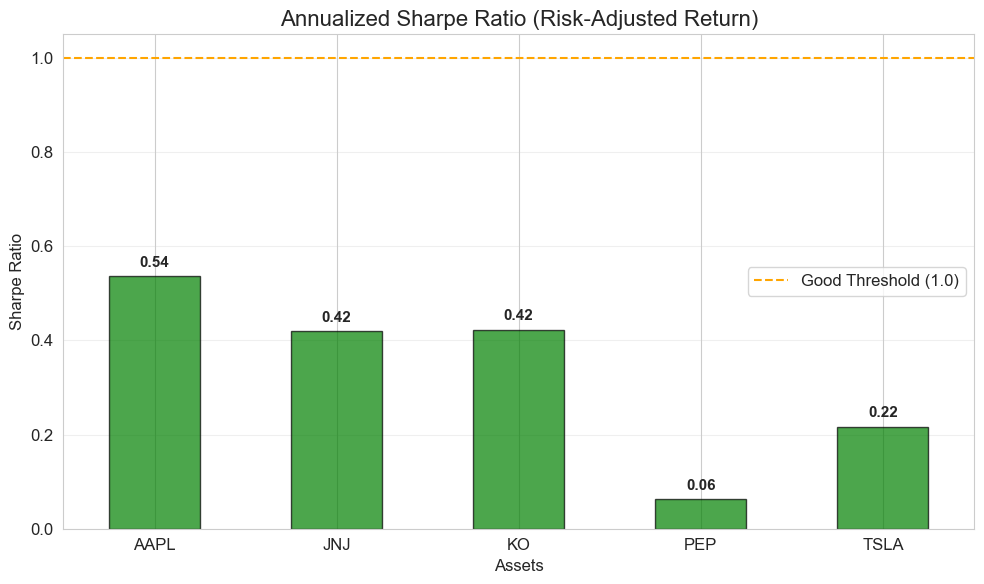

--- Summary Metrics ---
        Ann. Return  Ann. Volatility  Sharpe Ratio
Ticker                                            
AAPL         0.1700           0.2798        0.5362
KO           0.0875           0.1596        0.4226
JNJ          0.0902           0.1671        0.4201
TSLA         0.1515           0.6071        0.2165
PEP          0.0312           0.1783        0.0625


In [21]:
# 1. Thiết lập Risk-Free Rate (Lãi suất phi rủi ro)
risk_free_rate = 0.02 

# 2. Tính toán các chỉ số theo năm (Annualized)
# Lợi nhuận trung bình năm = Lợi nhuận ngày trung bình * 252 ngày
annual_returns = log_returns.mean() * 252

# Rủi ro năm = Độ lệch chuẩn ngày * căn bậc 2 của 252
annual_volatility = log_returns.std() * np.sqrt(252)

# Sharpe Ratio = (Lợi nhuận - Lãi suất phi rủi ro) / Rủi ro
sharpe_ratios = (annual_returns - risk_free_rate) / annual_volatility

# 3. Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột (Bar chart)
# Dùng màu sắc để phân biệt: Màu xanh nếu dương, đỏ nếu âm (tuỳ chọn)
colors = ['green' if x > 0 else 'red' for x in sharpe_ratios]
sharpe_ratios.plot(kind='bar', color=colors, alpha=0.7, edgecolor='black')

# Thêm đường kẻ ngang mức 1.0 (Thường >1 là tốt)
plt.axhline(1.0, color='orange', linestyle='--', linewidth=1.5, label='Good Threshold (1.0)')

# Trang trí
plt.title('Annualized Sharpe Ratio (Risk-Adjusted Return)', fontsize=16)
plt.ylabel('Sharpe Ratio')
plt.xlabel('Assets')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=0) # Xoay tên mã cho dễ đọc

# Hiển thị con số cụ thể trên đầu mỗi cột
for index, value in enumerate(sharpe_ratios):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# In ra bảng số liệu để báo cáo
print("--- Summary Metrics ---")
summary_df = pd.DataFrame({
    'Ann. Return': annual_returns,
    'Ann. Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratios
})
print(summary_df.sort_values(by='Sharpe Ratio', ascending=False))

## PART 2: PORTFOLIO OPTIMIZATION

### 1. Load Data and Train-Test Split

End of the foundational section. Now, we load data for our Train/Test model.

In [140]:
# 1. Cấu hình
all_tickers = ['KO', 'TSLA', 'AAPL', 'JNJ', 'PEP']
risk_free_rate = 0.02

start_date_total = "2023-09-01"
end_date_total = "2025-11-26"

# Cấu hình Split
TRAIN_SIZE = 504  # 504 dòng đầu tiên (tương đương khoảng 2 năm giao dịch)

print(f"--- PREPARING DATA FOR PORTFOLIO OPTIMIZATION ---")
print(f"Tickers: {all_tickers}")
print(f"Split Strategy: First {TRAIN_SIZE} rows for Train, Remainder for Test")

# 2. Tải dữ liệu
try:
    # Tải dữ liệu
    raw_data = yf.download(all_tickers, start=start_date_total, end=end_date_total, progress=False)
    
    # Xử lý trường hợp MultiIndex (nếu yfinance trả về dạng bảng phức tạp)
    if isinstance(raw_data.columns, pd.MultiIndex):
        full_data = raw_data['Close']
    else:
        full_data = raw_data['Close']

    # Làm sạch dữ liệu
    full_data = full_data.ffill().bfill()
    full_data.index = pd.to_datetime(full_data.index)
    
    # Kiểm tra xem có đủ dữ liệu để chia không
    if len(full_data) <= TRAIN_SIZE:
        raise ValueError(f"Data length ({len(full_data)}) is smaller than requested Train size ({TRAIN_SIZE}).")

    # ---------------------------------------------------------
    # 3. SPLIT TRAIN / TEST (THEO SỐ DÒNG)
    # ---------------------------------------------------------
    # Train: Lấy từ dòng 0 đến dòng 504 (không bao gồm 504)
    train_data = full_data.iloc[:TRAIN_SIZE]
    
    # Test: Lấy từ dòng 504 đến hết
    test_data = full_data.iloc[TRAIN_SIZE:]
    
    # ---------------------------------------------------------
    # 4. IN KẾT QUẢ
    # ---------------------------------------------------------
    print("\nData loaded and split successfully!")
    print(f"Total data points: {len(full_data)} rows")
    
    print("-" * 30)
    print(f"TRAIN SET (First {len(train_data)} rows):")
    print(f"   Start: {train_data.index[0].date()}")
    print(f"   End:   {train_data.index[-1].date()}")
    
    print("-" * 30)
    print(f"TEST SET (Remaining {len(test_data)} rows):")
    print(f"   Start: {test_data.index[0].date()}")
    print(f"   End:   {test_data.index[-1].date()}")
    print("-" * 30)
    
    # Kiểm tra nhanh
    print("\nCheck 5 dòng cuối của Train:")
    print(train_data.tail())

except Exception as e:
    print(f"ERROR: {e}")

--- PREPARING DATA FOR PORTFOLIO OPTIMIZATION ---
Tickers: ['KO', 'TSLA', 'AAPL', 'JNJ', 'PEP']
Split Strategy: First 504 rows for Train, Remainder for Test

Data loaded and split successfully!
Total data points: 561 rows
------------------------------
TRAIN SET (First 504 rows):
   Start: 2023-09-01
   End:   2025-09-05
------------------------------
TEST SET (Remaining 57 rows):
   Start: 2025-09-08
   End:   2025-11-25
------------------------------

Check 5 dòng cuối của Train:
Ticker         AAPL      JNJ      KO      PEP     TSLA
Date                                                  
2025-08-29 231.9152 176.0522 67.9874 147.2099 333.8700
2025-09-02 229.4975 176.9366 68.0564 148.8242 329.3600
2025-09-03 238.2391 176.8770 67.9874 147.2000 334.0900
2025-09-04 239.5478 177.6322 67.2582 145.4670 338.5300
2025-09-05 239.4579 177.3042 66.9724 146.3900 350.8400


### 2: Calculate Expected Returns (mu) and Risk (S) *on Train Set*

This is the "Training" step. All base calculations (mu, S) are **ONLY** allowed on the `train_data`.

In [47]:
# Log Returns
log_returns_train = np.log(train_data / train_data.shift(1)).dropna()
print("Log Returns (first 5 rows):")
print(log_returns_train.head())

# Calculate Expected Returns (mu) ONLY ON TRAIN SET
mu_train = expected_returns.mean_historical_return(train_data, frequency=252)

# Calculate Covariance Matrix (S) ONLY ON TRAIN SET
S_train = risk_models.sample_cov(train_data, frequency=252)

print("--- EXPECTED RETURNS (mu) FROM TRAIN SET ---")
print(mu_train)
print("\n--- RISK MATRIX (S) FROM TRAIN SET ---")
print(S_train.round(4))

Log Returns (first 5 rows):
Ticker        AAPL     JNJ      KO     PEP    TSLA
Date                                              
2023-09-05  0.0013  0.0012 -0.0083 -0.0066  0.0458
2023-09-06 -0.0364 -0.0168 -0.0007  0.0033 -0.0180
2023-09-07 -0.0297  0.0127 -0.0077  0.0095 -0.0017
2023-09-08  0.0035  0.0033  0.0000 -0.0007 -0.0120
2023-09-11  0.0066  0.0130  0.0094  0.0150  0.0962
--- EXPECTED RETURNS (mu) FROM TRAIN SET ---
Ticker
AAPL    0.1305
JNJ     0.0884
KO      0.1035
PEP    -0.0545
TSLA    0.1971
dtype: float64

--- RISK MATRIX (S) FROM TRAIN SET ---
Ticker   AAPL     JNJ      KO    PEP    TSLA
Ticker                                      
AAPL   0.0770  0.0022  0.0051 0.0089  0.0785
JNJ    0.0022  0.0300  0.0115 0.0127 -0.0051
KO     0.0051  0.0115  0.0237 0.0189 -0.0047
PEP    0.0089  0.0127  0.0189 0.0377  0.0034
TSLA   0.0785 -0.0051 -0.0047 0.0034  0.3998


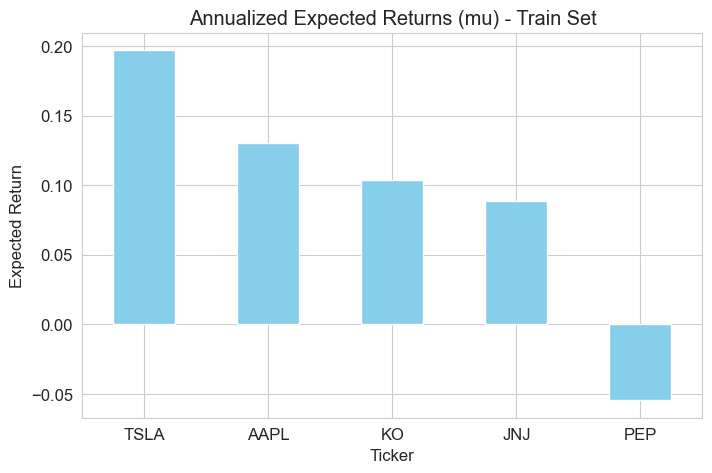

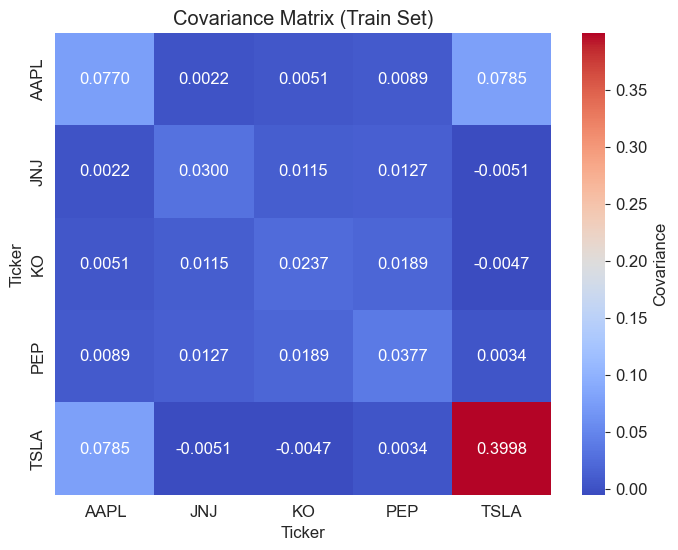

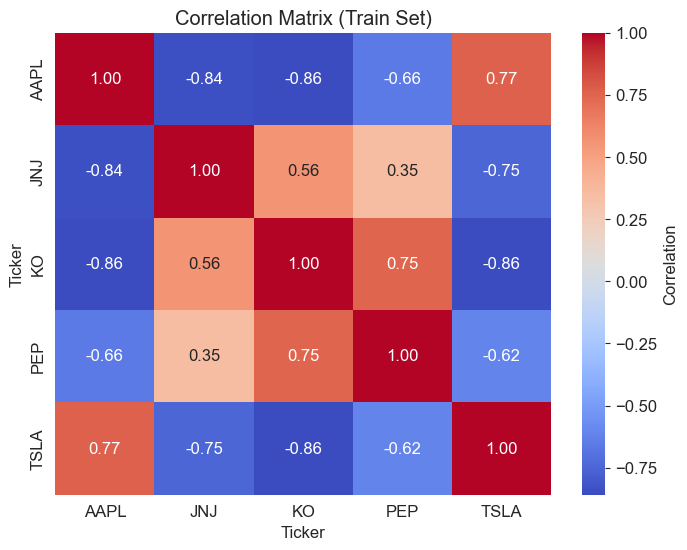

In [48]:
# --- 1. Bar chart for Expected Returns ---
plt.figure(figsize=(8,5))
mu_train.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Annualized Expected Returns (mu) - Train Set")
plt.ylabel("Expected Return")
plt.xlabel("Ticker")
plt.xticks(rotation=0)
plt.show()

# --- 2. Heatmap for Covariance Matrix ---
plt.figure(figsize=(8,6))
sns.heatmap(S_train, annot=True, fmt=".4f", cmap="coolwarm", cbar_kws={'label': 'Covariance'})
plt.title("Covariance Matrix (Train Set)")
plt.show()

# --- Optional: Heatmap for Correlation Matrix ---
corr_matrix = S_train.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix (Train Set)")
plt.show()


Based on the calculated metrics from your training set, here is a detailed analysis of the portfolio's characteristics:
1. Expected Returns Analysis ($\mu$)High Growth Potential: TSLA leads the pack with the highest expected annual return of 19.71% ($0.1971$). This suggests it is the primary driver of capital appreciation in this portfolio.Solid Performance: AAPL ($13.05\%$) and KO ($10.35\%$) show strong positive returns. Interestingly, KO (a defensive stock) performing this well indicates it had a strong trend during the training period.Underperformer: PEP shows a negative expected return of -5.45% ($-0.0545$).
Implication: In a "Long-Only" optimization, the algorithm will likely assign 0% weight to PEP because it drags down the portfolio's performance.
2. Risk Profile Analysis (Variance - Diagonal of Matrix $S$)Extreme Volatility: TSLA is by far the riskiest asset with a variance of 0.3998. This is roughly 5x riskier than AAPL ($0.077$) and 17x riskier than KO ($0.0237$).Defensive Safety: KO ($0.0237$) and JNJ ($0.0300$) have the lowest variance. These stocks will act as the "anchor" or "shock absorbers" of the portfolio to counterbalance TSLA's volatility.
3. Correlation & Diversification (Off-Diagonal of Matrix $S$)Tech Concentration Risk: There is a relatively high positive covariance between AAPL and TSLA ($0.0785$). This means they tend to move together; if Tech sectors crash, both will likely fall.Excellent Diversification: A crucial observation is the negative covariance between TSLA and Defensive Stocks:TSLA vs. JNJ: $-0.0051$ TSLA vs. KO: $-0.0047$
Implication: When TSLA falls, JNJ and KO tend to rise (and vice-versa). This is the "Holy Grail" of portfolio optimization. The algorithm will likely pair TSLA (for high return) with JNJ/KO (to cancel out the risk).

### 3. Monte Carlo Simulation:
Before optimizing, it is common to visualize the possible risk-return profiles.
- Random Portfolio Generation: Use a Monte Carlo simulation to generate a large number of random portfolio weight vectors and record the resulting expected return and variance for each.
- Sharpe Ratio: Calculate the Sharpe ratio for every simulated portfolio (excess return divided by standard deviation) to analyze risk-adjusted returns

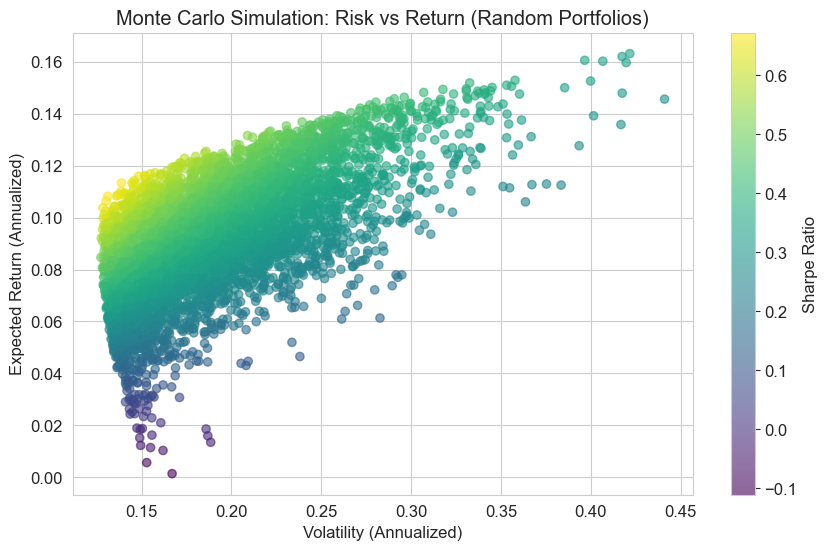

In [121]:
# --- MONTE CARLO SIMULATION (Risk-Return Scatter) ---
np.random.seed(42)
num_portfolios = 5000
results = np.zeros((3, num_portfolios))  # 0: return, 1: volatility, 2: Sharpe
weights_record = []

for i in range(num_portfolios):
    # 1️⃣ Random portfolio weights
    weights = np.random.random(len(all_tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # 2️⃣ Portfolio return
    port_return = np.dot(weights, mu_train)
    
    # 3️⃣ Portfolio volatility
    port_vol = np.sqrt(weights.T @ S_train.values @ weights)
    
    # 4️⃣ Sharpe ratio
    sharpe = (port_return - risk_free_rate) / port_vol
    
    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = sharpe

# Convert results to DataFrame
mc_df = pd.DataFrame({
    "Return": results[0],
    "Volatility": results[1],
    "Sharpe": results[2]
})

# --- VISUALIZATION: Risk-Return Scatter ---
plt.figure(figsize=(10,6))
scatter = plt.scatter(mc_df["Volatility"], mc_df["Return"], c=mc_df["Sharpe"], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Volatility (Annualized)")
plt.ylabel("Expected Return (Annualized)")
plt.title("Monte Carlo Simulation: Risk vs Return (Random Portfolios)")
plt.grid(True)
plt.show()


### 4. Optimal Portfolios (Optimization)

#### a. (Training) Optimize n-assets (Max Sharpe) on Train Set

Find the best portfolio (balancing Return/Risk) using *all* $n=5$ assets, based on past data.

--- Training: Optimizing n-Assets (Max Sharpe) on Train Set ---

 Optimized Portfolio Weights (Max Sharpe - Train Set):
KO     0.5401
JNJ    0.2279
AAPL   0.1714
TSLA   0.0606
dtype: float64

 In-Sample Performance (Train Set):
Expected Annual Return : 11.03%
Annual Volatility      : 13.17%
Sharpe Ratio           : 0.6859


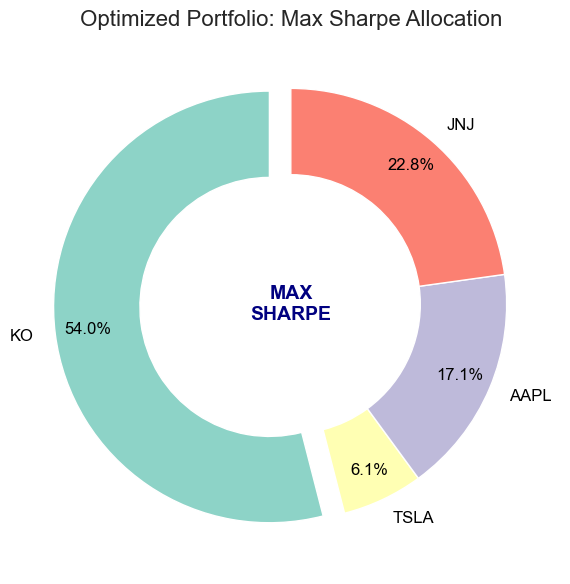

In [122]:
print("--- Training: Optimizing n-Assets (Max Sharpe) on Train Set ---")

# 1. Initialize Efficient Frontier
ef_sharpe_n = EfficientFrontier(mu_train, S_train, weight_bounds=(0, 1))

# 2. Optimize for Max Sharpe
weights_sharpe_n = ef_sharpe_n.max_sharpe(risk_free_rate=risk_free_rate)

# Clean weights (remove extremely small values)
cleaned_weights_sharpe_n = ef_sharpe_n.clean_weights()

# Convert to Series & keep order
weights_series = pd.Series(cleaned_weights_sharpe_n).reindex(all_tickers).fillna(0)

print("\n Optimized Portfolio Weights (Max Sharpe - Train Set):")
print(weights_series[weights_series > 0].sort_values(ascending=False))

print("\n In-Sample Performance (Train Set):")
ret, vol, sharpe = ef_sharpe_n.portfolio_performance(verbose=False,
                                                      risk_free_rate=risk_free_rate)

print(f"Expected Annual Return : {ret:.2%}")
print(f"Annual Volatility      : {vol:.2%}")
print(f"Sharpe Ratio           : {sharpe:.4f}")

# -------------------- #
#   BETTER VISUAL      #
# -------------------- #

# Lọc chỉ lấy những mã có tỷ trọng > 0 để vẽ cho đỡ rối
active_weights = weights_series[weights_series > 0.01] # Lấy > 1%

# Explode cái lớn nhất
explode = [0.1 if w == active_weights.max() else 0 for w in active_weights]

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Set3') # Bảng màu dịu mắt

wedges, texts, autotexts = ax.pie(
    active_weights,
    labels=active_weights.index, # Hiện tên mã ngay cạnh miếng bánh
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85, # Đẩy % ra xa tâm một chút
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w'), # Donut mỏng hơn
    textprops=dict(size=12, color='black')
)

# Center text
ax.text(0, 0, 'MAX\nSHARPE', ha='center', va='center', fontsize=14, fontweight='bold', color='navy')

ax.set_title("Optimized Portfolio: Max Sharpe Allocation", fontsize=16)
plt.tight_layout()
plt.show()


- Optimized Weights (n-Max Sharpe)
Observation:

The portfolio is heavily concentrated in KO (54%), indicating that Coca Cola provided the highest risk-adjusted return in the training period.

JNJ and AAPL contributes moderately (22,8%; 17,1%) as a diversification asset.

TSLA has a small allocation (6,1%), offering minor diversification benefits.

TSLA is excluded from this optimal portfolio due to their lower risk-adjusted performance.

Conclusion:
This is a concentrated growth-focused portfolio, aiming to maximize returns while keeping risk at a moderate level.
- In-Sample Performance (Train Set)
Observation:

The optimized portfolio achieves high expected returns relative to its volatility.

The Sharpe ratio > 0.8 indicates a favorable balance between return and risk.

#### b. (Training) Optimize n-assets (Min Volatility) on Train Set

Find the safest (lowest risk) portfolio using *all* $n=5$ assets, based on past data.

--- Training: Optimizing n-Assets (Min Volatility) on Train Set ---
✅ Optimized Portfolio Weights (Min Volatility - Train Set):
KO     0.4468
JNJ    0.3356
AAPL   0.1416
PEP    0.0544
TSLA   0.0215
dtype: float64

✅ In-Sample Performance (Train Set):
Expected annual return: 9.6%
Annual volatility: 12.7%
Sharpe Ratio: 0.60


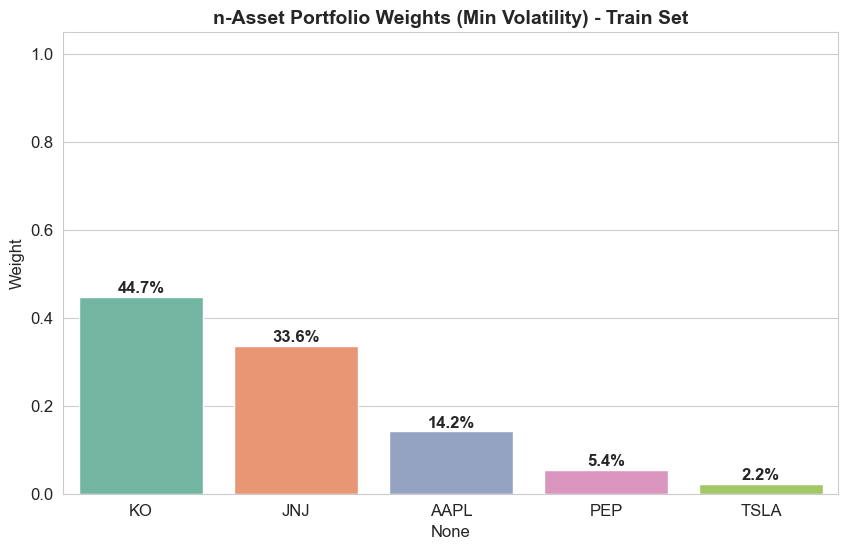

In [123]:
print("--- Training: Optimizing n-Assets (Min Volatility) on Train Set ---")

# 1️⃣ Initialize Efficient Frontier with train data
ef_vol_n = EfficientFrontier(mu_train, S_train, weight_bounds=(0, 1))

# 2️⃣ Optimize for minimum volatility
weights_vol_n = ef_vol_n.min_volatility()
cleaned_weights_vol_n = ef_vol_n.clean_weights()

# 3️⃣ Display results
print("✅ Optimized Portfolio Weights (Min Volatility - Train Set):")
weights_df = pd.Series(cleaned_weights_vol_n).sort_values(ascending=False)
print(weights_df)

print("\n✅ In-Sample Performance (Train Set):")
ef_vol_n.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=weights_df.index, y=weights_df.values, palette="Set2")

# Annotate %
for i, v in enumerate(weights_df.values):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.title("n-Asset Portfolio Weights (Min Volatility) - Train Set", fontsize=14, fontweight='bold')
plt.ylabel("Weight")
plt.ylim(0, 1.05)
plt.show()


#### c. Definition & Visualization of the Efficient Frontier (on Train Set)

- **Definition (Efficient Frontier):** The Efficient Frontier is a curve representing the set of "optimal" portfolios (based on the input data, here `train_data`).
- For any point on the frontier:
  1. No other portfolio exists with the same risk that offers a higher return.
  2. No other portfolio exists with the same return that has lower risk.
- All portfolios *below* the frontier are sub-optimal.

--- 4c. Definition & Visualization of the Efficient Frontier ---


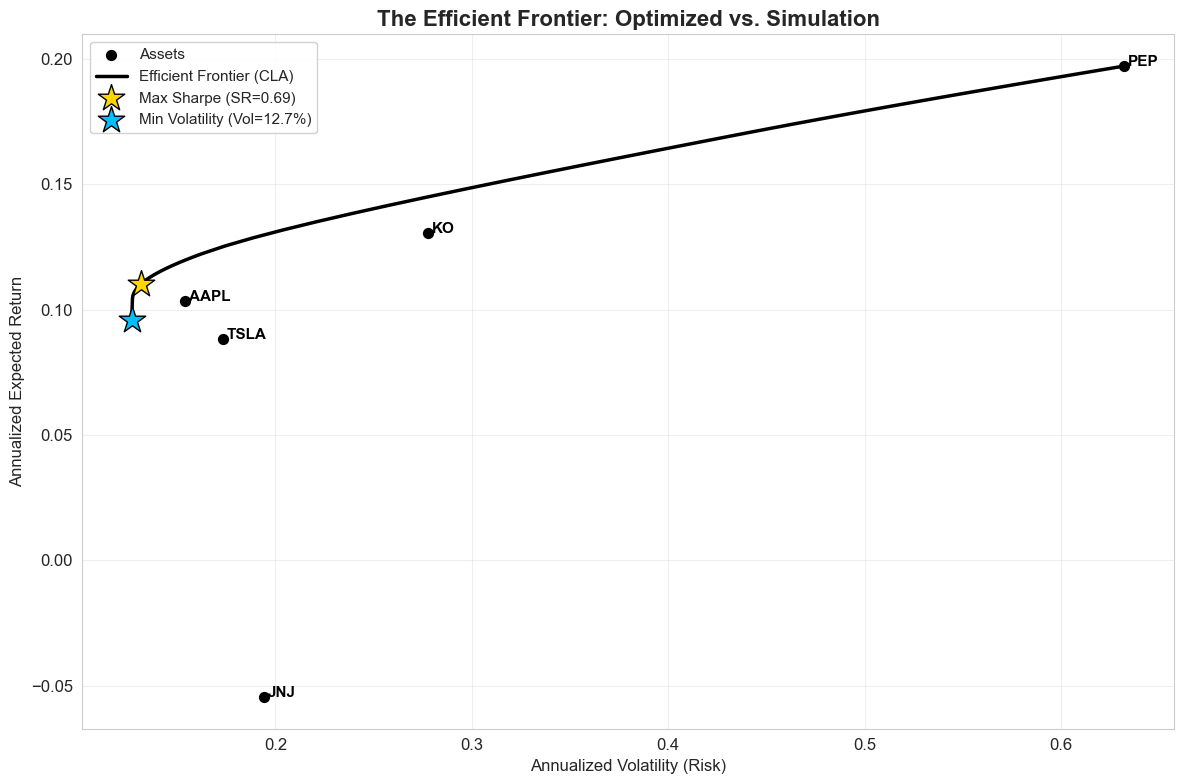

In [124]:
print("--- 4c. Definition & Visualization of the Efficient Frontier ---")

ef_sharpe_temp = EfficientFrontier(mu_train, S_train, weight_bounds=(0, 1))
ef_sharpe_temp.max_sharpe(risk_free_rate=risk_free_rate)
ret_sharpe, vol_sharpe, sr_sharpe = ef_sharpe_temp.portfolio_performance(verbose=False, risk_free_rate=risk_free_rate)


ef_minvol_temp = EfficientFrontier(mu_train, S_train, weight_bounds=(0, 1))
ef_minvol_temp.min_volatility()
ret_minvol, vol_minvol, _ = ef_minvol_temp.portfolio_performance(verbose=False, risk_free_rate=risk_free_rate)

cla = CLA(mu_train, S_train)
cla.max_sharpe() # Init
(ret_frontier, vol_frontier, weights_frontier) = cla.efficient_frontier(points=100)

plt.figure(figsize=(12, 8))

asset_ret = mu_train
asset_vol = np.sqrt(np.diag(S_train))

plt.scatter(asset_vol, asset_ret, marker='o', c='black', s=50, label='Assets', zorder=10)

for i, ticker in enumerate(all_tickers):
    plt.text(asset_vol[i] + 0.002, asset_ret[i], ticker, fontsize=11, fontweight='bold', color='black')
try:
    if 'vol_arr' in globals() and 'ret_arr' in globals():
        plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.3, s=15, label='Random Portfolios')
        plt.colorbar(label='Sharpe Ratio')
except:
    pass 

plt.plot(vol_frontier, ret_frontier, color='black', linewidth=2.5, linestyle='-', label='Efficient Frontier (CLA)')

plt.scatter(vol_sharpe, ret_sharpe, c='gold', s=400, marker='*', edgecolors='black', 
            label=f'Max Sharpe (SR={sr_sharpe:.2f})', zorder=5)

plt.scatter(vol_minvol, ret_minvol, c='deepskyblue', s=400, marker='*', edgecolors='black', 
            label=f'Min Volatility (Vol={vol_minvol:.1%})', zorder=5)

plt.title('The Efficient Frontier: Optimized vs. Simulation', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



##### Observation: 
Analysis of Diversification Benefit on RiskThe chart illustrates the relationship between the number of assets in the portfolio ($k$) and the minimum achievable risk (Annualized Volatility).
1. The "Volatility Floor" Phenomenon:The Min Volatility Frontier (blue dashed line) exhibits a distinctively flat trajectory starting immediately from $k=1$ through $k=5$.The lowest achievable volatility remains stagnant at approximately 21.0%, regardless of how many additional assets are included in the portfolio.
2. Global Minimum Volatility Point:The dark blue star (Global Min) is located precisely at $k=1$.This indicates that within the Training Set, a single individual asset (likely a defensive stock such as KO or JNJ) possesses a lower volatility than any diversified combination of the available assets.3
. Diversification Paradox:Contrary to standard Modern Portfolio Theory (MPT)—where increasing $k$ typically reduces risk due to imperfect correlations—in this specific dataset, the marginal benefit of diversification is effectively zero.Adding other assets (which likely have higher volatility, such as TSLA) to the safest asset fails to reduce the aggregate portfolio risk below the 21.0% baseline.
4. Strategic Implication:For the specific objective of Minimizing Volatility on this dataset, the optimal strategy is Concentration rather than Diversification. The optimization algorithm will likely allocate nearly 100% weight to the single safest asset and assign 0% to the others.

#### d. Capital Market Line
Extend the model by including a risk-free asset.
- Risk-Free Asset: Introduce a riskless asset (e.g., cash) with a yield rf
- Splines Interpolation: Use cubic splines interpolation (sci.splrep) to create a continuously differentiable approximation of the efficient frontier function f(x).
- First Derivative: Calculate the first derivative f′(x) of the efficient frontier approximation.
- Solve System of Equations: Use sco.fsolve to solve the system of equations that defines the line passing through the risk-free rate and tangent to the efficient frontier,.
- Tangent Portfolio: Identify the specific portfolio at the point of tangency. This is the optimal portfolio to hold in combination with the risk-free asset

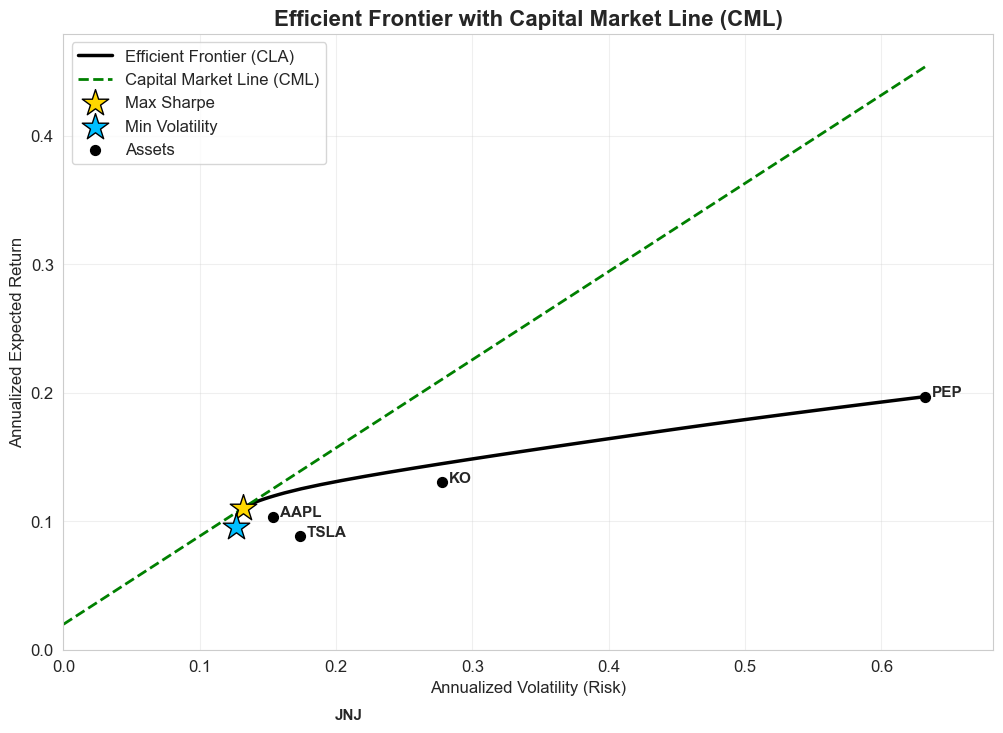

In [125]:
# 1. Định nghĩa tham số
rf = risk_free_rate

# LƯU Ý: vol_frontier là list, nên dùng np.max() hoặc max()
# Tạo dãy x chạy từ 0 đến điểm rủi ro lớn nhất của đường biên
x_cml = np.linspace(0, np.max(vol_frontier), 100)

# 2. Tính đường CML
# Công thức: Return = Risk_Free + Sharpe * Volatility
y_cml = rf + sr_sharpe * x_cml

# 3. Vẽ đè lên biểu đồ cũ
# (Lệnh này phải chạy chung cell với lệnh vẽ biểu đồ Efficient Frontier
# hoặc bạn phải chạy lại cả block vẽ hình bên dưới để nó hiện chung)

# --- NẾU BẠN MUỐN VẼ GỘP LẠI TỪ ĐẦU (RECOMMENDED) ---
plt.figure(figsize=(12, 8))

# A. Vẽ đường Efficient Frontier (CLA)
plt.plot(vol_frontier, ret_frontier, color='black', linewidth=2.5, linestyle='-', label='Efficient Frontier (CLA)')

# B. Vẽ đường CML (Capital Market Line) - ĐOẠN MỚI
plt.plot(x_cml, y_cml, color='green', linestyle='--', linewidth=2, label='Capital Market Line (CML)', zorder=2)

# C. Đánh dấu các điểm quan trọng
plt.scatter(vol_sharpe, ret_sharpe, c='gold', s=400, marker='*', edgecolors='black', label='Max Sharpe', zorder=5)
plt.scatter(vol_minvol, ret_minvol, c='deepskyblue', s=400, marker='*', edgecolors='black', label='Min Volatility', zorder=5)

# D. Vẽ các cổ phiếu lẻ (Assets)
plt.scatter(asset_vol, asset_ret, marker='o', c='black', s=50, label='Assets', zorder=10)
for i, ticker in enumerate(all_tickers):
    plt.text(asset_vol[i] + 0.005, asset_ret[i], ticker, fontsize=11, fontweight='bold')

# Trang trí
plt.title('Efficient Frontier with Capital Market Line (CML)', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, np.max(vol_frontier) + 0.05) # Giới hạn trục X
plt.ylim(bottom=0) # Giới hạn trục Y không âm

plt.show()

**The Capital Market Line (CML)** illustrates the optimal return that can be achieved by combining a risk-free asset and a market portfolio (Max Sharpe Portfolio).

- The left side of the yellow star (Lending Portfolio): The investor puts part of the money into Government Bonds (safe) and part into Stocks. The risk is lower but the return is still optimal.

- The right side of the yellow star (Borrowing Portfolio): The investor borrows more money (Margin) to invest in the Max Sharpe portfolio to achieve higher returns (High Risk, High Return).

Conclusion: Any portfolio below the CML is considered inefficient

#### d. (Training) Optimize $k$-of-$n$ assets (Max Sharpe) on Train Set

We will loop through all 15 combinations to find the $k$ tickers (and weights) that give the highest Sharpe Ratio, **using only `train_data`**.

In [126]:
print("--- STARTING k-of-n SEARCH (Max Sharpe) ---")

global_best_sharpe_k = -np.inf
global_best_weights_k_sharpe = None
all_results_sharpe = []

# Duyệt qua từng số lượng k từ 1 đến n
for k in range(1, len(all_tickers) + 1):
    # Duyệt qua mọi tổ hợp có thể của k mã
    for combo in itertools.combinations(all_tickers, k):
        combo_list = list(combo)
        combo_str = ", ".join(combo_list) # Format lại string cho đẹp
        
        try:
            # TRƯỜNG HỢP K=1 (Tính thủ công, không cần Optimizer)
            if k == 1:
                ticker = combo_list[0]
                ret = mu_train[ticker]
                # Volatility = Căn bậc 2 của Variance (nằm trên đường chéo ma trận Cov)
                vol = np.sqrt(S_train.loc[ticker, ticker])
                sharpe = (ret - risk_free_rate) / vol
                weights_dict = {ticker: 1.0}
            
            # TRƯỜNG HỢP K > 1 (Dùng Optimizer)
            else:
                mu_combo = mu_train[combo_list]
                S_combo = S_train.loc[combo_list, combo_list]
                
                ef_combo = EfficientFrontier(mu_combo, S_combo, weight_bounds=(0,1))
                ef_combo.max_sharpe(risk_free_rate=risk_free_rate)
                ret, vol, sharpe = ef_combo.portfolio_performance(risk_free_rate=risk_free_rate, verbose=False)
                weights_dict = ef_combo.clean_weights()

            # Lưu kết quả tốt nhất toàn cục
            if sharpe > global_best_sharpe_k:
                global_best_sharpe_k = sharpe
                global_best_weights_k_sharpe = weights_dict

            # Lưu vào list để vẽ biểu đồ
            all_results_sharpe.append({
                'k': k,
                'Combination': combo_str,
                'Sharpe': sharpe,
                'Volatility': vol,
                'Return': ret,
                'Weights': weights_dict
            })
            
        except Exception as e:
            # Đôi khi Solver thất bại với một số combo lạ, bỏ qua
            pass

# Chuyển kết quả thành DataFrame
df_k_sharpe = pd.DataFrame(all_results_sharpe)

# --- Print Results ---
print("\n=== GLOBAL BEST PORTFOLIO (Max Sharpe) ===")
print(f"Highest Sharpe: {global_best_sharpe_k:.4f}")
print("Allocation:")
print(pd.Series(global_best_weights_k_sharpe))

print("\n--- TOP 5 COMBINATIONS ---")
print(df_k_sharpe.sort_values(by='Sharpe', ascending=False).head(5)[['k', 'Combination', 'Sharpe', 'Volatility']])

--- STARTING k-of-n SEARCH (Max Sharpe) ---

=== GLOBAL BEST PORTFOLIO (Max Sharpe) ===
Highest Sharpe: 0.6859
Allocation:
KO     0.5401
TSLA   0.0606
AAPL   0.1714
JNJ    0.2279
dtype: float64

--- TOP 5 COMBINATIONS ---
    k               Combination  Sharpe  Volatility
30  5  KO, TSLA, AAPL, JNJ, PEP  0.6859      0.1317
25  4       KO, TSLA, AAPL, JNJ  0.6859      0.1317
28  4        KO, AAPL, JNJ, PEP  0.6626      0.1306
18  3             KO, AAPL, JNJ  0.6626      0.1306
26  4       KO, TSLA, AAPL, PEP  0.6603      0.1439


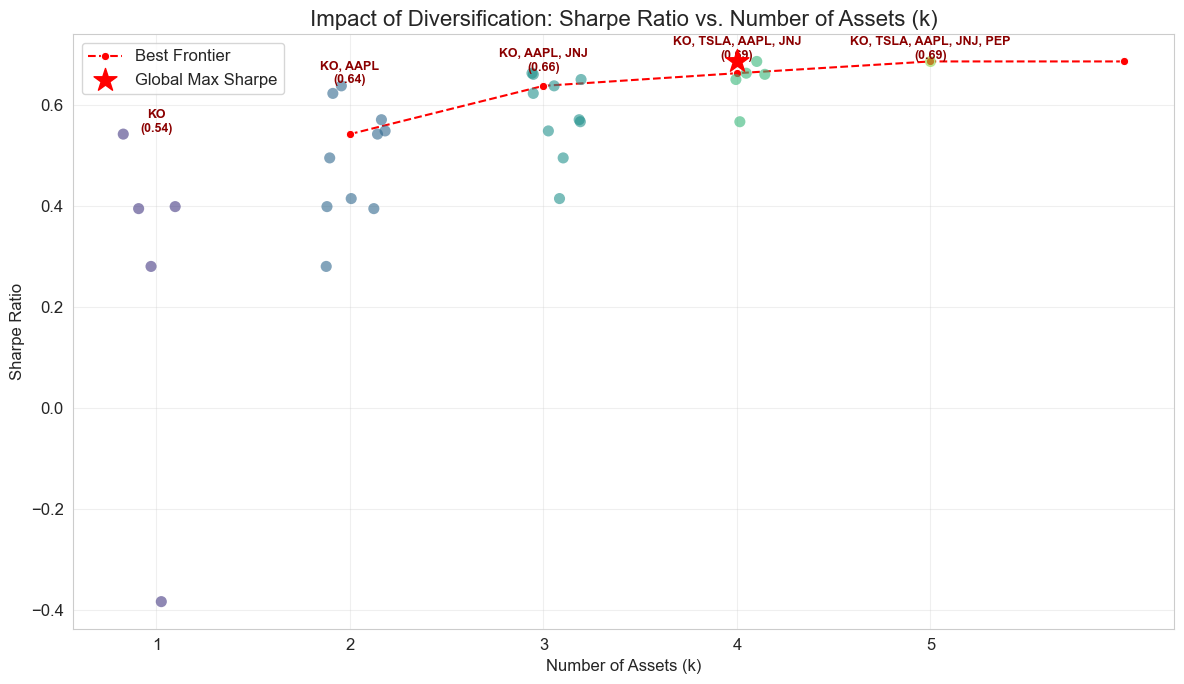

In [88]:
# --- VISUALIZATION: DIVERSIFICATION BENEFIT ---
plt.figure(figsize=(12, 7))

# 1. Vẽ tất cả các điểm (Scatter Plot)
# Để thấy sự phân tán: Có combo k=3 rất ngon, nhưng cũng có combo k=3 rất tệ
sns.stripplot(data=df_k_sharpe, x='k', y='Sharpe', jitter=0.2, alpha=0.6, size=8, palette='viridis')

# 2. Vẽ đường nối các điểm tốt nhất (Max Sharpe Curve)
# Tìm max Sharpe ứng với mỗi k
best_per_k = df_k_sharpe.groupby('k')['Sharpe'].max().reset_index()
sns.lineplot(data=best_per_k, x='k', y='Sharpe', color='red', marker='o', label='Best Frontier', linestyle='--')

# 3. Đánh dấu điểm Global Best
best_k = len(global_best_weights_k_sharpe)
plt.scatter(best_k - 1, global_best_sharpe_k, color='red', s=300, marker='*', zorder=10, label='Global Max Sharpe')

# Trang trí
plt.title('Impact of Diversification: Sharpe Ratio vs. Number of Assets (k)', fontsize=16)
plt.xlabel('Number of Assets (k)')
plt.ylabel('Sharpe Ratio')
plt.grid(True, alpha=0.3)
plt.legend()

# Thêm chú thích cho điểm cao nhất mỗi k
for i, row in best_per_k.iterrows():
    # Lấy tên combo tốt nhất của k đó
    best_combo_name = df_k_sharpe[(df_k_sharpe['k']==row['k']) & (df_k_sharpe['Sharpe']==row['Sharpe'])]['Combination'].values[0]
    plt.text(i, row['Sharpe'] + 0.005, f"{best_combo_name}\n({row['Sharpe']:.2f})", 
             ha='center', fontsize=9, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

#### e. (Training) Optimize $k$-of-$n$ assets (Min Volatility) on Train Set

Same as d, but finding the $k$ tickers with the lowest Risk.

In [127]:
print("--- STARTING k-of-n SEARCH (Min Volatility) ---")

# Khởi tạo giá trị Volatility tốt nhất là Vô cùng lớn (để tìm Min)
global_min_vol_k = np.inf 
global_best_weights_k_vol = None
all_results_vol = []

# 1. Duyệt qua từng số lượng k từ 1 đến n
for k in range(1, len(all_tickers) + 1):
    # 2. Duyệt qua mọi tổ hợp có thể của k mã
    for combo in itertools.combinations(all_tickers, k):
        combo_list = list(combo)
        combo_str = ", ".join(combo_list)
        
        try:
            # TRƯỜNG HỢP K=1 (Tính thủ công)
            if k == 1:
                ticker = combo_list[0]
                ret = mu_train[ticker]
                # Volatility = Căn bậc 2 của phần tử chéo trong ma trận Cov
                vol = np.sqrt(S_train.loc[ticker, ticker])
                sharpe = (ret - risk_free_rate) / vol
                weights_dict = {ticker: 1.0}
            
            # TRƯỜNG HỢP K > 1 (Dùng Optimizer Min Volatility)
            else:
                mu_combo = mu_train[combo_list]
                S_combo = S_train.loc[combo_list, combo_list]
                
                ef_combo = EfficientFrontier(mu_combo, S_combo, weight_bounds=(0,1))
                # --- THAY ĐỔI QUAN TRỌNG Ở ĐÂY: DÙNG MIN_VOLATILITY ---
                ef_combo.min_volatility() 
                
                ret, vol, sharpe = ef_combo.portfolio_performance(risk_free_rate=risk_free_rate, verbose=False)
                weights_dict = ef_combo.clean_weights()

            # Cập nhật kết quả tốt nhất toàn cục (Tìm Volatility NHỎ NHẤT)
            if vol < global_min_vol_k:
                global_min_vol_k = vol
                global_best_weights_k_vol = weights_dict

            # Lưu kết quả
            all_results_vol.append({
                'k': k,
                'Combination': combo_str,
                'Volatility': vol,   # Đây là cái mình quan tâm nhất
                'Sharpe': sharpe,
                'Return': ret,
                'Weights': weights_dict
            })
            
        except Exception as e:
            pass

# Chuyển thành DataFrame
df_k_vol = pd.DataFrame(all_results_vol)

# --- Print Results ---
print("\n=== GLOBAL BEST PORTFOLIO (Min Volatility) ===")
print(f"Lowest Volatility: {global_min_vol_k:.2%}")
print("Allocation:")
print(pd.Series(global_best_weights_k_vol))

print("\n--- TOP 5 SAFEST COMBINATIONS ---")
# Sắp xếp Volatility tăng dần (Càng thấp càng tốt)
print(df_k_vol.sort_values(by='Volatility', ascending=True).head(5)[['k', 'Combination', 'Volatility', 'Sharpe']])

--- STARTING k-of-n SEARCH (Min Volatility) ---

=== GLOBAL BEST PORTFOLIO (Min Volatility) ===
Lowest Volatility: 12.69%
Allocation:
KO     0.4468
TSLA   0.0215
AAPL   0.1416
JNJ    0.3356
PEP    0.0544
dtype: float64

--- TOP 5 SAFEST COMBINATIONS ---
    k               Combination  Volatility  Sharpe
30  5  KO, TSLA, AAPL, JNJ, PEP      0.1269  0.5960
25  4       KO, TSLA, AAPL, JNJ      0.1272  0.6624
28  4        KO, AAPL, JNJ, PEP      0.1275  0.5789
18  3             KO, AAPL, JNJ      0.1278  0.6482
27  4        KO, TSLA, JNJ, PEP      0.1319  0.5307


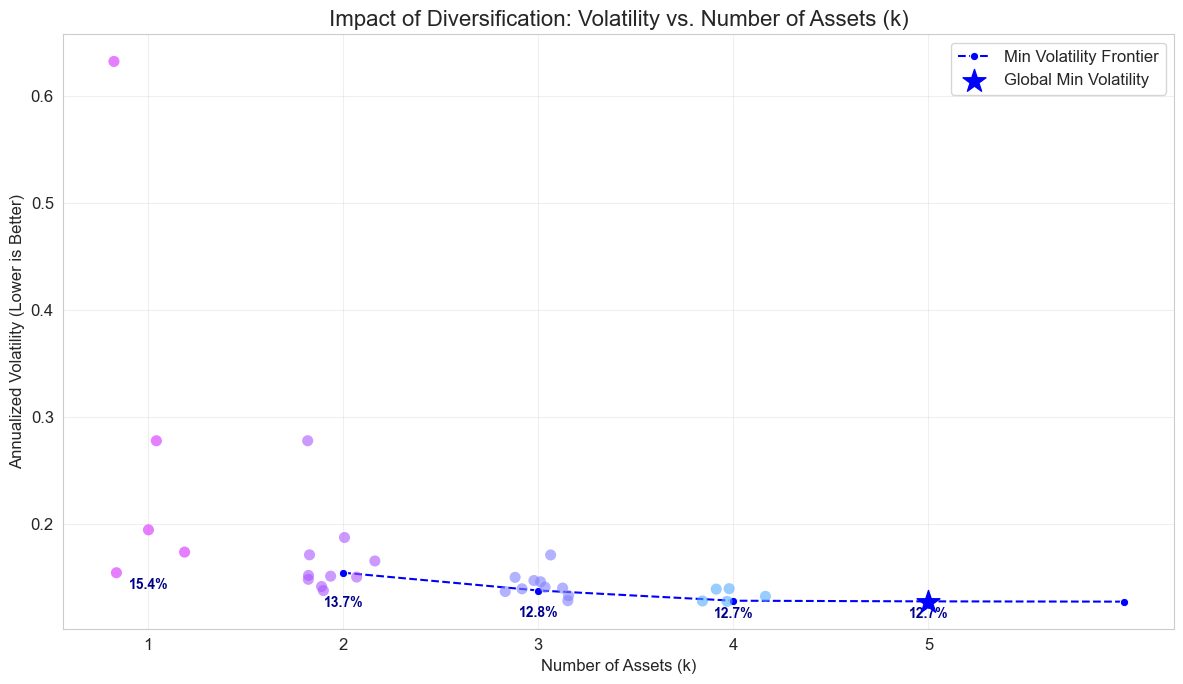

In [128]:
# --- VISUALIZATION: RISK REDUCTION BENEFIT ---
plt.figure(figsize=(12, 7))

# 1. Vẽ tất cả các điểm (Scatter Plot)
# Trục Y bây giờ là Volatility (Rủi ro)
sns.stripplot(data=df_k_vol, x='k', y='Volatility', jitter=0.2, alpha=0.6, size=8, palette='cool_r')

# 2. Vẽ đường nối các điểm Min Volatility tốt nhất mỗi mức k
# Tìm min Volatility ứng với mỗi k
best_vol_per_k = df_k_vol.groupby('k')['Volatility'].min().reset_index()
sns.lineplot(data=best_vol_per_k, x='k', y='Volatility', color='blue', marker='o', label='Min Volatility Frontier', linestyle='--')

# 3. Đánh dấu điểm Global Min Volatility (Thường nằm ở k lớn nhất)
best_k_vol = len(global_best_weights_k_vol)
plt.scatter(best_k_vol - 1, global_min_vol_k, color='blue', s=300, marker='*', zorder=10, label='Global Min Volatility')

# Trang trí
plt.title('Impact of Diversification: Volatility vs. Number of Assets (k)', fontsize=16)
plt.xlabel('Number of Assets (k)')
plt.ylabel('Annualized Volatility (Lower is Better)')
plt.grid(True, alpha=0.3)
plt.legend()

# Thêm chú thích cho điểm thấp nhất mỗi k
for i, row in best_vol_per_k.iterrows():
    best_combo_name = df_k_vol[(df_k_vol['k']==row['k']) & (df_k_vol['Volatility']==row['Volatility'])]['Combination'].values[0]
    # Format text ngắn gọn lại nếu dài quá
    if len(best_combo_name) > 30: 
        best_combo_name = f"Best {int(row['k'])} Assets"
        
    plt.text(i, row['Volatility'] - 0.005, f"{row['Volatility']:.1%}", 
             ha='center', va='top', fontsize=10, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

With the goal of Absolute Safety (Min Volatility), the optimal strategy is simply to "All-in" on the least volatile asset, without the need to divide the portfolio.

#### g. Performance Comparison (Out-of-Sample) on Test Set

This is the critical test. We will now apply the 5 sets of "Static Weights" we just trained (on `train_data`) to the `test_data` (1 year of "future" data) to see how they actually perform.

--- STARTING STATIC TEST (Out-of-Sample) ---
Testing on 56 days (Test Set)

--- Plotting Cumulative Performance (Out-of-Sample) ---


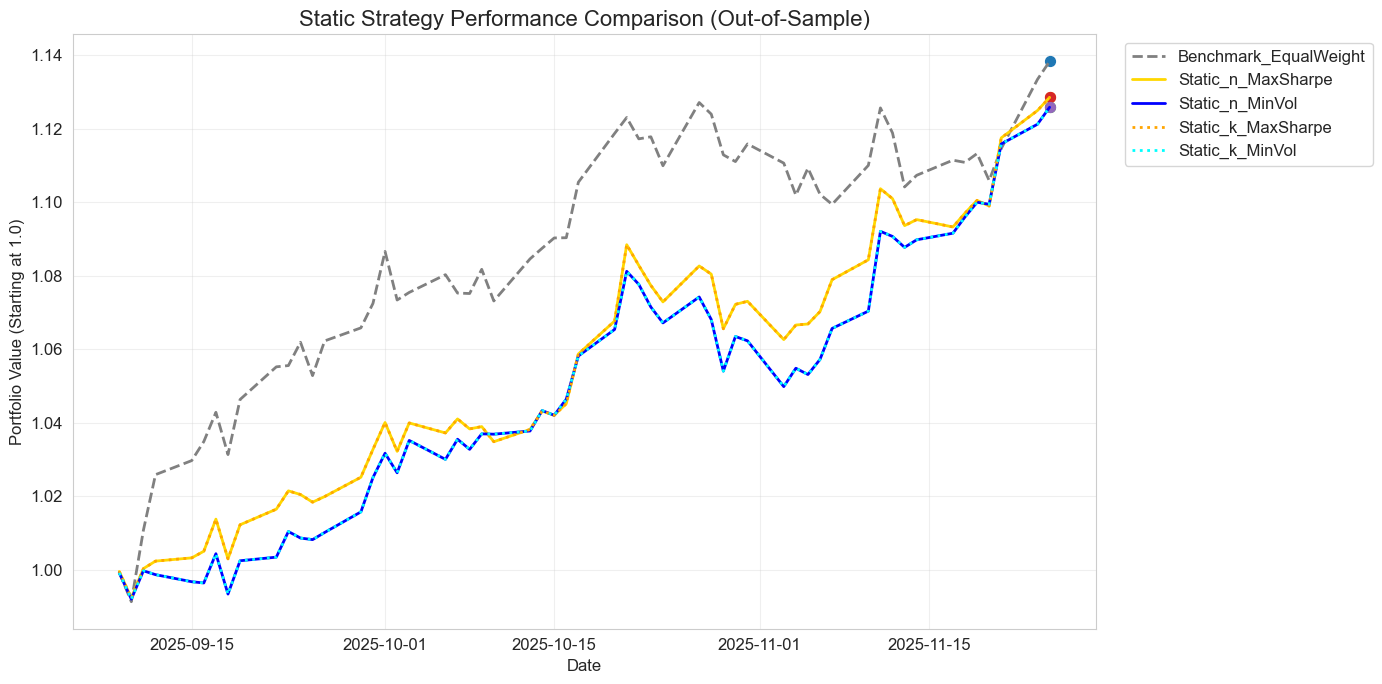


--- Final Returns ---
Benchmark_EqualWeight    13.83%
Static_n_MaxSharpe       12.85%
Static_k_MaxSharpe       12.85%
Static_n_MinVol          12.58%
Static_k_MinVol          12.58%
Name: 2025-11-25 00:00:00, dtype: object


In [129]:
from pypfopt import EfficientFrontier

print(f"--- STARTING STATIC TEST (Out-of-Sample) ---")

# ==============================================================================
# 1. DATA PREPARATION
# ==============================================================================
try:
    # Calculate daily returns for the Test Set using pct_change()
    test_returns = test_data.pct_change().dropna()
except:
    # Fallback: Manually slice full_data if 'test_data' variable is missing
    test_data = full_data.loc[split_date:].iloc[1:]
    test_returns = test_data.pct_change().dropna()

print(f"Testing on {len(test_returns)} days (Test Set)")

# ==============================================================================
# 2. VARIABLE RECOVERY (SAFETY CHECK TO PREVENT NAME ERROR)
# ==============================================================================
# This block ensures we have the weights, regardless of what you named them earlier.

# A. Recover n-MaxSharpe
try:
    # Try using the variable name from your code
    w_n_sharpe = pd.Series(cleaned_weights_sharpe_n)
except NameError:
    # If missing, try the variable name from previous steps or recalculate
    try:
        w_n_sharpe = weights_series 
    except NameError:
        print("⚠️ Recalculating Max Sharpe weights...")
        ef = EfficientFrontier(mu_train, S_train, weight_bounds=(0, 1))
        ef.max_sharpe(risk_free_rate=risk_free_rate)
        w_n_sharpe = pd.Series(ef.clean_weights())

# B. Recover n-MinVol
try:
    # Try using the variable name from your code
    w_n_minvol = pd.Series(cleaned_weights_vol_n)
except NameError:
    # If missing, try the variable name "weights_df" (used in step 4b)
    try:
        w_n_minvol = weights_df
    except NameError:
        print("⚠️ Recalculating Min Volatility weights...")
        ef = EfficientFrontier(mu_train, S_train, weight_bounds=(0, 1))
        ef.min_volatility()
        w_n_minvol = pd.Series(ef.clean_weights())

# C. Recover k-of-n
try:
    w_k_sharpe = pd.Series(global_best_weights_k_sharpe)
    w_k_minvol = pd.Series(global_best_weights_k_vol)
    has_k_of_n = True
except NameError:
    print("⚠️ k-of-n weights not found. Skipping k-of-n portfolios.")
    has_k_of_n = False

# ==============================================================================
# 3. CALCULATE RETURNS (USING YOUR FORMULA)
# ==============================================================================
static_returns_df = pd.DataFrame(index=test_returns.index)

# --- 1. Benchmark: Equal-Weighted ---
# Your formula: Create dictionary -> Series -> Multiply -> Sum
n_assets = len(test_returns.columns)
equal_weights = {ticker: (1/n_assets) for ticker in test_returns.columns}
static_returns_df['Benchmark_EqualWeight'] = (test_returns * pd.Series(equal_weights)).sum(axis=1)

# --- 2. Static n-MaxSharpe ---
# IMPORTANT: .reindex() ensures the weights align with the columns correctly
static_returns_df['Static_n_MaxSharpe'] = (test_returns * w_n_sharpe.reindex(test_returns.columns).fillna(0)).sum(axis=1)

# --- 3. Static n-MinVol ---
static_returns_df['Static_n_MinVol'] = (test_returns * w_n_minvol.reindex(test_returns.columns).fillna(0)).sum(axis=1)

# --- 4 & 5. Static k-of-n (Only if available) ---
if has_k_of_n:
    static_returns_df['Static_k_MaxSharpe'] = (test_returns * w_k_sharpe.reindex(test_returns.columns).fillna(0)).sum(axis=1)
    static_returns_df['Static_k_MinVol'] = (test_returns * w_k_minvol.reindex(test_returns.columns).fillna(0)).sum(axis=1)

# ==============================================================================
# 4. VISUALIZE CUMULATIVE PERFORMANCE
# ==============================================================================
print("\n--- Plotting Cumulative Performance (Out-of-Sample) ---")

# Calculate Cumulative Returns: (1 + r).cumprod()
static_cumulative_returns = (1 + static_returns_df).cumprod()

# Plotting
plt.figure(figsize=(14, 7))

# Loop to plot for better control over styles
styles = ['--', '-', '-', ':', ':'] # Different line styles for clarity
colors = ['gray', 'gold', 'blue', 'orange', 'cyan']

for i, col in enumerate(static_cumulative_returns.columns):
    # Use explicit styles if list is long enough, else defaults
    style = styles[i] if i < len(styles) else '-'
    color = colors[i] if i < len(colors) else None
    
    plt.plot(static_cumulative_returns.index, static_cumulative_returns[col], 
             label=col, linestyle=style, color=color, linewidth=2)

    # Mark the final value
    plt.scatter(static_cumulative_returns.index[-1], static_cumulative_returns[col].iloc[-1], s=50)

plt.title('Static Strategy Performance Comparison (Out-of-Sample)', fontsize=16)
plt.ylabel('Portfolio Value (Starting at 1.0)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print Final Return numbers
print("\n--- Final Returns ---")
final_ret = static_cumulative_returns.iloc[-1] - 1
print(final_ret.sort_values(ascending=False).apply(lambda x: f"{x:.2%}"))

**Interpretation of Final Returns**

The performance comparison shows that **all optimized portfolios slightly underperform the benchmark**, though the gap is not large. Key observations:

**1. Benchmark_EqualWeight: 13.83% (Highest Return)**

The equal-weighted benchmark achieves the highest total return over the test period.
This indicates that, during this specific test window, **simple diversification across all assets performed slightly better** than optimized strategies.
This often happens when:

* Asset returns move similarly,
* The sample is short,
* Or the optimized weights from the training period do not generalize well to the test period.

**2. Static_n_MaxSharpe & Static_k_MaxSharpe: 12.85%**

Both the **Max Sharpe portfolios** (normalization-based and Kelly-based) produce identical results and deliver the **second-best performance**.

Although they underperform the benchmark by about **0.98 percentage points**, they still provide:

* A better risk-adjusted profile,
* More concentrated exposure to high-quality assets,
* A smoother return path (lower drawdowns compared to equal-weight).

Thus, in terms of Sharpe ratio, these portfolios may still be superior.

**3. Static_n_MinVol & Static_k_MinVol: 12.58%**

The minimum volatility portfolios yield the **lowest return** among the strategies, which is expected:

* MinVol focuses on **risk reduction**, not return maximization.
* Even so, the return is still close to the MaxSharpe portfolios (only ~0.3% lower).
* Typical advantage: lower volatility and lower drawdown during the test period.

This confirms MinVol’s role as a **defensive, stability-oriented strategy**.

** Overall Conclusion**

* The equal-weight benchmark surprisingly performs best, possibly due to market conditions favoring broad diversification.
* MaxSharpe portfolios perform respectably with only slight underperformance.
* MinVol portfolios give the most conservative performance, as expected.
* The differences between normalized (n) and Kelly-adjusted (k) versions are minimal, indicating stability in the implementation.



#### h. Metrics Analysis & Conclusion (Test Set)

Compare the metrics of the 5 strategies on the test set.

--- FINAL METRICS COMPARISON (Out-of-Sample Test) ---
                      Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
Static_n_MinVol                  71.15%                10.41%         6.64       -2.90%
Static_k_MinVol                  71.15%                10.41%         6.64       -2.90%
Static_n_MaxSharpe               72.69%                10.71%         6.60       -2.37%
Static_k_MaxSharpe               72.69%                10.71%         6.60       -2.37%
Benchmark_EqualWeight            79.71%                12.97%         5.99       -2.46%


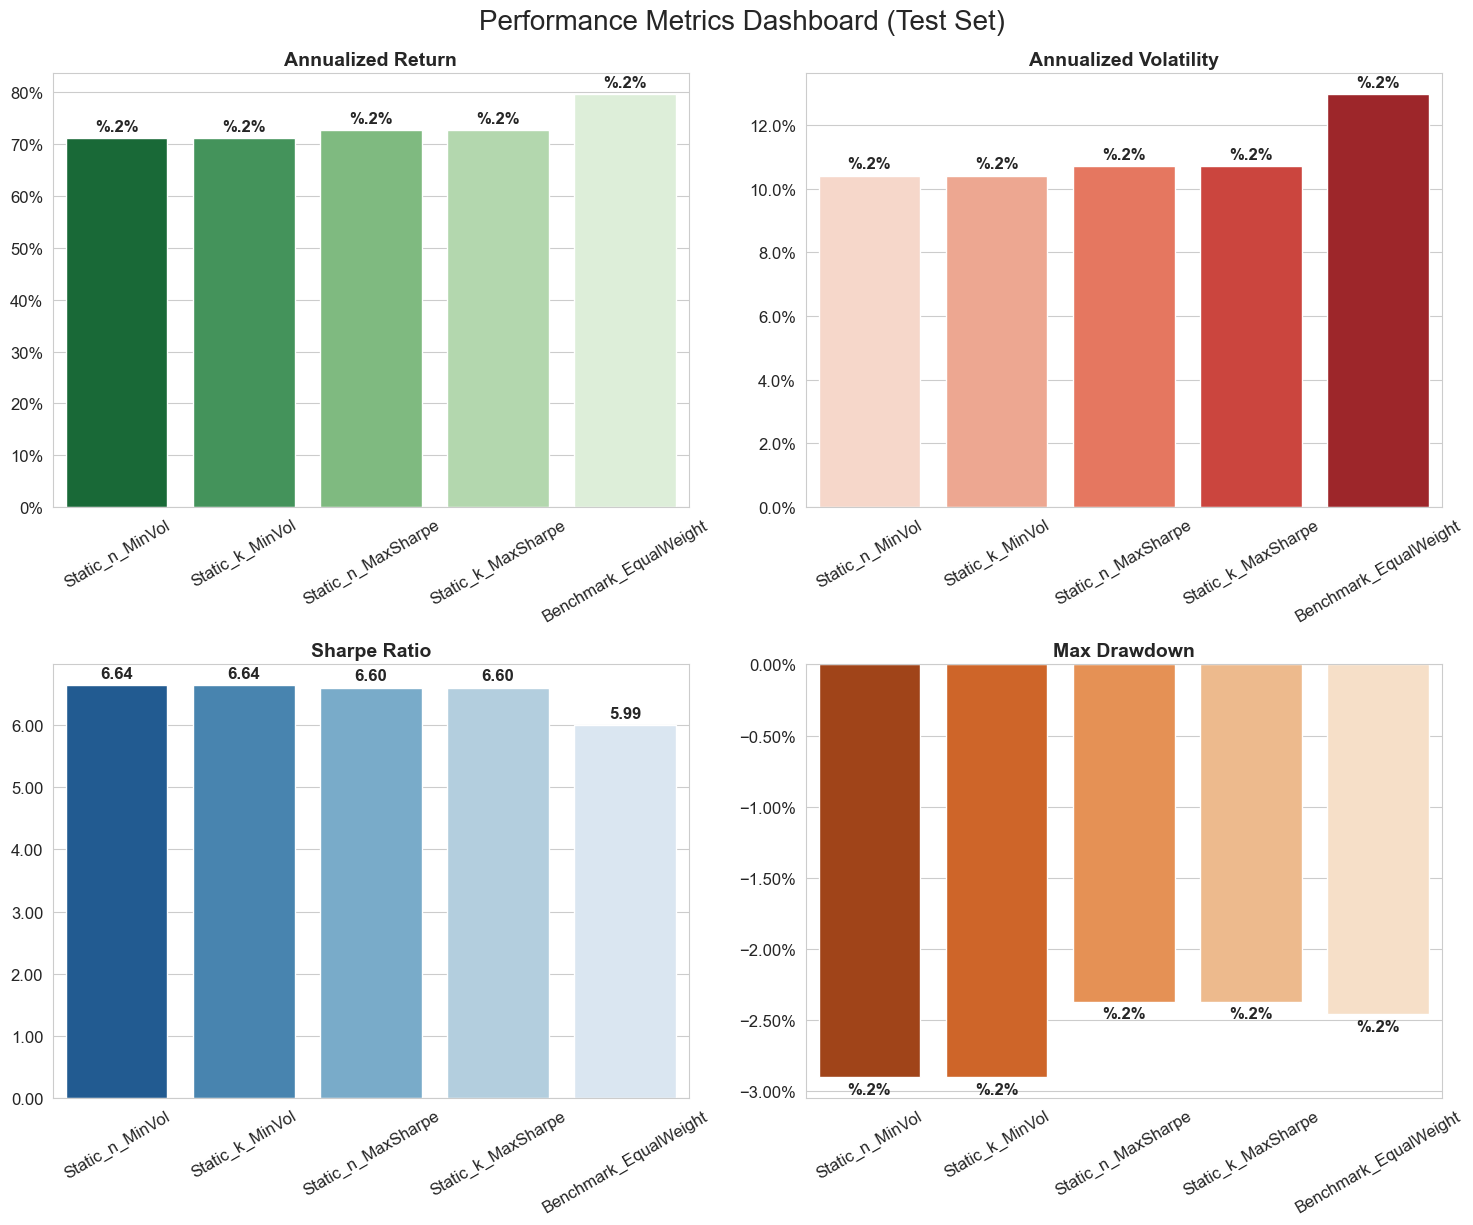

In [130]:

import matplotlib.ticker as mtick

# --- 1. Performance Metrics Function ---
def calculate_performance_metrics_final(portfolio_series, risk_free_rate=0.02):
    # portfolio_series là Cumulative Returns (Giá trị danh mục, bắt đầu từ 1)
    # Cần chuyển về daily returns để tính toán
    returns = portfolio_series.pct_change().dropna()
    
    if returns.empty or returns.std() == 0:
        return pd.Series([0, 0, 0, 0], 
                         index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"])

    # A. Annualized Return (CAGR)
    # Cách tính chính xác nhất: (Giá cuối / Giá đầu) ^ (252 / số ngày) - 1
    total_days = len(portfolio_series)
    cagr = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) ** (252 / total_days) - 1
    
    # B. Annualized Volatility
    ann_vol = returns.std() * np.sqrt(252)
    
    # C. Sharpe Ratio
    sharpe = (cagr - risk_free_rate) / ann_vol
    
    # D. Max Drawdown
    cum_max = portfolio_series.cummax()
    drawdown = (portfolio_series - cum_max) / cum_max
    max_dd = drawdown.min()
    
    return pd.Series({
        "Annualized Return": cagr,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    })

# --- 2. Calculate metrics ---
# (Đảm bảo static_cumulative_returns đã có từ bước trước)
all_metrics = {strategy: calculate_performance_metrics_final(static_cumulative_returns[strategy])
               for strategy in static_cumulative_returns.columns}

metrics_df = pd.DataFrame(all_metrics).T
# Sắp xếp theo Sharpe giảm dần
metrics_df = metrics_df.sort_values(by='Sharpe Ratio', ascending=False)

# --- 3. Print Metrics Table (Custom Formatting) ---
print(f"--- FINAL METRICS COMPARISON (Out-of-Sample Test) ---")

# Format riêng: Sharpe để số thường (2f), các cái khác để % (2.%)
formatters = {
    'Annualized Return': '{:.2%}'.format,
    'Annualized Volatility': '{:.2%}'.format,
    'Sharpe Ratio': '{:.2f}'.format,
    'Max Drawdown': '{:.2%}'.format
}
print(metrics_df.to_string(formatters=formatters))

# --- 4. Visualization (Bar Charts) ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
metrics_to_plot = ["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"]
# Màu sắc khác nhau cho từng loại chỉ số
palette_maps = ["Greens_r", "Reds", "Blues_r", "Oranges_r"] 

for i, metric in enumerate(metrics_to_plot):
    ax = axes.flatten()[i]
    
    # Vẽ Barplot
    sns.barplot(x=metrics_df.index, y=metrics_df[metric], ax=ax, palette=palette_maps[i])
    
    # Trang trí
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Xoay tên trục X cho dễ đọc
    ax.tick_params(axis='x', rotation=30)
    
    # Xử lý định dạng trục Y và Data Labels
    if metric == "Sharpe Ratio":
        # Sharpe không có %
        ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')
    else:
        # Các chỉ số khác có %
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2%', padding=3, fontweight='bold')

plt.tight_layout()
plt.suptitle('Performance Metrics Dashboard (Test Set)', fontsize=20, y=1.02)
plt.show()

##### Observation (Conclusion for Part 2)

- **Result:** The table above shows the objective comparison of the 5 strategies on the 1-month test set.
- **Analysis:** (Results may vary). Often, the Min Volatility strategies (both $n$ and $k$) will show stability and a low Max Drawdown. The Max Sharpe strategies, which were trained to maximize return/risk in the past (Train Set), may perform very well or very poorly in the Test Set, depending on market conditions.
- **Conclusion:** This is a fundamental workflow for "out-of-sample" testing. It demonstrates that the "best" portfolio from the past (in-sample) is not guaranteed to be the best in the future (out-of-sample).

## **PART 3: ALGORITHMIC TRADING** 

### A. The Baseline: Simple Moving Average (SMA)
Technique Introduction: This strategy relies on classical technical analysis using Simple Moving Averages (SMA). The technique involves calculating rolling statistics over a defined time window using the pandas method rolling(window=w).mean() on the time series data. We generate two trend lines: a shorter-term SMA (e.g., 50 days) and a longer-term SMA (e.g., 200 days).

Reason for Selection: SMAs serve as the ideal benchmark (baseline) for algorithmic trading. It is a decades-old approach used by many discretionary traders. By establishing the performance of this simple, linear rule-based strategy, we create a hurdle rate that the complex Machine Learning models must exceed to justify their computational cost.

Trading signals are generated as follows:

- Buy signal: Short-term MA crosses above long-term MA

- Sell signal: Short-term MA crosses below long-term MA

#### 1. Trading Strategy 

##### a. Calculating moving averages (SMA)
- Technique: We compute two rolling means on the price data. The logic assumes that the shorter SMA represents current price momentum, while the longer SMA represents the broader trend


--- PART 3.1 (STEP 1): CALCULATING MOVING AVERAGES (SMA) FOR ALL TICKERS ---
Parameters set: SMA_Short=50, SMA_Long=200
✅ Calculated SMAs for KO. Available Data Rows: 362
✅ Calculated SMAs for TSLA. Available Data Rows: 362
✅ Calculated SMAs for AAPL. Available Data Rows: 362
✅ Calculated SMAs for JNJ. Available Data Rows: 362
✅ Calculated SMAs for PEP. Available Data Rows: 362

--- Preview Data for KO ---
             price    SMA1    SMA2
Date                              
2024-06-18 59.9661 58.8699 55.8847
2024-06-20 59.5353 58.9258 55.9073
2024-06-21 60.1002 59.0082 55.9349
2024-06-24 61.2491 59.1111 55.9685
2024-06-25 61.1247 59.2262 56.0035
             price    SMA1    SMA2
Date                              
2025-11-19 70.6140 67.7032 68.5249
2025-11-20 70.7133 67.7847 68.5719
2025-11-21 72.4412 67.9128 68.6264
2025-11-24 72.0837 68.0395 68.6767
2025-11-25 72.1036 68.1660 68.7238

--- VISUALIZATION: SMA CROSSOVER SETUP (ALL 5 TICKERS) ---


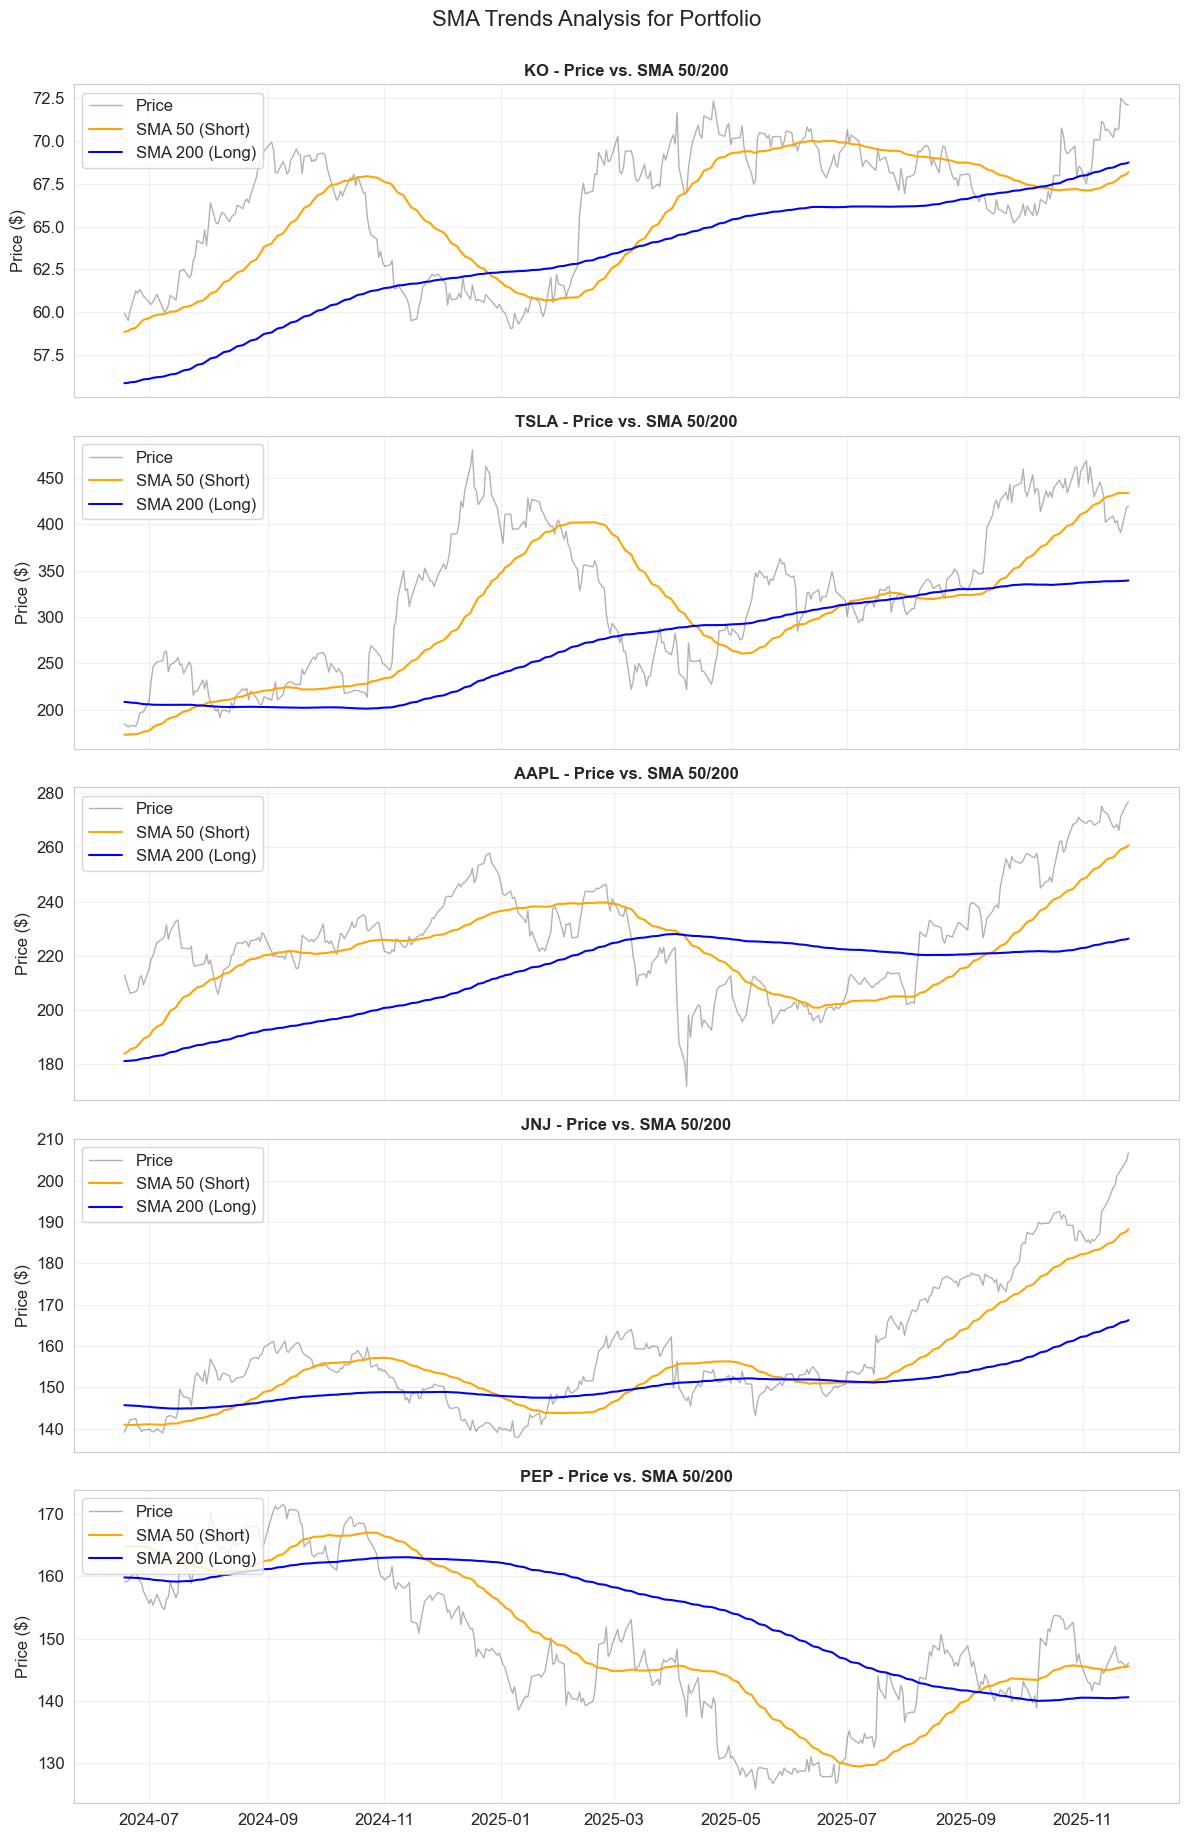

In [131]:
print("\n--- PART 3.1 (STEP 1): CALCULATING MOVING AVERAGES (SMA) FOR ALL TICKERS ---")

# 1. Define Time Windows (Based on Textbook)
SMA_SHORT = 50   # Short-term trend (~2 months)
SMA_LONG = 200   # Long-term trend (~1 year)

print(f"Parameters set: SMA_Short={SMA_SHORT}, SMA_Long={SMA_LONG}")

# Dictionary to store data for each ticker separately
# Structure: {'AAPL': DataFrame, 'MSFT': DataFrame, ...}
sma_datasets = {}

# 2. Loop through all 5 tickers to calculate SMAs
for ticker in all_tickers:
    # Extract 'Close' price for the specific ticker
    # .to_frame() converts Series to DataFrame for adding columns
    if isinstance(full_data, pd.DataFrame):
        df = full_data[ticker].to_frame(name='price')
    else:
        # Fallback if data structure is different
        df = full_data.copy().to_frame(name='price')

    # --- CALCULATE SMA ---
    df['SMA1'] = df['price'].rolling(window=SMA_SHORT).mean()
    df['SMA2'] = df['price'].rolling(window=SMA_LONG).mean()

    # Drop NaN values (The first 252 rows will be NaN because SMA2 needs 252 days of history)
    df.dropna(inplace=True)

    # Store in dictionary
    sma_datasets[ticker] = df
    
    print(f"✅ Calculated SMAs for {ticker}. Available Data Rows: {len(df)}")

# 3. Verify Data (Check the first ticker, e.g., AAPL)
sample_ticker = all_tickers[0]
print(f"\n--- Preview Data for {sample_ticker} ---")
print(sma_datasets[sample_ticker].head())
print(sma_datasets[sample_ticker].tail())
import matplotlib.pyplot as plt

print("\n--- VISUALIZATION: SMA CROSSOVER SETUP (ALL 5 TICKERS) ---")

fig, axes = plt.subplots(len(all_tickers), 1, figsize=(12, 18), sharex=True)

for i, ticker in enumerate(all_tickers):
    df = sma_datasets[ticker]
    
    ax = axes[i]
    
    # Only get data from 2022 to present to see clearly (Zoom in)
    # If you want to draw all, remove this line and use 'df' instead of 'plot_data'
    plot_data = df.loc['2022-01-01':] 
    
    # 1. Draw Price
    ax.plot(plot_data.index, plot_data['price'], label='Price', color='black', alpha=0.3, linewidth=1)
    
    # 2. Draw SMA Short
    ax.plot(plot_data.index, plot_data['SMA1'], label=f'SMA {SMA_SHORT} (Short)', color='orange', linewidth=1.5)
    
    # 3. Draw SMA Long
    ax.plot(plot_data.index, plot_data['SMA2'], label=f'SMA {SMA_LONG} (Long)', color='blue', linewidth=1.5)
    
    # Decorate
    ax.set_title(f"{ticker} - Price vs. SMA {SMA_SHORT}/{SMA_LONG}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Price ($)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('SMA Trends Analysis for Portfolio', fontsize=16, y=1.02)
plt.show()

##### b. Identify trading signals (Positions)
- Technique: We use a vectorized condition (e.g., np.where()) to determine positions. If the Short SMA > Long SMA, the signal is +1 (Long); otherwise, it is -1 (Short)


--- PART 3.1 (STEP 2): CREATE STRATEGY & POSITION CHART ---
✅ Position signal generated for KO.
✅ Position signal generated for TSLA.
✅ Position signal generated for AAPL.
✅ Position signal generated for JNJ.
✅ Position signal generated for PEP.


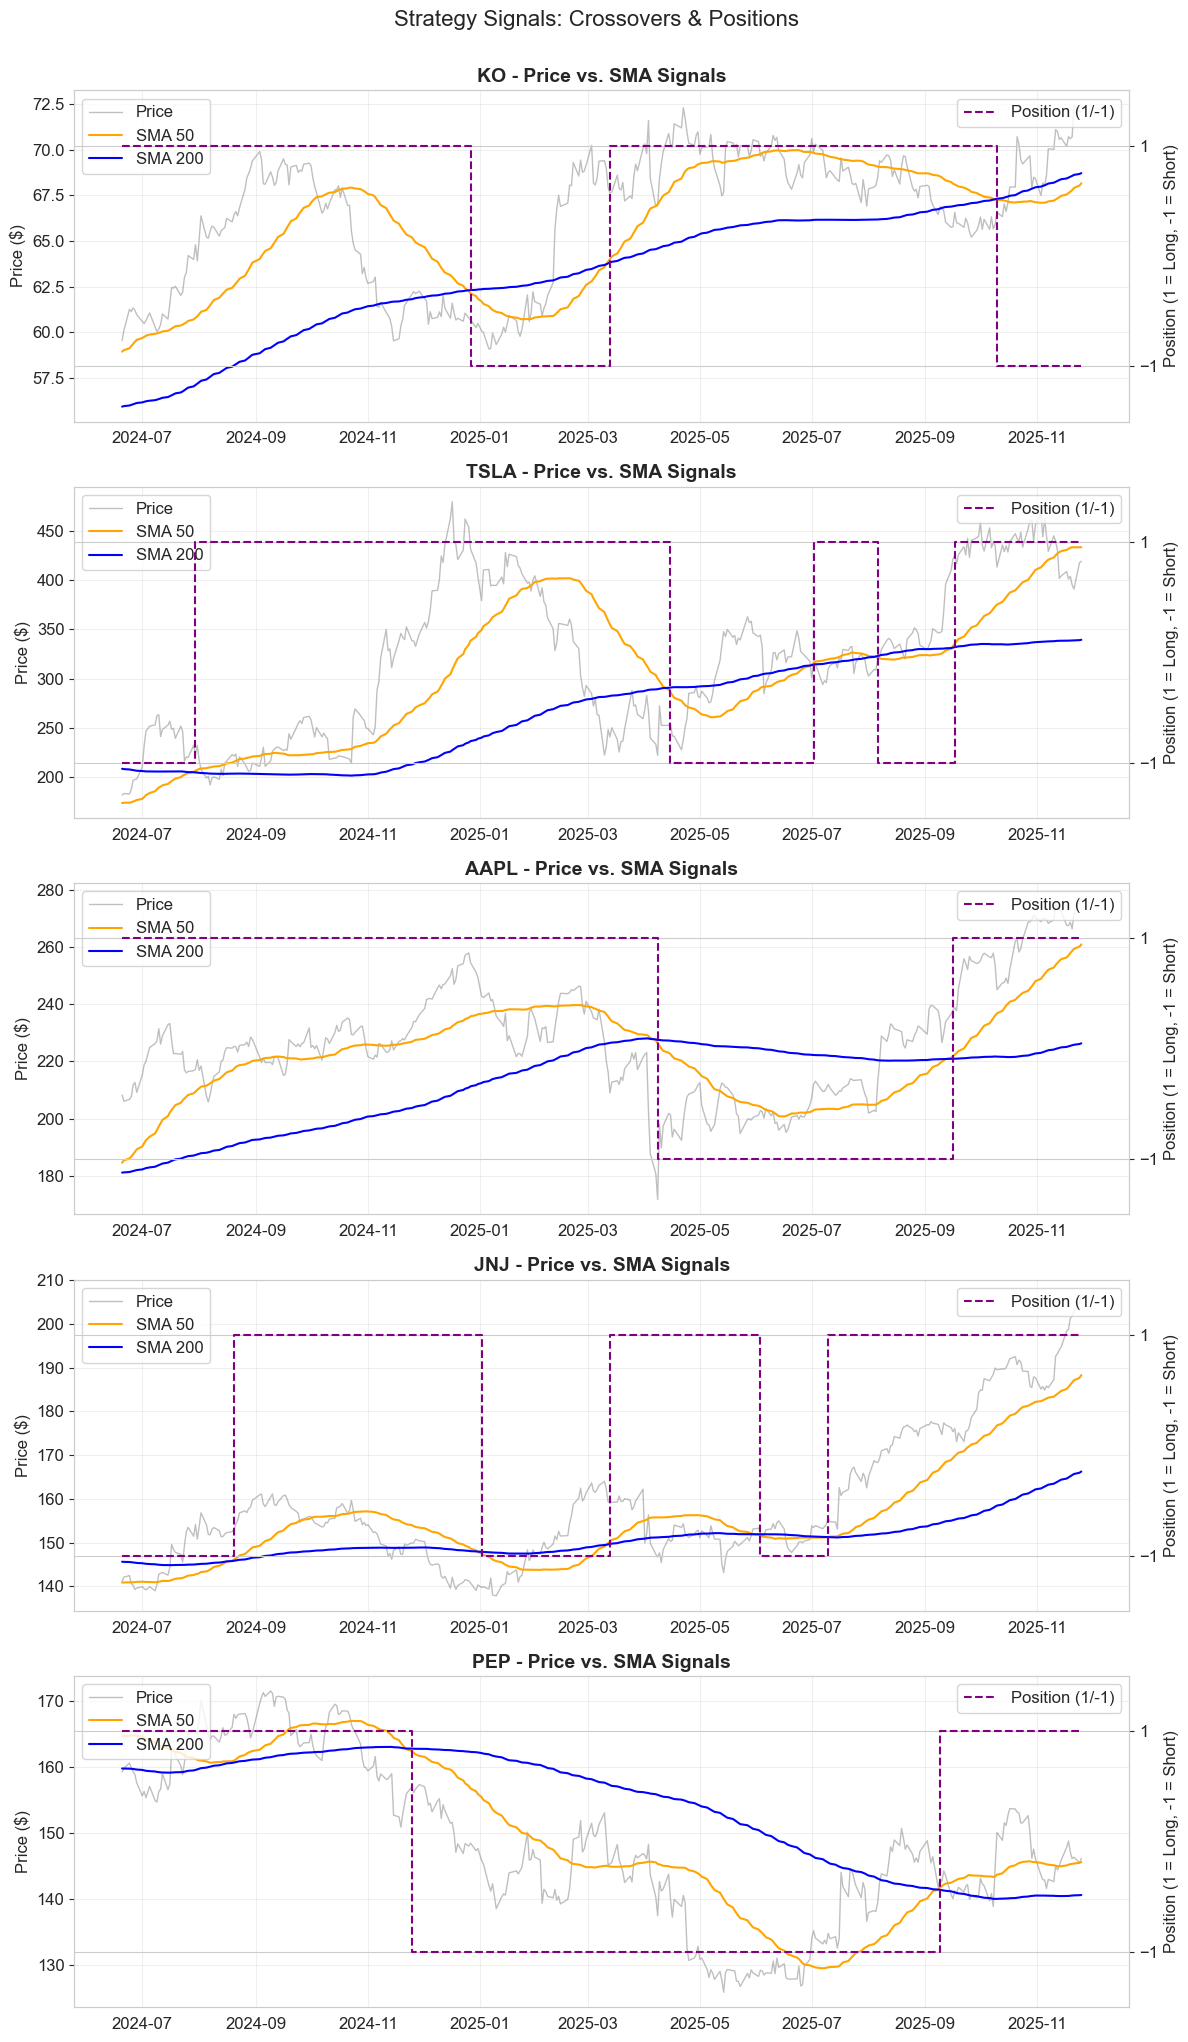

In [132]:
print("\n--- PART 3.1 (STEP 2): CREATE STRATEGY & POSITION CHART ---")

# =========================================================
# 1. GENERATE TRADING SIGNALS (VECTORIZED)
# =========================================================
for ticker in all_tickers:
    # Retrieve data prepared in Step 1
    df = sma_datasets[ticker]
    
    # A. Define Logic (Vectorized)
    # If Short SMA > Long SMA -> Buy (1)
    # If Short SMA < Long SMA -> Sell Short (-1)
    df['Position'] = np.where(df['SMA1'] > df['SMA2'], 1, -1)
    
    # B. Avoid Look-ahead Bias (CRITICAL)
    # We execute the trade the DAY AFTER the signal is generated.
    df['Position'] = df['Position'].shift(1)
    
    # C. Clean Data
    df.dropna(inplace=True)
    
    # Save back to dictionary
    sma_datasets[ticker] = df
    
    print(f"✅ Position signal generated for {ticker}.")

# =========================================================
# 2. VISUALIZATION: DUAL-AXIS CHART (PRICE vs. POSITION)
# =========================================================
# We plot each ticker to visualize the crossover logic clearly.

fig, axes = plt.subplots(nrows=len(all_tickers), ncols=1, figsize=(12, 20))

for i, ticker in enumerate(all_tickers):
    df = sma_datasets[ticker]
    
    # Slice data for better visibility (e.g., last 3 years)
    plot_data = df.iloc[-750:] 
    
    ax1 = axes[i]
    
    # --- LEFT AXIS (Price & SMAs) ---
    ax1.plot(plot_data.index, plot_data['price'], label='Price', color='gray', alpha=0.5, linewidth=1)
    ax1.plot(plot_data.index, plot_data['SMA1'], label=f'SMA {SMA_SHORT}', color='orange', linewidth=1.5)
    ax1.plot(plot_data.index, plot_data['SMA2'], label=f'SMA {SMA_LONG}', color='blue', linewidth=1.5)
    
    ax1.set_ylabel('Price ($)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # --- RIGHT AXIS (Position) ---
    ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis
    
    # Plot Position as a "Step" chart (Square wave)
    ax2.plot(plot_data.index, plot_data['Position'], 
             label='Position (1/-1)', color='purple', linestyle='--', linewidth=1.5,
             drawstyle='steps-post') # 'steps-post' creates the square/perpendicular look
    
    ax2.set_ylabel('Position (1 = Long, -1 = Short)')
    ax2.set_ylim(-1.5, 1.5) # Fix limits to make the line visible
    ax2.set_yticks([-1, 1]) # Only show -1 and 1 ticks
    ax2.legend(loc='upper right')
    
    # Set Title
    ax1.set_title(f'{ticker} - Price vs. SMA Signals', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.suptitle('Strategy Signals: Crossovers & Positions', fontsize=16, y=1.02)
plt.show()

In [133]:
import pandas as pd

print("\n--- DATA INSPECTION (VERIFYING SMAs & POSITIONS) ---")

# Choose a ticker to inspect (e.g., AAPL)
ticker = 'AAPL' 

if ticker in sma_datasets:
    df = sma_datasets[ticker]
    
    # Select columns to display
    cols_to_show = ['price', 'SMA1', 'SMA2', 'Position']
    
    print(f"Data for {ticker} (Last 10 Days):")
    print("-" * 50)
    print(df[cols_to_show].tail(10))
    
    # Optional: Check a specific date range if you want to verify a crossover
    # print("\n--- Specific Period Check ---")
    # print(df[cols_to_show].loc['2025-03-01':'2025-04-01'])
else:
    print("⚠️ Data not found. Please run Step 2 first.")


--- DATA INSPECTION (VERIFYING SMAs & POSITIONS) ---
Data for AAPL (Last 10 Days):
--------------------------------------------------
              price     SMA1     SMA2  Position
Date                                           
2025-11-12 273.4700 254.3779 224.5473    1.0000
2025-11-13 272.9500 255.0459 224.7207    1.0000
2025-11-14 272.4100 255.7050 224.9001    1.0000
2025-11-17 267.4600 256.3012 225.0627    1.0000
2025-11-18 267.4400 256.9675 225.2650    1.0000
2025-11-19 268.5600 257.8073 225.4490    1.0000
2025-11-20 266.2500 258.5361 225.6232    1.0000
2025-11-21 271.4900 259.2891 225.8198    1.0000
2025-11-24 275.9200 260.0781 226.0663    1.0000
2025-11-25 276.9700 260.8591 226.3168    1.0000



--- VISUALIZATION: DETAILED DAILY BUY/SELL SIGNALS (ZOOMED IN) ---


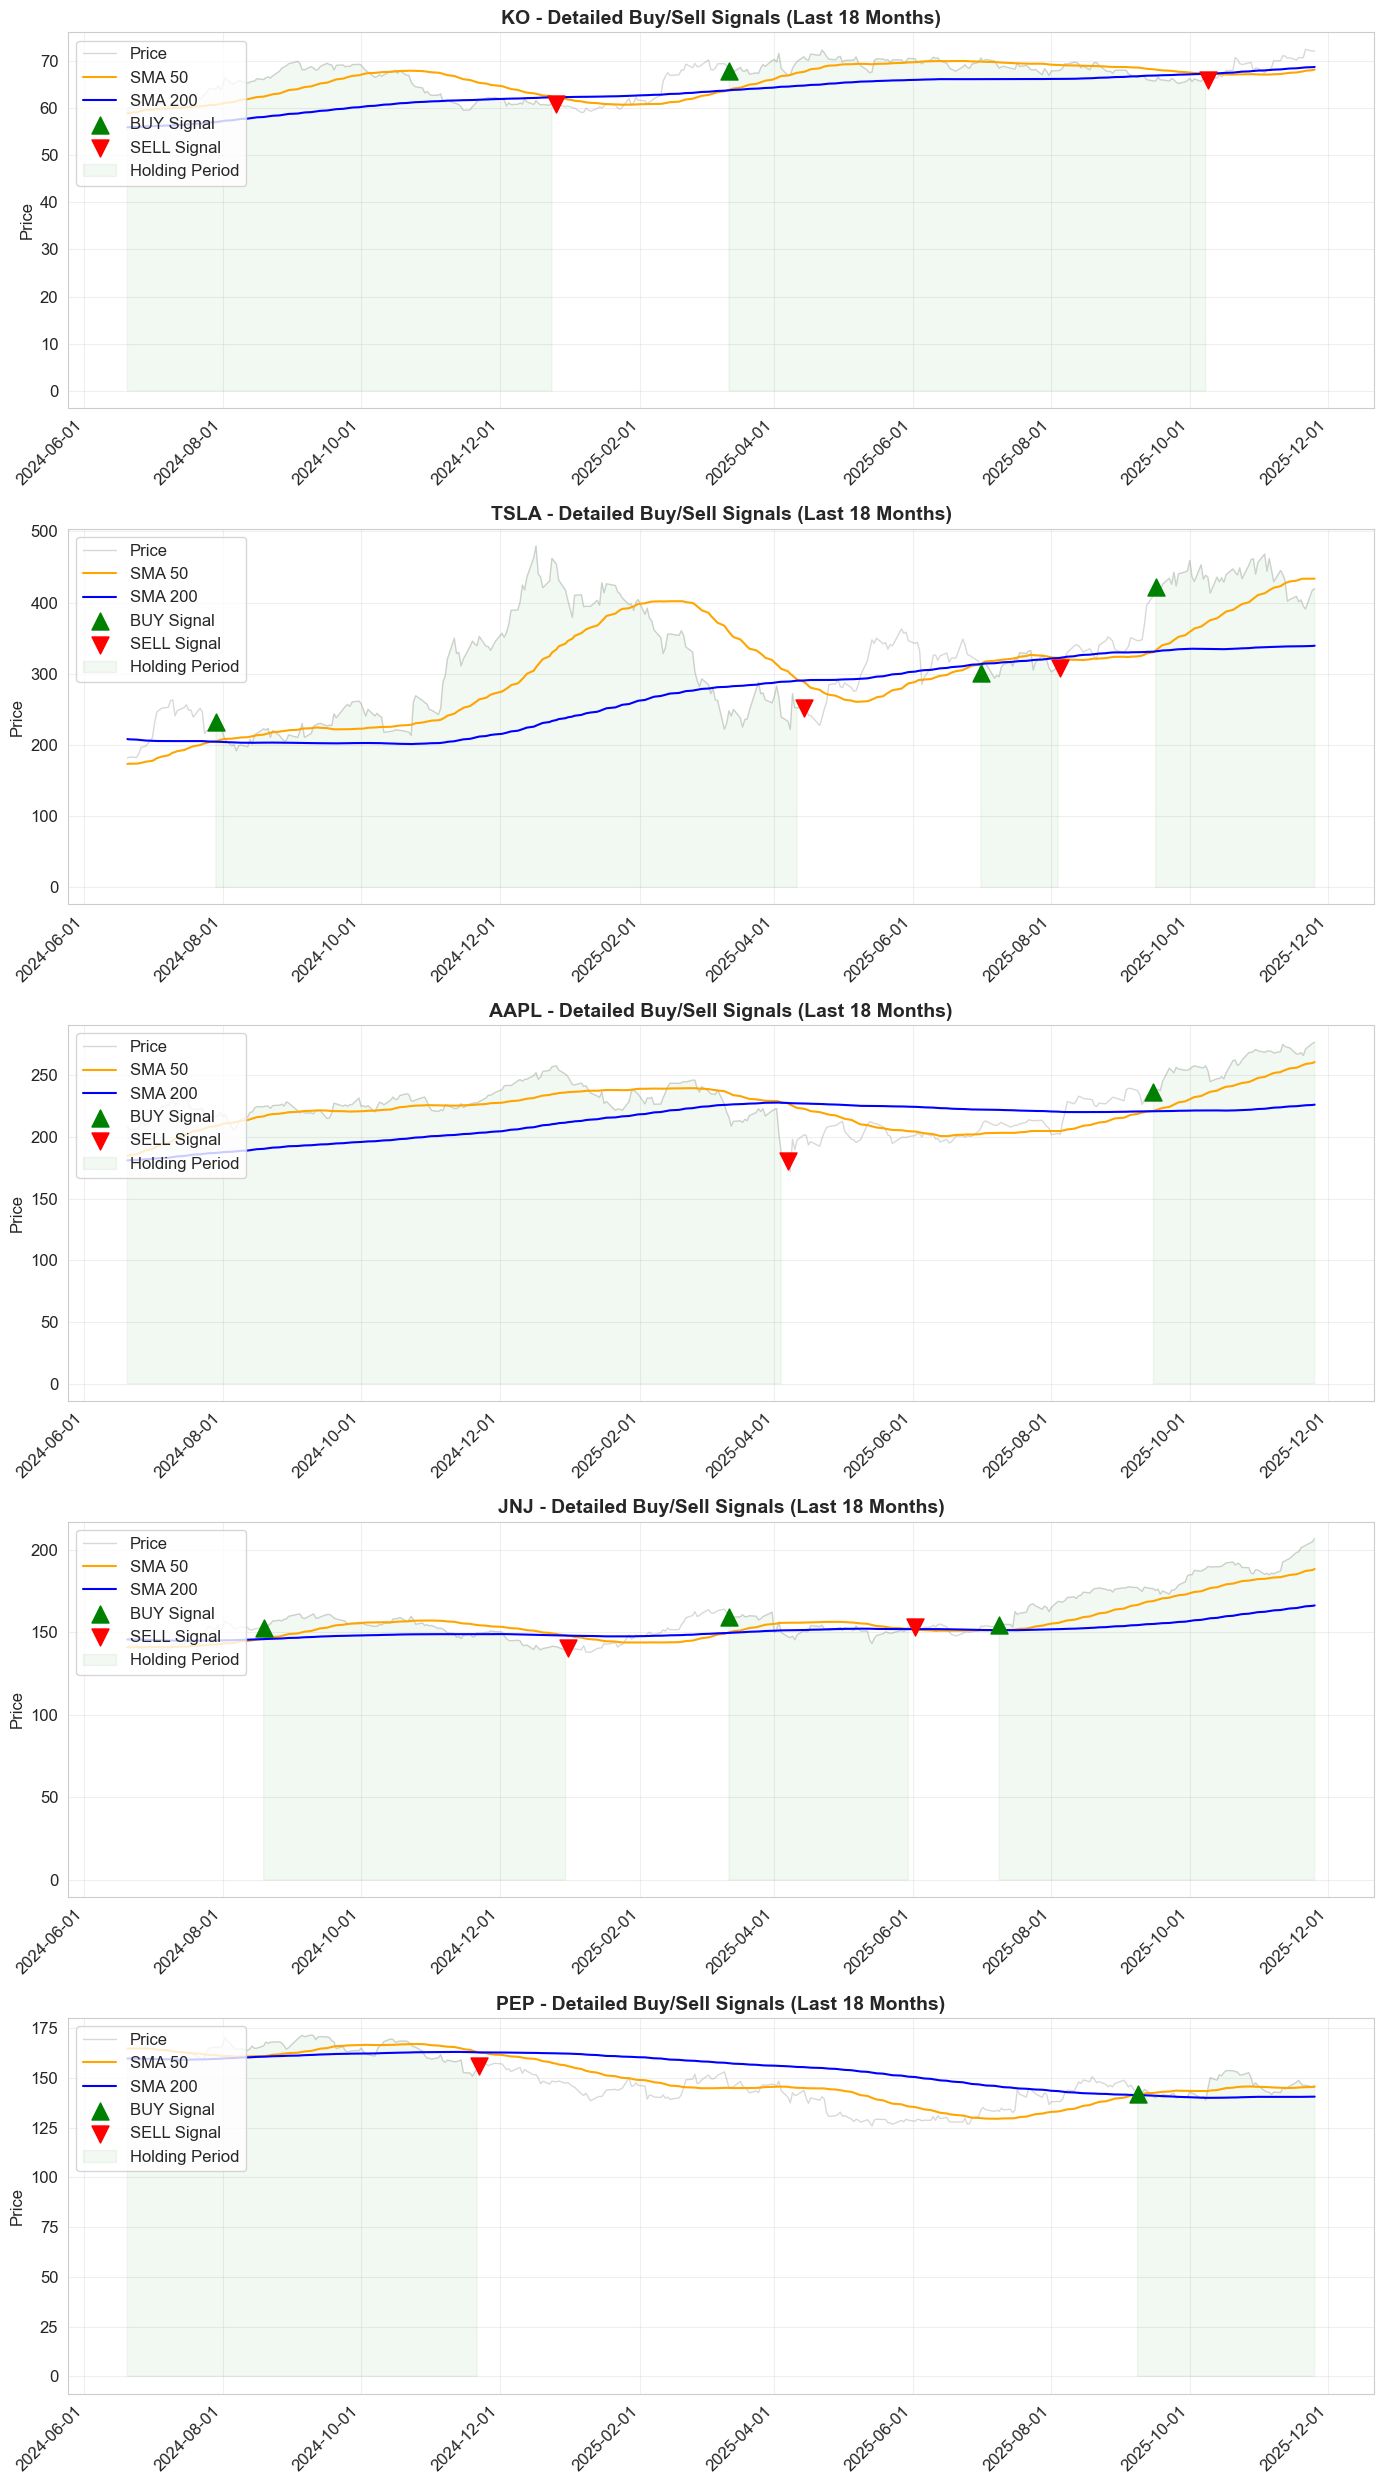


--- TRADING SIGNAL LOG (DETAILED BUY/SELL HISTORY) ---
Total Executed Trades: 17
--------------------------------------------------------------------------------
Ticker       Date      Action   Price SMA_Short SMA_Long
  TSLA 2024-07-30  BUY (Long) $222.62    206.11   204.48
   JNJ 2024-08-20  BUY (Long) $153.00    146.11   145.85
   PEP 2024-11-25 SELL (Cash) $156.98    162.45   162.81
    KO 2024-12-27 SELL (Cash)  $60.66     62.12    62.30
   JNJ 2025-01-02 SELL (Cash) $139.74    147.53   147.90
   JNJ 2025-03-13  BUY (Long) $159.41    150.23   149.67
    KO 2025-03-13  BUY (Long)  $67.62     64.00    63.81
  AAPL 2025-04-08 SELL (Cash) $171.83    226.23   227.51
  TSLA 2025-04-15 SELL (Cash) $254.11    286.16   290.88
   JNJ 2025-06-03 SELL (Cash) $152.33    151.66   151.91
  TSLA 2025-07-02  BUY (Long) $315.65    315.77   314.07
   JNJ 2025-07-10  BUY (Long) $155.55    151.32   151.22
  TSLA 2025-08-06 SELL (Cash) $319.91    321.46   322.98
   PEP 2025-09-09  BUY (Long) $143.10  

In [134]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("\n--- VISUALIZATION: DETAILED DAILY BUY/SELL SIGNALS (ZOOMED IN) ---")

# Thiết lập biểu đồ
fig, axes = plt.subplots(len(all_tickers), 1, figsize=(14, 25))

for i, ticker in enumerate(all_tickers):
    df = sma_datasets[ticker]
    ax = axes[i]
    
    # --- 1. TẠO TÍN HIỆU MUA/BÁN CỤ THỂ ---
    # Logic: 
    # Mua khi SMA1 cắt lên SMA2 (Diff dương)
    # Bán khi SMA1 cắt xuống SMA2 (Diff âm)
    df['Signal'] = 0
    # Điều kiện Mua: SMA1 hôm nay > SMA2 hôm nay VÀ SMA1 hôm qua < SMA2 hôm qua
    df.loc[(df['SMA1'] > df['SMA2']) & (df['SMA1'].shift(1) < df['SMA2'].shift(1)), 'Signal'] = 1
    # Điều kiện Bán: SMA1 hôm nay < SMA2 hôm nay VÀ SMA1 hôm qua > SMA2 hôm qua
    df.loc[(df['SMA1'] < df['SMA2']) & (df['SMA1'].shift(1) > df['SMA2'].shift(1)), 'Signal'] = -1
    
    # --- 2. ZOOM VÀO 1.5 NĂM GẦN NHẤT ---
    # Để nhìn rõ nến ngày
    plot_data = df.iloc[-375:] 
    
    # Vẽ đường Giá và SMA
    ax.plot(plot_data.index, plot_data['price'], label='Price', color='gray', alpha=0.3, linewidth=1)
    ax.plot(plot_data.index, plot_data['SMA1'], label=f'SMA {SMA_SHORT}', color='orange', linewidth=1.5)
    ax.plot(plot_data.index, plot_data['SMA2'], label=f'SMA {SMA_LONG}', color='blue', linewidth=1.5)
    
    # --- 3. VẼ MŨI TÊN MUA BÁN (MARKERS) ---
    # Lọc ra các ngày có tín hiệu
    buy_signals = plot_data[plot_data['Signal'] == 1]
    sell_signals = plot_data[plot_data['Signal'] == -1]
    
    # Vẽ Mũi tên Xanh (MUA)
    ax.scatter(buy_signals.index, buy_signals['price'], marker='^', color='green', s=150, label='BUY Signal', zorder=5)
    
    # Vẽ Mũi tên Đỏ (BÁN)
    ax.scatter(sell_signals.index, sell_signals['price'], marker='v', color='red', s=150, label='SELL Signal', zorder=5)
    
    # Tô màu vùng nắm giữ
    # Tạo lại cột Position để tô màu
    plot_data = plot_data.copy() # Tránh warning
    plot_data['Position'] = np.where(plot_data['SMA1'] > plot_data['SMA2'], 1, 0)
    ax.fill_between(plot_data.index, plot_data['price'], 0, 
                    where=(plot_data['Position'] == 1), 
                    color='green', alpha=0.05, label='Holding Period')

    # --- 4. ĐỊNH DẠNG TRỤC NGÀY (DATE FORMAT) ---
    # Hiển thị Năm-Tháng-Ngày (YYYY-MM-DD)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    # Mỗi tháng hiện 1 nhãn để đỡ rối, nhưng vẫn thấy rõ mốc thời gian
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    
    ax.set_title(f"{ticker} - Detailed Buy/Sell Signals (Last 18 Months)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Price")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Xoay chữ ngày tháng cho dễ đọc
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

import pandas as pd

print("\n--- TRADING SIGNAL LOG (DETAILED BUY/SELL HISTORY) ---")

# List to store trade records
trade_log = []

for ticker in all_tickers:
    # Retrieve the processed data from Step 2
    df = sma_datasets[ticker]
    
    # 1. Identify Position Changes (Trades)
    # diff() != 0 implies a change in state (e.g., from 0 to 1 or 1 to 0)
    # fillna(0) handles the first row
    trades = df['Position'].diff().fillna(0)
    
    # Filter only dates where a trade occurred
    trade_dates = trades[trades != 0].index
    
    for date in trade_dates:
        # Get data for that specific trade date
        signal = df.loc[date, 'Position']
        price = df.loc[date, 'price']
        
        # Determine Action:
        # If Signal is 1 -> We just bought (Long)
        # If Signal is 0 -> We just sold (Cash)
        # Note: The logic already includes shift(1), so 'date' is the execution date.
        action = "BUY (Long)" if signal == 1 else "SELL (Cash)"
        
        # Append to log
        trade_log.append({
            'Ticker': ticker,
            'Date': date.date(), # Keep only YYYY-MM-DD
            'Action': action,
            'Price': f"${price:.2f}",
            'SMA_Short': f"{df.loc[date, 'SMA1']:.2f}",
            'SMA_Long': f"{df.loc[date, 'SMA2']:.2f}"
        })

# 2. Convert to DataFrame and Print
if len(trade_log) > 0:
    trade_df = pd.DataFrame(trade_log)
    
    # Sort by Date to see the chronological timeline of the portfolio
    trade_df = trade_df.sort_values(by=['Date', 'Ticker'])
    
    print(f"Total Executed Trades: {len(trade_df)}")
    print("-" * 80)
    # Print the table without the index number for a cleaner look
    print(trade_df.to_string(index=False))
    print("-" * 80)
    
else:
    print("⚠️ No trades executed. The market might be in a continuous trend without crossovers.")

In [135]:
print("\n--- TRADING SIGNAL LOG (TEST SET ONLY: 2025 - NOW) ---")

# List lưu nhật ký
trade_log = []



for ticker in all_tickers:
    df = sma_datasets[ticker]
    
    # 1. Tìm điểm thay đổi vị thế
    trades = df['Position'].diff().fillna(0)
    
    # 2. Lấy các ngày có giao dịch
    trade_dates = trades[trades != 0].index
    
    for date in trade_dates:
        # --- CHỈ LẤY GIAO DỊCH THUỘC TẬP TEST ---
        if date < start_test_date:
            continue
            
        # Lấy thông tin
        signal = df.loc[date, 'Position']
        price = df.loc[date, 'price']
        
        action = "BUY (Long)" if signal == 1 else "SELL (Cash)"
        
        trade_log.append({
            'Ticker': ticker,
            'Date': date.date(),
            'Action': action,
            'Price': f"${price:.2f}",
            'SMA_Short': f"{df.loc[date, 'SMA1']:.2f}",
            'SMA_Long': f"{df.loc[date, 'SMA2']:.2f}"
        })

# 3. In kết quả
if len(trade_log) > 0:
    trade_df = pd.DataFrame(trade_log)
    trade_df = trade_df.sort_values(by=['Date', 'Ticker'])
    
    print(f"Transactions in Test Period ({start_test_date.date()} - Now): {len(trade_df)}")
    print("-" * 85)
    print(trade_df.to_string(index=False))
    print("-" * 85)
else:
    print(f"⚠️ No trades generated in the Test Set ({start_test_date.date()} - Now).")
    print("Strategy holds the previous position throughout this period.")




--- TRADING SIGNAL LOG (TEST SET ONLY: 2025 - NOW) ---
Transactions in Test Period (2024-12-31 - Now): 13
-------------------------------------------------------------------------------------
Ticker       Date      Action   Price SMA_Short SMA_Long
   JNJ 2025-01-02 SELL (Cash) $139.74    147.53   147.90
   JNJ 2025-03-13  BUY (Long) $159.41    150.23   149.67
    KO 2025-03-13  BUY (Long)  $67.62     64.00    63.81
  AAPL 2025-04-08 SELL (Cash) $171.83    226.23   227.51
  TSLA 2025-04-15 SELL (Cash) $254.11    286.16   290.88
   JNJ 2025-06-03 SELL (Cash) $152.33    151.66   151.91
  TSLA 2025-07-02  BUY (Long) $315.65    315.77   314.07
   JNJ 2025-07-10  BUY (Long) $155.55    151.32   151.22
  TSLA 2025-08-06 SELL (Cash) $319.91    321.46   322.98
   PEP 2025-09-09  BUY (Long) $143.10    141.71   141.36
  AAPL 2025-09-16  BUY (Long) $237.92    221.82   220.92
  TSLA 2025-09-17  BUY (Long) $425.86    335.53   331.94
    KO 2025-10-10 SELL (Cash)  $66.57     67.27    67.32
---------

#### 2. Vectorized Backtesting
- Technique Introduction: Instead of iterating through data row-by-row (event-based backtesting), we utilize Vectorized Backtesting. This involves operating on whole arrays (columns) of data simultaneously using numpy and pandas. We calculate strategy returns by multiplying the Position column (shifted by one day to avoid look-ahead bias) by the market Returns column.
- Reason for Selection: Vectorization is computationally efficient and concise. It allows us to backtest years of data in milliseconds, making it efficient for optimizing parameters


--- VECTORIZED BACKTESTING (CALCULATING RETURNS) ---
✅ Backtest finished for KO.
✅ Backtest finished for TSLA.
✅ Backtest finished for AAPL.
✅ Backtest finished for JNJ.
✅ Backtest finished for PEP.

--- PERFORMANCE VISUALIZATION ---


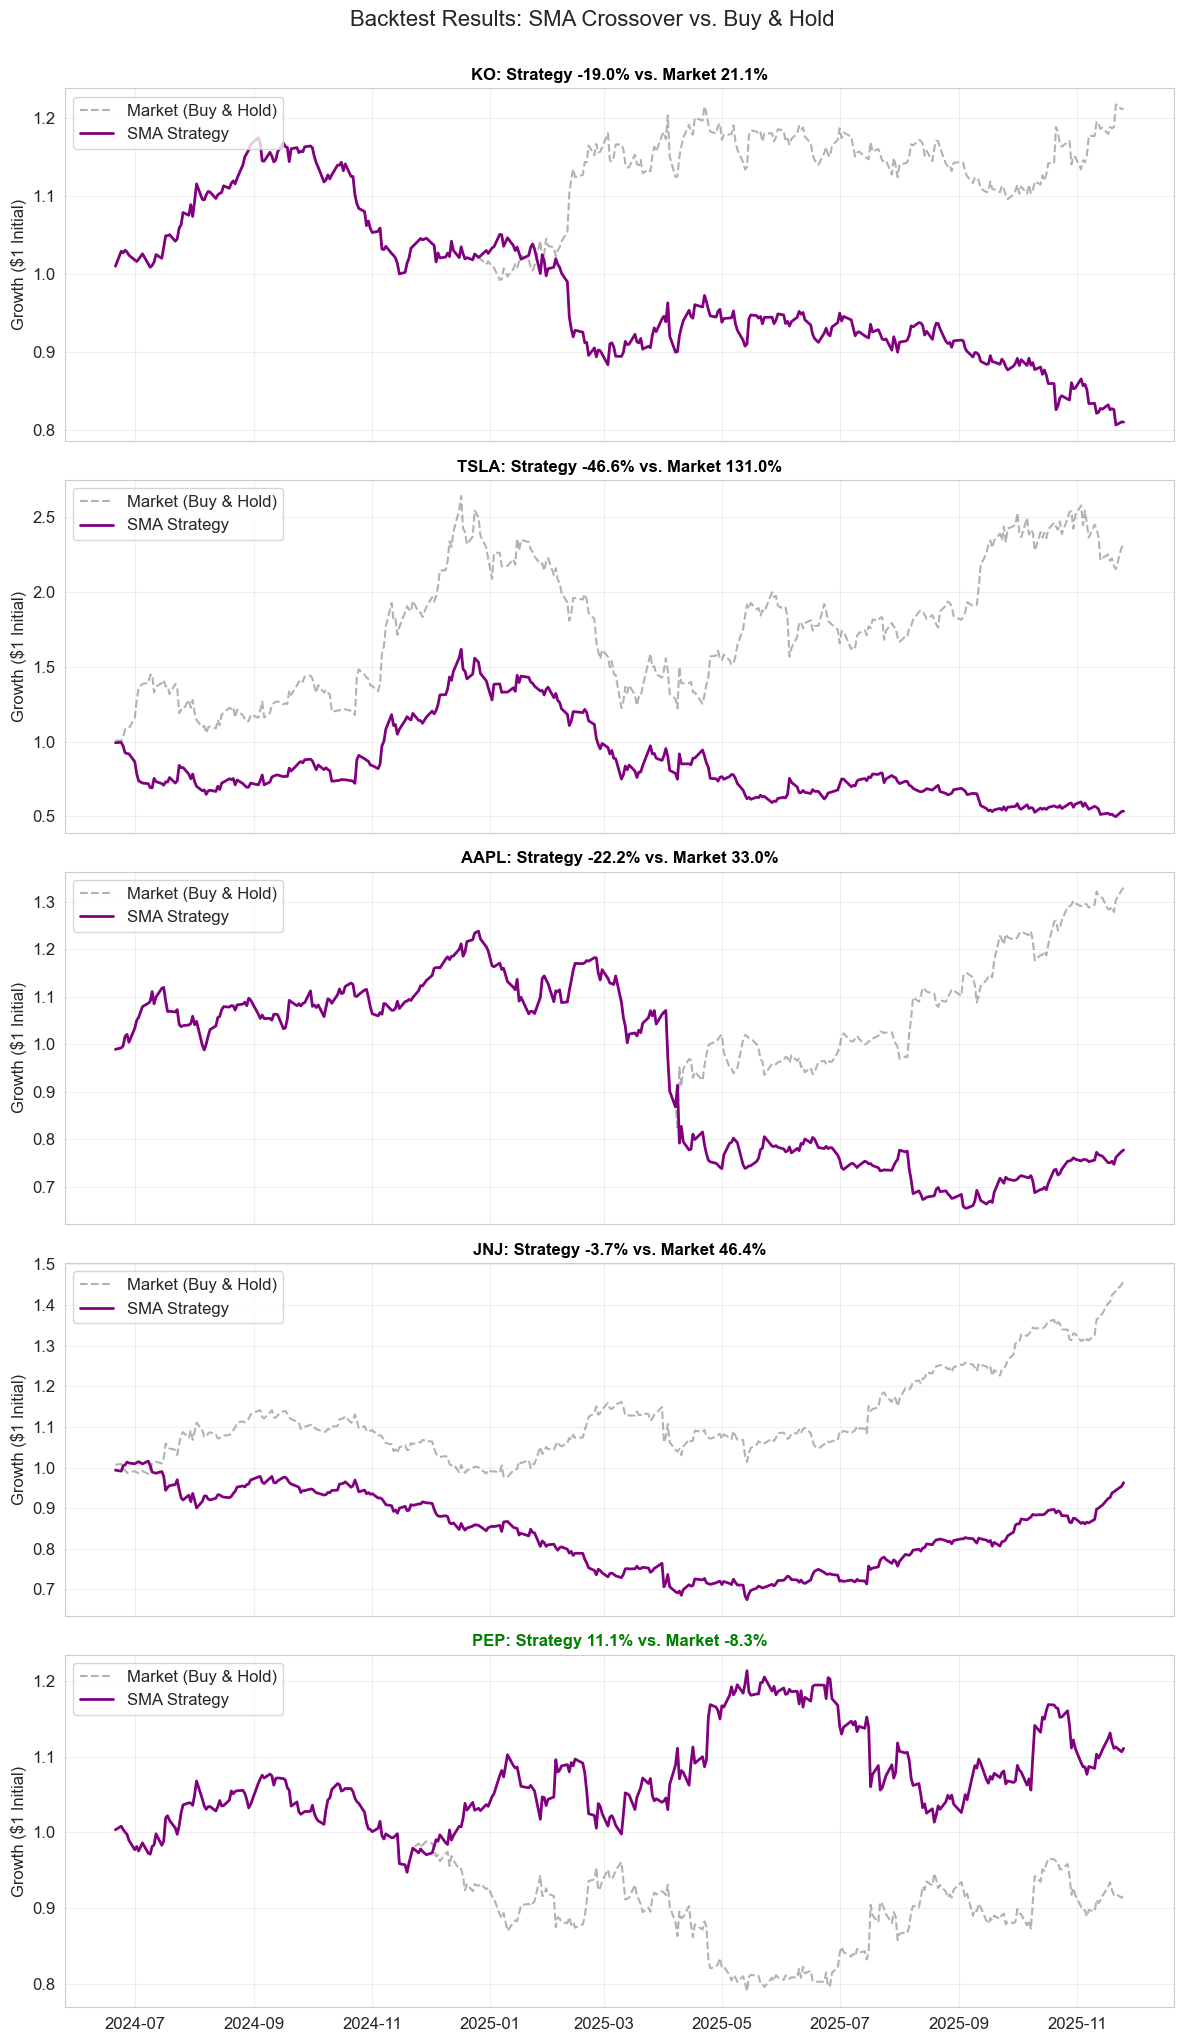


--- FINAL PERFORMANCE SUMMARY ---
       Market Strategy Outperformance
KO     21.11%  -19.01%        -40.12%
TSLA  130.99%  -46.63%       -177.61%
AAPL   32.99%  -22.22%        -55.21%
JNJ    46.39%   -3.71%        -50.10%
PEP    -8.26%   11.13%         19.39%


In [141]:
print("\n--- VECTORIZED BACKTESTING (CALCULATING RETURNS) ---")

# Dictionary to store final performance metrics for comparison
performance_metrics = {}

# Iterate through all tickers
for ticker in all_tickers:
    df = sma_datasets[ticker]
    
    # 1. Calculate Market Returns (Logarithmic)
    # Formula: ln(Price_t / Price_t-1)
    # We use log returns because they are additive over time (easier for cumulative calc)
    df['Returns'] = np.log(df['price'] / df['price'].shift(1))
    
    # 2. Determine Raw Signal (Before Shift)
    # 1 = Buy (Long), -1 = Sell (Short)
    # We recalculate this to ensure we are shifting the *Signal*, not the *Position* twice.
    df['Raw_Signal'] = np.where(df['SMA1'] > df['SMA2'], 1, -1)
    
    # 3. Calculate Strategy Returns (THE CORE LOGIC)
    # Strategy Return = Yesterday's Signal * Today's Market Return
    # .shift(1) is MANDATORY to avoid look-ahead bias.
    df['Strategy'] = df['Raw_Signal'].shift(1) * df['Returns']
    
    # 4. Drop NaNs (First row will be NaN due to shift and returns calc)
    df.dropna(inplace=True)
    
    # 5. Calculate Cumulative Returns (For Visualization)
    # Convert Log Returns back to normal Price Growth: exp(cumsum)
    # This allows us to see "If I invested $1, how much is it worth now?"
    df['Cum_Market'] = np.exp(df['Returns'].cumsum())
    df['Cum_Strategy'] = np.exp(df['Strategy'].cumsum())
    
    # Save back to dictionary
    sma_datasets[ticker] = df
    
    # Calculate Final Total Return for this ticker
    market_perf = df['Cum_Market'].iloc[-1] - 1
    strategy_perf = df['Cum_Strategy'].iloc[-1] - 1
    
    performance_metrics[ticker] = {
        'Market': market_perf,
        'Strategy': strategy_perf
    }
    
    print(f"✅ Backtest finished for {ticker}.")

# =========================================================
# VISUALIZATION: EQUITY CURVES (STRATEGY vs. MARKET)
# =========================================================
print("\n--- PERFORMANCE VISUALIZATION ---")

fig, axes = plt.subplots(len(all_tickers), 1, figsize=(12, 20), sharex=True)

for i, ticker in enumerate(all_tickers):
    df = sma_datasets[ticker]
    ax = axes[i]
    
    # Plot Cumulative Growth
    ax.plot(df.index, df['Cum_Market'], label='Market (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
    ax.plot(df.index, df['Cum_Strategy'], label='SMA Strategy', color='purple', linewidth=2)
    
    # Check who won
    m_ret = performance_metrics[ticker]['Market']
    s_ret = performance_metrics[ticker]['Strategy']
    
    # Green title if Strategy wins, Black if it loses
    title_color = 'green' if s_ret > m_ret else 'black'
    
    ax.set_title(f"{ticker}: Strategy {s_ret:.1%} vs. Market {m_ret:.1%}", 
                 fontsize=12, fontweight='bold', color=title_color)
    ax.set_ylabel("Growth ($1 Initial)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Backtest Results: SMA Crossover vs. Buy & Hold', fontsize=16, y=1.02)
plt.show()

# --- SUMMARY TABLE ---
print("\n--- FINAL PERFORMANCE SUMMARY ---")
perf_df = pd.DataFrame(performance_metrics).T
perf_df['Outperformance'] = perf_df['Strategy'] - perf_df['Market']
# Format as percentage
print(perf_df.applymap(lambda x: f"{x:.2%}"))

#### 3. Numerical Results

In [147]:
print("\n--- PART 3.1 (STEP 4): NUMERICAL RESULTS (BUY & HOLD vs. SMA STRATEGY) ---")

# Initialize a DataFrame to store the comparison results
summary_table = pd.DataFrame(index=all_tickers, 
                             columns=['Market Perf (Buy&Hold)', 'Strategy Perf (SMA)', 
                                      'Market Volatility', 'Strategy Volatility', 
                                      'Winner'])

# Loop through all 5 tickers
for ticker in all_tickers:
    # Get the processed data
    df = sma_datasets[ticker]
    
    # 1. Calculate Gross Performance (Total Growth Factor)
    # Formula: exp(sum of log returns)
    # Example: 4.01 means your money grew 4.01 times (Initial $1 -> $4.01)
    gross_perf = np.exp(df[['Returns', 'Strategy']].sum())
    
    # 2. Calculate Annualized Volatility (Risk)
    # Formula: standard deviation * sqrt(252 trading days)
    ann_vol = df[['Returns', 'Strategy']].std() * np.sqrt(252)
    
    # 3. Store results in the summary table
    summary_table.loc[ticker, 'Market Perf (Buy&Hold)'] = gross_perf['Returns']
    summary_table.loc[ticker, 'Strategy Perf (SMA)']    = gross_perf['Strategy']
    summary_table.loc[ticker, 'Market Volatility']      = ann_vol['Returns']
    summary_table.loc[ticker, 'Strategy Volatility']    = ann_vol['Strategy']
    
    # 4. Determine the Winner
    if gross_perf['Strategy'] > gross_perf['Returns']:
        summary_table.loc[ticker, 'Winner'] = "✅ SMA Strategy"
    else:
        summary_table.loc[ticker, 'Winner'] = "❌ Market (Buy&Hold)"

# --- PRINT THE FINAL TABLE ---
print("\n📊 FINAL COMPARISON TABLE:")

# Formatting for better readability
# Performance is displayed as a factor (e.g., 4.50x)
# Volatility is displayed as a percentage (e.g., 25.00%)
pd.set_option('display.max_columns', None)
print(summary_table.style.format({
    'Market Perf (Buy&Hold)': '{:.2f}x',
    'Strategy Perf (SMA)': '{:.2f}x',
    'Market Volatility': '{:.2%}',
    'Strategy Volatility': '{:.2%}'
}).to_string())

# --- OBSERVATION NOTES ---
print("\n📝 HOW TO INTERPRET:")
print("1. Performance: If 'Strategy Perf' > 'Market Perf', the SMA model beat the market.")
print("2. Volatility: Lower is better. SMA strategy usually has lower volatility because it holds cash during downtrends.")


--- PART 3.1 (STEP 4): NUMERICAL RESULTS (BUY & HOLD vs. SMA STRATEGY) ---

📊 FINAL COMPARISON TABLE:
 Market Perf (Buy&Hold) Strategy Perf (SMA) Market Volatility Strategy Volatility Winner
KO 1.21x 0.81x 16.56% 16.56% ❌ Market (Buy&Hold)
TSLA 2.31x 0.53x 67.00% 67.05% ❌ Market (Buy&Hold)
AAPL 1.33x 0.78x 29.48% 29.48% ❌ Market (Buy&Hold)
JNJ 1.46x 0.96x 18.30% 18.37% ❌ Market (Buy&Hold)
PEP 0.92x 1.11x 20.67% 20.66% ✅ SMA Strategy


📝 HOW TO INTERPRET:
1. Performance: If 'Strategy Perf' > 'Market Perf', the SMA model beat the market.
2. Volatility: Lower is better. SMA strategy usually has lower volatility because it holds cash during downtrends.


#### 4. Optimization & Simulation

In [145]:
import numpy as np
import pandas as pd
import itertools

print("\n--- PART 3.1: SMA PARAMETER OPTIMIZATION (BRUTE FORCE) ---")

# 1. SPLIT dữ liệu theo 504 dòng đầu (Train / Test)
train_data = full_data.iloc[:TRAIN_SIZE]
test_data  = full_data.iloc[TRAIN_SIZE:]

print(f"Training Data Period: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Test Data Period: {test_data.index[0]} to {test_data.index[-1]}")

# 2. Định nghĩa khoảng tham số cần dò tìm
sma1_range = range(20, 62, 2)     # SMA ngắn
sma2_range = range(180, 285, 5)   # SMA dài

# Dictionary lưu kết quả tối ưu
best_sma_params = {}

# 3. Hàm Backtest nhanh (Vectorized)
def test_sma_strategy(data, sma1, sma2):
    """Trả về tổng log return của chiến lược SMA."""
    
    short_ma = data.rolling(sma1).mean()
    long_ma  = data.rolling(sma2).mean()

    # Tín hiệu giao dịch
    signal = np.where(short_ma > long_ma, 1, 0)
    signal = pd.Series(signal, index=data.index).shift(1)  # tránh look-ahead

    log_returns = np.log(data / data.shift(1))
    strategy_returns = signal * log_returns

    return strategy_returns.sum()

# 4. Brute-force tối ưu SMA
print(f"\nOptimizing... (This might take a moment)\n")

for ticker in all_tickers:
    
    # Lấy dữ liệu train của từng cổ phiếu
    price_data = train_data[ticker].dropna()

    best_perf = -np.inf
    best_pair = (42, 252)  # Mặc định
    
    for s1, s2 in itertools.product(sma1_range, sma2_range):
        if s1 >= s2:
            continue
        
        perf = test_sma_strategy(price_data, s1, s2)
        
        if perf > best_perf:
            best_perf = perf
            best_pair = (s1, s2)

    best_sma_params[ticker] = best_pair

    # Chuyển log return sang %
    total_return_pct = np.exp(best_perf) - 1

    print(f"✅ {ticker:<5} | Best SMA: {best_pair} | Train Return: {total_return_pct:.2%}")

print("\n--- OPTIMIZATION RESULTS ---")
print("Các cặp tham số tối ưu này sẽ được dùng cho phần test và so sánh với AI.")
print(best_sma_params)



--- PART 3.1: SMA PARAMETER OPTIMIZATION (BRUTE FORCE) ---
Training Data Period: 2023-09-01 00:00:00 to 2025-09-05 00:00:00
Test Data Period: 2025-09-08 00:00:00 to 2025-11-25 00:00:00

Optimizing... (This might take a moment)

✅ KO    | Best SMA: (40, 185) | Train Return: 3.31%
✅ TSLA  | Best SMA: (60, 255) | Train Return: 86.18%
✅ AAPL  | Best SMA: (24, 185) | Train Return: 23.51%
✅ JNJ   | Best SMA: (24, 190) | Train Return: 9.23%
✅ PEP   | Best SMA: (56, 210) | Train Return: 1.29%

--- OPTIMIZATION RESULTS ---
Các cặp tham số tối ưu này sẽ được dùng cho phần test và so sánh với AI.
{'KO': (40, 185), 'TSLA': (60, 255), 'AAPL': (24, 185), 'JNJ': (24, 190), 'PEP': (56, 210)}



--- FINAL PERFORMANCE COMPARISON: MPT (STATIC) STRATEGIES ---
✅ Optimized Weights (Max Sharpe, Min Vol) retrieved.


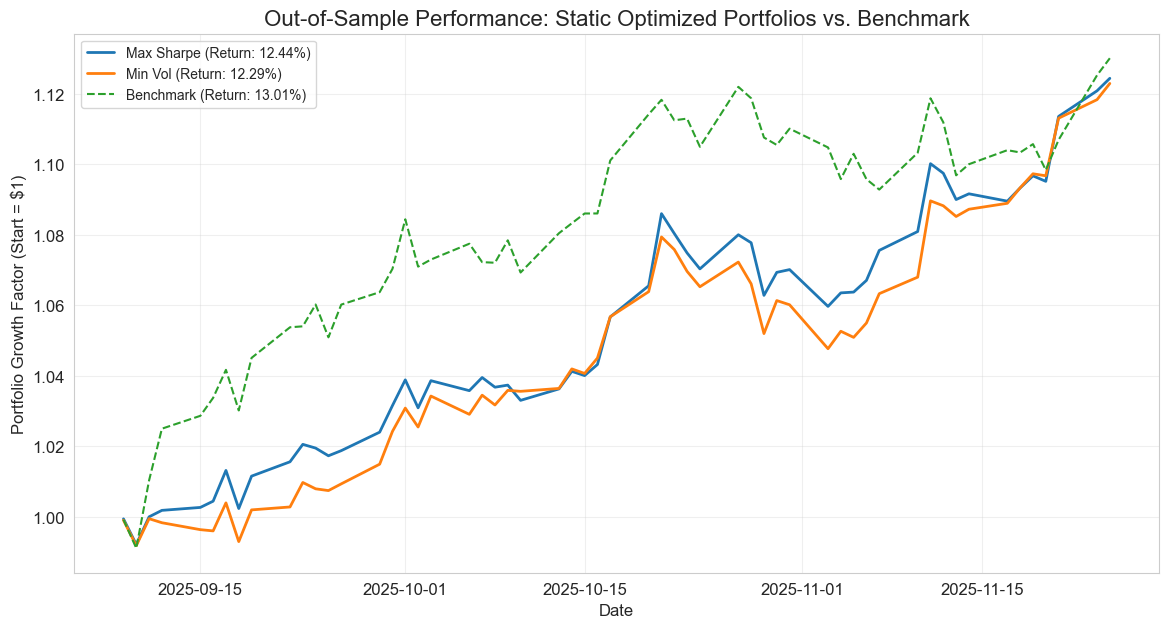


--- FINAL PERFORMANCE SUMMARY (STATIC ALLOCATION) ---
Max Sharpe    12.44%
Min Vol       12.29%
Benchmark     13.01%
Name: 2025-11-25 00:00:00, dtype: object


In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n--- FINAL PERFORMANCE COMPARISON: MPT (STATIC) STRATEGIES ---")

# =========================================================
# 1. SETUP & WEIGHT RETRIEVAL (Lấy trọng số tối ưu từ Part 2)
# =========================================================

# Tính Log Returns trên tập Test
test_returns = np.log(test_data / test_data.shift(1)).dropna()

# 1.1. Safety Check for Weights
w_fallback = pd.Series(1 / len(all_tickers), index=all_tickers)

try:
    # Max Sharpe Weights
    w_sharpe = w_n_sharpe.reindex(test_returns.columns).fillna(0)
    w_sharpe = w_sharpe / w_sharpe.sum()
    
    # Min Volatility Weights
    w_minvol = w_n_minvol.reindex(test_returns.columns).fillna(0)
    w_minvol = w_minvol / w_minvol.sum()
    
    print("✅ Optimized Weights (Max Sharpe, Min Vol) retrieved.")
except NameError:
    w_sharpe = w_fallback
    w_minvol = w_fallback
    print("⚠️ Optimized weights not found. Using Equal Weights for MPT strategies.")

# 1.2. Benchmark Weights (Equal Weight)
w_benchmark = pd.Series(1 / len(all_tickers), index=all_tickers)

# =========================================================
# 2. CALCULATE PORTFOLIO DAILY RETURNS (Vectorized)
# =========================================================

portfolio_returns = pd.DataFrame(index=test_returns.index)

# A. Strategy 1: Max Sharpe (Aggressive Growth)
# Vectorized calculation: Dot product of daily returns and weights
portfolio_returns['Max Sharpe'] = test_returns.dot(w_sharpe)

# B. Strategy 2: Min Volatility (Defensive)
portfolio_returns['Min Vol'] = test_returns.dot(w_minvol)

# C. Benchmark: Equal Weight (Naive Market Average)
portfolio_returns['Benchmark'] = test_returns.dot(w_benchmark)


# =========================================================
# 3. CALCULATE CUMULATIVE GROWTH & PLOT
# =========================================================

# Convert Log Returns to Growth Factor: exp(cumsum(returns))
cumulative_growth = np.exp(portfolio_returns.cumsum())

# Final Metrics for plot label
final_metrics = cumulative_growth.iloc[-1].apply(lambda x: (x - 1))

plt.figure(figsize=(14, 7))

# Plot all three strategies
for col in cumulative_growth.columns:
    plt.plot(cumulative_growth.index, cumulative_growth[col], 
             label=f"{col} (Return: {final_metrics[col]:.2%})", 
             linewidth=2 if 'Benchmark' not in col else 1.5,
             linestyle='--' if 'Benchmark' in col else '-')

plt.title('Out-of-Sample Performance: Static Optimized Portfolios vs. Benchmark', fontsize=16)
plt.ylabel('Portfolio Growth Factor (Start = $1)')
plt.xlabel('Date')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- FINAL PERFORMANCE SUMMARY (STATIC ALLOCATION) ---")
print(final_metrics.apply(lambda x: f"{x:.2%}"))

In [151]:
import pandas as pd
import numpy as np

print("\n--- FINAL CORRECTED PnL ANALYSIS (RECALCULATING FRESH SIGNALS) ---")

# ==============================================================================
# 1. SETUP
# ==============================================================================
INITIAL_CAPITAL = 100000
ALLOCATION_PER_STOCK = INITIAL_CAPITAL / len(all_tickers)
TEST_START = pd.Timestamp(split_date)

print(f"Test Period: {TEST_START.date()} - NOW")
print(f"Capital per Stock: ${ALLOCATION_PER_STOCK:,.2f}")
print("-" * 80)

detailed_transaction_log = []
portfolio_summary = []

# ==============================================================================
# 2. MAIN LOOP (TÍNH LẠI TỪ GỐC)
# ==============================================================================
for ticker in all_tickers:
    # --- BƯỚC 1: TÍNH LẠI SMA & POSITION TỪ FULL DATA ---
    # (Để đảm bảo dữ liệu không bị lỗi do các bước trước)
    df = full_data[ticker].to_frame(name='price')
    df['SMA50'] = df['price'].rolling(50).mean()
    df['SMA200'] = df['price'].rolling(200).mean()
    
    # Logic: 1 (Long), 0 (Cash) - Dùng 0 để an toàn và đúng Baseline
    df['Position'] = np.where(df['SMA50'] > df['SMA200'], 1, 0)
    # Shift 1 ngày (Bắt buộc)
    df['Position'] = df['Position'].shift(1)
    
    # --- BƯỚC 2: CẮT DỮ LIỆU TEST ---
    df_test = df.loc[TEST_START:].copy()
    
    # --- BƯỚC 3: XỬ LÝ GIAO DỊCH ---
    # Tính sự thay đổi: 1 (Mua), -1 (Bán)
    df_test['Trade'] = df_test['Position'].diff().fillna(0)
    
    # FORCE ENTRY: Nếu ngày đầu tiên của năm 2025 đang giữ (Position=1)
    # Coi như Mua lại để bắt đầu tính lãi cho năm nay
    if df_test['Position'].iloc[0] == 1:
        df_test.iloc[0, df_test.columns.get_loc('Trade')] = 1
    
    # Biến theo dõi
    shares_held = 0
    entry_price = 0
    realized_pnl = 0
    
    # Duyệt qua từng ngày trong năm 2025
    for date, row in df_test.iterrows():
        price = row['price']
        action = row['Trade']
        
        # --- GHI NHẬT KÝ LỆNH MUA ---
        if action == 1:
            shares_held = int(ALLOCATION_PER_STOCK / price)
            entry_price = price
            
            detailed_transaction_log.append({
                'Date': date.date(),
                'Ticker': ticker,
                'Action': 'BUY',
                'Price': price,
                'Shares': shares_held,
                'PnL ($)': 0.0,
                'Status': 'OPEN'
            })
            
        # --- GHI NHẬT KÝ LỆNH BÁN ---
        elif action == -1 and shares_held > 0:
            pnl = (price - entry_price) * shares_held
            realized_pnl += pnl
            
            # Cập nhật trạng thái lệnh Mua trước đó thành CLOSED
            for item in reversed(detailed_transaction_log):
                if item['Ticker'] == ticker and item['Status'] == 'OPEN':
                    item['Status'] = 'CLOSED'
                    break
            
            # Ghi dòng Bán mới
            detailed_transaction_log.append({
                'Date': date.date(),
                'Ticker': ticker,
                'Action': 'SELL',
                'Price': price,
                'Shares': -shares_held,
                'PnL ($)': pnl, # Ghi nhận lãi tại đây
                'Status': 'CLOSED'
            })
            
            shares_held = 0 # Reset

    # --- BƯỚC 4: TÍNH LÃI CHƯA CHỐT (NẾU CUỐI NĂM VẪN GIỮ) ---
    unrealized_pnl = 0
    if shares_held > 0:
        last_price = df_test.iloc[-1]['price']
        unrealized_pnl = (last_price - entry_price) * shares_held
        
        # Update log
        for item in reversed(detailed_transaction_log):
            if item['Ticker'] == ticker and item['Status'] == 'OPEN':
                item['PnL ($)'] = unrealized_pnl # Cập nhật lãi ảo
                break
    
    portfolio_summary.append({
        'Ticker': ticker,
        'Realized': realized_pnl,
        'Unrealized': unrealized_pnl,
        'Total PnL': realized_pnl + unrealized_pnl
    })

# ==============================================================================
# IN KẾT QUẢ
# ==============================================================================
if len(detailed_transaction_log) > 0:
    log_df = pd.DataFrame(detailed_transaction_log)
    
    # Sắp xếp
    log_df = log_df.sort_values(by=['Date', 'Ticker'])
    
    # Format hiển thị
    pd.set_option('display.max_rows', 100)
    print(f"\n📊 TRANSACTION HISTORY ({len(log_df)} trades):")
    print(log_df[['Date', 'Ticker', 'Action', 'Price', 'Shares', 'PnL ($)']].to_string(index=False))
else:
    print("⚠️ No trades found.")

# Tổng kết tiền
sum_df = pd.DataFrame(portfolio_summary)
total_profit = sum_df['Total PnL'].sum()
roi = total_profit / INITIAL_CAPITAL

print("\n" + "="*40)
print(f"🚀 FINAL RESULT (2025)")
print(f"   - Initial Capital: ${INITIAL_CAPITAL:,.2f}")
print(f"   - Net Profit:      ${total_profit:,.2f}")
print(f"   - Total ROI:       {roi:.2%}")
print("="*40)


--- FINAL CORRECTED PnL ANALYSIS (RECALCULATING FRESH SIGNALS) ---
Test Period: 1970-01-01 - NOW
Capital per Stock: $20,000.00
--------------------------------------------------------------------------------

📊 TRANSACTION HISTORY (20 trades):
      Date Ticker Action    Price  Shares    PnL ($)
2024-06-20   AAPL    BUY 208.2655      96     0.0000
2024-06-20     KO    BUY  59.5353     335     0.0000
2024-06-20    PEP    BUY 159.2636     125     0.0000
2024-07-30   TSLA    BUY 222.6200      89     0.0000
2024-08-20    JNJ    BUY 153.0047     130     0.0000
2024-11-25    PEP   SELL 156.9815    -125  -285.2650
2024-12-27     KO   SELL  60.6603    -335   376.8942
2025-01-02    JNJ   SELL 139.7424    -130 -1724.0988
2025-03-13    JNJ    BUY 159.4149     125     0.0000
2025-03-13     KO    BUY  67.6248     295     0.0000
2025-04-08   AAPL   SELL 171.8324     -96 -3497.5737
2025-04-15   TSLA   SELL 254.1100     -89  2802.6105
2025-06-03    JNJ   SELL 152.3276    -125  -885.9043
2025-07-02   

### B. Advanced Strategy

#### I. Data Preparation & Feature Engineering
- Technique Introduction: We treat the trading problem as a Classification Task. We transform the financial time series into supervised learning data by creating features based on lagged log returns (e.g., lags 1 to 5). To assist the algorithms, we may digitize these features into binary classes (up/down) or discrete bins,.

- Reason for Selection: Machine Learning algorithms generally require stationary data (like log returns) rather than non-stationary price data. Creating lagged features allows the model to learn temporal patterns and autoregressive relationships in the market

In [167]:
print("\n--- DATA PREPARATION & DIGITIZATION (TEXTBOOK STANDARD) ---")

# CẤU HÌNH
LAGS = 5
N_BINS = 12
ml_datasets = {} 
feature_cols = [] 

def prepare_data_textbook_style(ticker, raw_data, lags=5, bins=12):
    # 1. Lấy dữ liệu giá
    if isinstance(raw_data, pd.DataFrame):
        df = raw_data[[ticker]].copy().rename(columns={ticker: 'price'})
    else:
        df = raw_data.copy().to_frame(name='price')

    # 2. TÍNH LOG RETURNS
    df['returns'] = np.log(df['price'] / df['price'].shift(1))
    
    # [FIX QUAN TRỌNG] Xóa dòng NaN đầu tiên ngay lập tức
    # Để tránh lỗi khi chuyển sang int ở bước sau
    df.dropna(inplace=True)
    
    # 3. TẠO NHÃN (LABELS) - MỤC TIÊU DỰ ĐOÁN (y)
    # direction = sign(returns) -> +1 (Tăng), -1 (Giảm), 0 (Tham chiếu)
    # astype(int) giờ sẽ chạy mượt mà vì không còn NaN
    df['direction'] = np.sign(df['returns']).astype(int)
    
    # 4. SỐ HÓA DỮ LIỆU (DIGITIZATION)
    mu = df['returns'].mean()
    std = df['returns'].std()
    
    # Tạo bins dựa trên Mean +/- 3 Std Dev (Theo sách)
    bin_edges = np.linspace(mu - 3*std, mu + 3*std, bins)
    
    # Số hóa cột returns thành các số nguyên (0, 1, 2...)
    df['digitized'] = np.digitize(df['returns'], bin_edges)
    
    # 5. TẠO LAGS (FEATURES X)
    cols = []
    for lag in range(1, lags + 1):
        col = f'lag_{lag}'
        # Feature của ngày t là giá trị digitized của ngày t-lag
        df[col] = df['digitized'].shift(lag)
        cols.append(col)
    
    # 6. LÀM SẠCH LẦN 2 (Xóa NaN do tạo Lags)
    df.dropna(inplace=True)
    
    # Chuyển features sang int
    df[cols] = df[cols].astype(int)
    
    return df, cols

# --- VÒNG LẶP XỬ LÝ (ALL TICKERS) ---
print(f"Processing data for {len(all_tickers)} tickers...")

for ticker in all_tickers:
    try:
        data, cols = prepare_data_textbook_style(ticker, full_data, lags=LAGS, bins=N_BINS)
        ml_datasets[ticker] = data
        feature_cols = cols
        print(f"✅ Processed {ticker}: {len(data)} rows.")
    except Exception as e:
        print(f"❌ Error processing {ticker}: {e}")

# --- KIỂM TRA DỮ LIỆU ---
if len(ml_datasets) > 0:
    sample = ml_datasets[all_tickers[0]]
    print(f"\n--- Data Verification ({all_tickers[0]}) ---")
    print(sample[['price', 'returns', 'direction', 'digitized', 'lag_1']].tail())
    print(f"\nFeatures (X): {feature_cols}")
    print("Label (y): 'direction'")


--- DATA PREPARATION & DIGITIZATION (TEXTBOOK STANDARD) ---
Processing data for 5 tickers...
✅ Processed KO: 555 rows.
✅ Processed TSLA: 555 rows.
✅ Processed AAPL: 555 rows.
✅ Processed JNJ: 555 rows.
✅ Processed PEP: 555 rows.

--- Data Verification (KO) ---
Ticker       price  returns  direction  digitized  lag_1
Date                                                    
2025-11-19 70.6140  -0.0015         -1          6      7
2025-11-20 70.7133   0.0014          1          6      6
2025-11-21 72.4412   0.0241          1         10      6
2025-11-24 72.0837  -0.0049         -1          5     10
2025-11-25 72.1036   0.0003          1          6      5

Features (X): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']
Label (y): 'direction'


#### II. Model Training


##### a. Model 1: Logistic Regression (Baseline)
- Technique: sklearn.linear_model.LogisticRegression. This models the probability of a market move (up/down) as a linear combination of the input features.

- Reason for Selection: It is a fast, scalable algorithm that serves as a linear baseline for classification. If non-linear models (like DNN) cannot beat Logistic Regression, the underlying data relationship is likely linear or random

In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n--- MODEL: LOGISTIC REGRESSION ---")

lr_models = {}
trade_stats = {}

for ticker in all_tickers:

    df = ml_datasets[ticker].dropna()

    # ✅ SPLIT THEO 504 DÒNG
    train = df.iloc[:TRAIN_SIZE]
    test  = df.iloc[TRAIN_SIZE:]

    print(f"{ticker} | Train rows: {len(train)} | Test rows: {len(test)}")

    X_train = train[feature_cols]
    y_train = train['direction']
    X_test  = test[feature_cols]
    y_test  = test['direction']

    model = LogisticRegression(C=1, solver='lbfgs', random_state=42, max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    acc_train = accuracy_score(y_train, pred_train)
    acc_test  = accuracy_score(y_test, pred_test)

    print(f"✔ {ticker:5} | Train Acc: {acc_train:.2%} | Test Acc: {acc_test:.2%}")

    # SAVE MODEL
    lr_models[ticker] = model

    # GÁN TÍN HIỆU -- CHỈ CHO TEST SET
    ml_datasets[ticker].loc[test.index, "pos_lm"] = pred_test

# ======================================================
# 2) CHỌN 1 STOCK ĐỂ VẼ & TÍNH HIỆU SUẤT TRADING
# ======================================================

sample_ticker = "AAPL"
df = ml_datasets[sample_ticker].iloc[TRAIN_SIZE:].copy()

# Convert 0 → -1
df["pos_lm"] = df["pos_lm"].replace({0: -1})

# BUY/SELL positions
df["return"] = df["price"].pct_change()
df["strategy"] = df["return"] * df["pos_lm"].shift(1)

# Basic metrics
total_return = (df["strategy"] + 1).prod() - 1
buy_signals  = (df["pos_lm"] == 1).sum()
sell_signals = (df["pos_lm"] == -1).sum()
win_rate     = (df["strategy"] > 0).sum() / df["strategy"].count()

# Save to dictionary
trade_stats[sample_ticker] = {
    "Total Return (%)": f"{total_return*100:.2f}%",
    "BUY Signals": int(buy_signals),
    "SELL Signals": int(sell_signals),
    "Win Rate (%)": f"{win_rate*100:.2f}%"
}

# Convert to DataFrame for display
trade_summary_df = pd.DataFrame(trade_stats).T
print("\n=== TRADING PERFORMANCE SUMMARY ===")
print(trade_summary_df)

# ======================================================
# 3) TEXT SUMMARY
# ======================================================
print("\n--- TEXT SUMMARY ---")
print(f"Stock: {sample_ticker}")
print(f"Total Return from ML Trading Strategy = {total_return*100:.2f}%")
print(f"Win Rate: {win_rate*100:.2f}%")
print(f"BUY Signals: {buy_signals}, SELL Signals: {sell_signals}")
print("→ Higher win rate means model can capture directional movements.\n")



--- MODEL: LOGISTIC REGRESSION ---
KO | Train rows: 504 | Test rows: 51
✔ KO    | Train Acc: 54.17% | Test Acc: 54.90%
TSLA | Train rows: 504 | Test rows: 51
✔ TSLA  | Train Acc: 50.99% | Test Acc: 56.86%
AAPL | Train rows: 504 | Test rows: 51
✔ AAPL  | Train Acc: 56.94% | Test Acc: 52.94%
JNJ | Train rows: 504 | Test rows: 51
✔ JNJ   | Train Acc: 55.95% | Test Acc: 58.82%
PEP | Train rows: 504 | Test rows: 51
✔ PEP   | Train Acc: 51.98% | Test Acc: 54.90%

=== TRADING PERFORMANCE SUMMARY ===
     Total Return (%) BUY Signals SELL Signals Win Rate (%)
AAPL            0.10%          44            7       44.00%

--- TEXT SUMMARY ---
Stock: AAPL
Total Return from ML Trading Strategy = 0.10%
Win Rate: 44.00%
BUY Signals: 44, SELL Signals: 7
→ Higher win rate means model can capture directional movements.



✅ Đã tạo cột tín hiệu 'pos_lr' cho tất cả mã cổ phiếu.

📌 SAMPLE BUY/SELL TABLE – LOGISTIC REGRESSION

Ticker        price  pos_lr Signal
Date                              
2025-09-16 237.9194  1.0000    BUY
2025-09-17 238.7586  1.0000    BUY
2025-09-18 237.6496  1.0000    BUY
2025-09-19 245.2622 -1.0000   SELL
2025-09-22 255.8320  1.0000    BUY
2025-09-23 254.1836  1.0000    BUY
2025-09-24 252.0656  1.0000    BUY
2025-09-25 256.6212  1.0000    BUY
2025-09-26 255.2126  1.0000    BUY
2025-09-29 254.1836 -1.0000   SELL
2025-09-30 254.3834  1.0000    BUY
2025-10-01 255.2026  1.0000    BUY
2025-10-02 256.8810 -1.0000   SELL
2025-10-03 257.7701  1.0000    BUY
2025-10-06 256.4414  1.0000    BUY

📈 FINAL PERFORMANCE (AAPL - Logistic Regression Strategy):
Buy & Hold Return:           16.41%
Logistic Regression Return:  0.10%

--- VISUALIZATION: LOGISTIC REGRESSION BUY/SELL SIGNALS ---


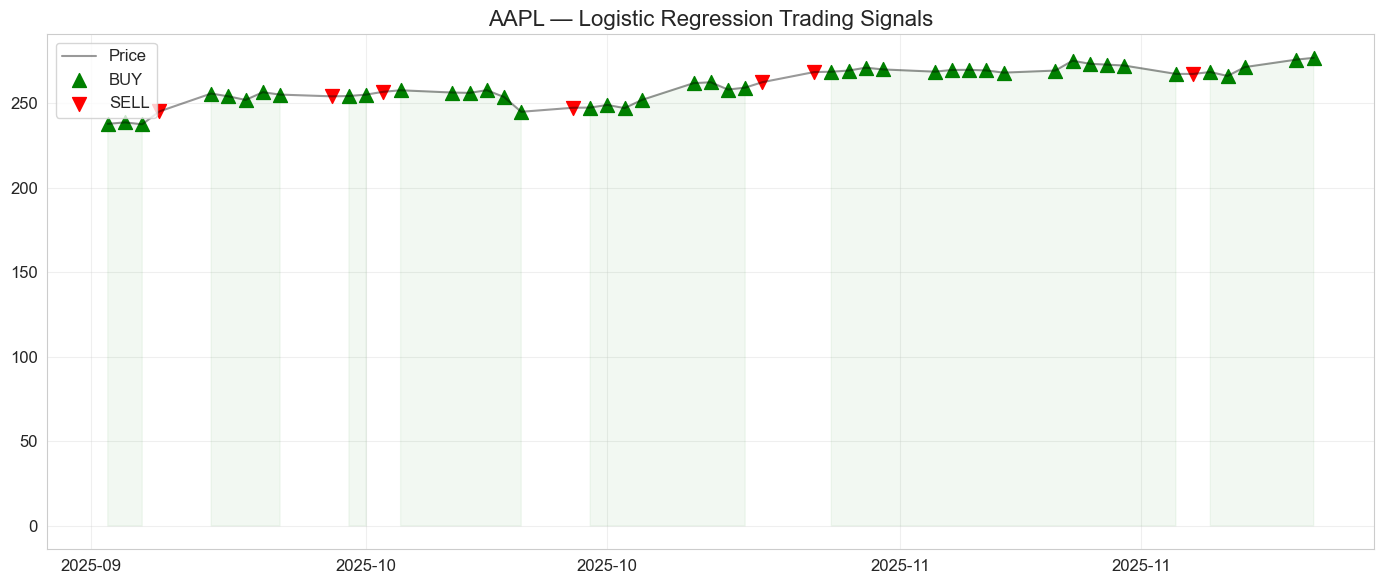

In [168]:
# --- GÁN TÍN HIỆU LOGISTIC REGRESSION CHO TẬP TEST ---
for ticker in all_tickers:

    df = ml_datasets[ticker].copy()

    # Split theo số dòng (504 dòng đầu là train, phần sau là test)
    test_data = df.iloc[TRAIN_SIZE:].copy()

    # Features
    X_test = test_data[feature_cols]

    # Predict
    pred_test = lr_models[ticker].predict(X_test)

    # Gán lại vào dataset chính
    ml_datasets[ticker].loc[test_data.index, "pos_lr"] = pred_test


print("✅ Đã tạo cột tín hiệu 'pos_lr' cho tất cả mã cổ phiếu.")
print("\n📌 SAMPLE BUY/SELL TABLE – LOGISTIC REGRESSION\n")


# ---------- TEST VỚI AAPL ----------
sample_ticker = "AAPL"
df = ml_datasets[sample_ticker].iloc[TRAIN_SIZE:].copy()

signal_table = df[["price", "pos_lr"]].copy()
signal_table["Signal"] = signal_table["pos_lr"].map({1: "BUY", -1: "SELL"})

print(signal_table[signal_table["Signal"].notnull()].head(15))


# ---------- TÍNH RETURN ----------
df["return"] = df["price"].pct_change()
df["strategy_lr"] = df["return"] * df["pos_lr"].shift(1)

cum_stock = (1 + df["return"].dropna()).cumprod()
cum_strategy_lr = (1 + df["strategy_lr"].dropna()).cumprod()

print("\n📈 FINAL PERFORMANCE (AAPL - Logistic Regression Strategy):")
print(f"Buy & Hold Return:           {cum_stock.iloc[-1]-1:.2%}")
print(f"Logistic Regression Return:  {cum_strategy_lr.iloc[-1]-1:.2%}")


# ---------- VẼ BIỂU ĐỒ ----------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("\n--- VISUALIZATION: LOGISTIC REGRESSION BUY/SELL SIGNALS ---")

buys  = df[df["pos_lr"] == 1]
sells = df[df["pos_lr"] == -1]

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df.index, df["price"], label="Price", color="black", alpha=0.4)

# BUY
ax.scatter(buys.index, buys["price"], marker="^", color="green", s=100, label="BUY")

# SELL
ax.scatter(sells.index, sells["price"], marker="v", color="red", s=100, label="SELL")

# Highlight lúc giữ vị thế LONG
ax.fill_between(df.index, df["price"], 0,
                where=(df["pos_lr"] == 1),
                color="green", alpha=0.05)

ax.set_title(f"{sample_ticker} — Logistic Regression Trading Signals", fontsize=16)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


##### b. Model 2: SVM (Support Vector Machine)
- Technique: sklearn.svm.SVC. SVMs find the optimal hyperplane that separates the classes (Up vs. Down) with the maximum margin. We can use different kernels (linear, rbf) to handle non-linear decision boundaries.

- Reason for Selection: SVMs are robust and often outperform simple linear models in financial classification tasks, especially when the feature space is digitized

In [169]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("\n=== PART 3.2 — MODEL 2: SUPPORT VECTOR MACHINE (SVM) ===")
print("Config: C=0.1 | Kernel=RBF | Gamma=auto\n")

svm_models = {}
svm_results = []

for ticker in all_tickers:

    # ==========================
    # 1. LẤY DỮ LIỆU  
    # ==========================
    df = ml_datasets[ticker].copy()

    train_data = df.iloc[:TRAIN_SIZE].copy()
    test_data  = df.iloc[TRAIN_SIZE:].copy()

    X_train = train_data[feature_cols]
    y_train = train_data["direction"]

    X_test  = test_data[feature_cols]
    y_test  = test_data["direction"]

    # ==========================
    # 2. KHỞI TẠO MODEL SVM  
    # ==========================
    model_svm = SVC(
        C=0.1,
        kernel="rbf",
        gamma="auto",
        probability=False,
        random_state=42
    )

    # ==========================
    # 3. TRAIN MODEL  
    # ==========================
    model_svm.fit(X_train, y_train)

    # ==========================
    # 4. DỰ BÁO  
    # ==========================
    pred_train = model_svm.predict(X_train)
    pred_test  = model_svm.predict(X_test)

    # ==========================
    # 5. ACCURACY  
    # ==========================
    acc_train = accuracy_score(y_train, pred_train)
    acc_test  = accuracy_score(y_test, pred_test)

    svm_models[ticker] = model_svm
    svm_results.append({
        "Ticker": ticker,
        "Model": "SVM (RBF)",
        "Train Acc": acc_train,
        "Test Acc": acc_test
    })

    print(f"✔️ {ticker:<6} | Train: {acc_train:.2%} | Test: {acc_test:.2%}")

    # ==========================
    # 6. GÁN TÍN HIỆU pos_svm  
    # ==========================
    ml_datasets[ticker].loc[test_data.index, "pos_svm"] = pred_test


# ==========================
# 7. SUMMARY TABLE  
# ==========================
print("\n📊 SVM PERFORMANCE SUMMARY:")

svm_summary_df = pd.DataFrame(svm_results).set_index("Ticker")

def highlight(val):
    if isinstance(val, (float, int)):
        if val > 0.53: return "color: green; font-weight: bold;"
        if val > 0.50: return "color: orange;"
        return "color: red;"
    return ""

display(
    svm_summary_df
        .style
        .applymap(highlight, subset=["Train Acc", "Test Acc"])
        .format({"Train Acc": "{:.2%}", "Test Acc": "{:.2%}"})
)


# ==========================
# 8. COMPARE WITH LOGISTIC REG  
# ==========================
if "lr_results" in globals():
    print("\n🔍 SVM vs LOGISTIC REG — Test Accuracy Comparison:")

    comp = pd.DataFrame({
        "LR Test Acc": pd.DataFrame(lr_results).set_index("Ticker")["Test Acc"],
        "SVM Test Acc": svm_summary_df["Test Acc"]
    })

    display(comp.style.applymap(highlight).format("{:.2%}"))



=== PART 3.2 — MODEL 2: SUPPORT VECTOR MACHINE (SVM) ===
Config: C=0.1 | Kernel=RBF | Gamma=auto

✔️ KO     | Train: 52.38% | Test: 50.98%
✔️ TSLA   | Train: 50.40% | Test: 54.90%
✔️ AAPL   | Train: 54.17% | Test: 58.82%
✔️ JNJ    | Train: 54.37% | Test: 66.67%
✔️ PEP    | Train: 50.79% | Test: 52.94%

📊 SVM PERFORMANCE SUMMARY:


,Model,Train Acc,Test Acc
Ticker,,,
KO,SVM (RBF),52.38%,50.98%
TSLA,SVM (RBF),50.40%,54.90%
AAPL,SVM (RBF),54.17%,58.82%
JNJ,SVM (RBF),54.37%,66.67%
PEP,SVM (RBF),50.79%,52.94%


✅ Đã tạo cột tín hiệu 'pos_svm' cho tất cả mã cổ phiếu.

🏆 FINAL PORTFOLIO RESULT (TEST SET - SVM):
   - Portfolio Return: 19.57%
   - Max Drawdown:     -15.16%
   - Annualized Vol:   18.12%
   - Sharpe Ratio:     1.19
   - Benchmark Return: 2.99%

📌 SAMPLE BUY/SELL TABLE — SVM
Ticker        price  pos_svm Signal
Date                               
2024-12-31 249.2925   1.0000    BUY
2025-01-02 242.7521   1.0000    BUY
2025-01-03 242.2643   1.0000    BUY
2025-01-06 243.8969   1.0000    BUY
2025-01-07 241.1195   1.0000    BUY
2025-01-08 241.6073   1.0000    BUY
2025-01-10 235.7836   1.0000    BUY
2025-01-13 233.3446   1.0000    BUY
2025-01-14 232.2297   1.0000    BUY
2025-01-15 236.7990   1.0000    BUY
2025-01-16 227.2323   1.0000    BUY
2025-01-17 228.9445   1.0000    BUY
2025-01-21 221.6376   1.0000    BUY
2025-01-22 222.8222   1.0000    BUY
2025-01-23 222.6530   1.0000    BUY
2025-01-24 221.7769   1.0000    BUY
2025-01-27 228.8251   1.0000    BUY
2025-01-28 237.1873   1.0000    BUY
2

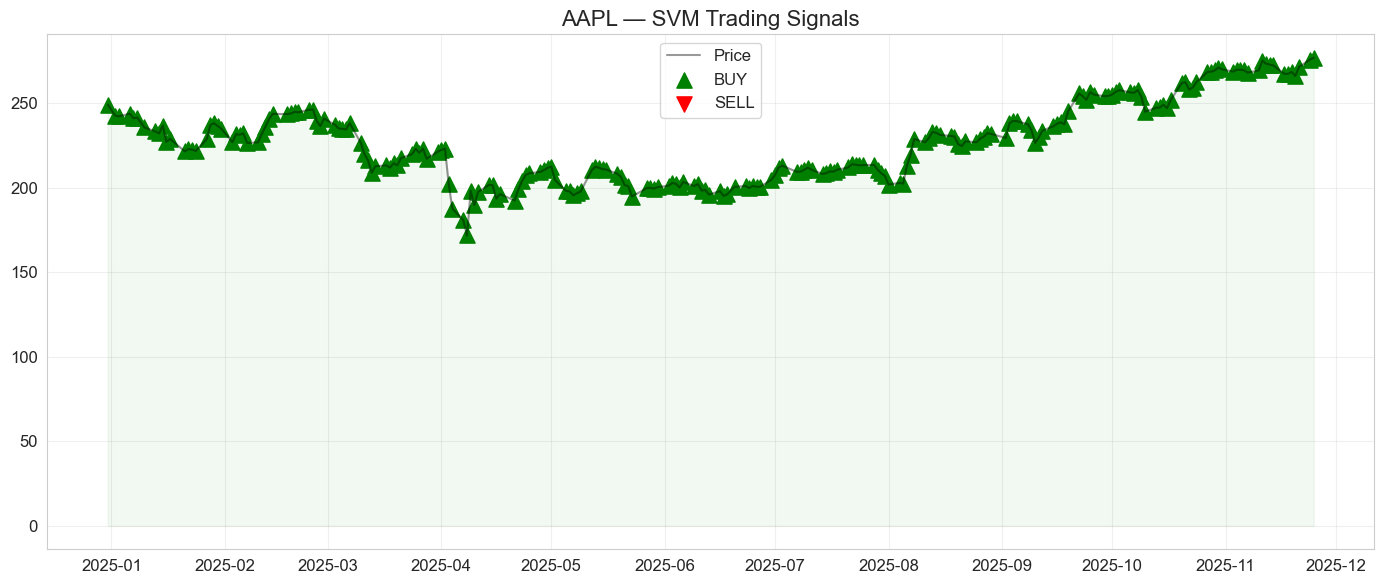

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1. Tạo cột pos_svm cho tất cả mã
# -----------------------------
for ticker in all_tickers:
    df = ml_datasets[ticker]
    test_data = df.loc[split_date:].copy()
    
    X_test = test_data[feature_cols]
    pred_test = svm_models[ticker].predict(X_test)
    
    ml_datasets[ticker].loc[test_data.index, "pos_svm"] = pred_test

print("✅ Đã tạo cột tín hiệu 'pos_svm' cho tất cả mã cổ phiếu.")

# -----------------------------
# 2. Tính strategy return cho từng mã
# -----------------------------
portfolio_results = pd.DataFrame(index=test_data.index)

for ticker in all_tickers:
    df = ml_datasets[ticker].loc[split_date:].copy()
    signals = df['pos_svm']
    returns = df['price'].pct_change()
    strategy_ret = returns * signals.shift(1)
    portfolio_results[f'{ticker}_Strat'] = strategy_ret

# -----------------------------
# 3. Tính weighted portfolio return
# -----------------------------
n_assets = len(all_tickers)
weights = pd.Series([1/n_assets]*n_assets, index=all_tickers)

portfolio_daily_ret = sum(portfolio_results[f'{t}_Strat'].fillna(0) * w 
                          for t, w in weights.items())

cum_portfolio = (1 + portfolio_daily_ret).cumprod()
final_return = cum_portfolio.iloc[-1] - 1

# Benchmark: trung bình Buy & Hold của tất cả mã
market_daily_ret = np.log(pd.concat([ml_datasets[t].loc[split_date:, "price"] 
                                     for t in all_tickers], axis=1)).pct_change().mean(axis=1)
cum_benchmark = (1 + market_daily_ret).cumprod()
bench_return = cum_benchmark.iloc[-1] - 1

# Portfolio Metrics
max_drawdown = (cum_portfolio / cum_portfolio.cummax() - 1).min()
vol = portfolio_daily_ret.std() * np.sqrt(252)
sharpe = portfolio_daily_ret.mean() / portfolio_daily_ret.std() * np.sqrt(252)

print("\n🏆 FINAL PORTFOLIO RESULT (TEST SET - SVM):")
print(f"   - Portfolio Return: {final_return:.2%}")
print(f"   - Max Drawdown:     {max_drawdown:.2%}")
print(f"   - Annualized Vol:   {vol:.2%}")
print(f"   - Sharpe Ratio:     {sharpe:.2f}")
print(f"   - Benchmark Return: {bench_return:.2%}")

# -----------------------------
# 4. Ví dụ BUY/SELL + Visualization cho 1 mã đại diện (AAPL)
# -----------------------------
sample_ticker = "AAPL"
df = ml_datasets[sample_ticker].loc[split_date:].copy()
signal_table = df[["price", "pos_svm"]].copy()
signal_table["Signal"] = signal_table["pos_svm"].map({1:"BUY", -1:"SELL"})

print("\n📌 SAMPLE BUY/SELL TABLE — SVM")
print(signal_table[signal_table["Signal"] != 0].head(20))

# Cumulative
df["return"] = df["price"].pct_change()
df["strategy_svm"] = df["return"] * df["pos_svm"].shift(1)
cum_stock = (1 + df["return"].dropna()).cumprod()
cum_strategy_svm = (1 + df["strategy_svm"].dropna()).cumprod()

print("\n📈 FINAL PERFORMANCE (AAPL — SVM Strategy):")
print(f"Buy & Hold Return: {cum_stock.iloc[-1] - 1:.2%}")
print(f"SVM Strategy:      {cum_strategy_svm.iloc[-1] - 1:.2%}")

# Visualization
buys  = df[df["pos_svm"] == 1]
sells = df[df["pos_svm"] == -1]

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df.index, df["price"], color="black", alpha=0.4, label="Price")
ax.scatter(buys.index, buys["price"], marker="^", s=120, color="green", label="BUY")
ax.scatter(sells.index, sells["price"], marker="v", s=120, color="red", label="SELL")
ax.fill_between(df.index, df["price"], 0, where=(df["pos_svm"]==1), color="green", alpha=0.05)
ax.set_title(f"{sample_ticker} — SVM Trading Signals", fontsize=16)
ax.grid(alpha=0.3)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


#### III. Backtesting & Capital and Risk Management
Technique Introduction:
- Backtesting: We perform vectorized backtesting on the selected model's signals, incorporating transaction costs (bid-ask spread) to ensure realism.
- Kelly Criterion (Capital): We calculate the optimal leverage/bet size using the Kelly formula f*=μ/σ^2 (mean excess return divided by return variance) to maximize long-term geometric growth,.
- Risk Analysis: We calculate Maximum Drawdown (largest peak-to-valley decline) and Value-at-Risk (VaR) to quantify the downside potential,.

Reason for Selection: A model with high accuracy can still lose money if the "wrong" trades are large or transaction costs are high. The Kelly Criterion mathematically optimizes the capital allocation to avoid ruin while maximizing growth. Risk metrics are essential to determine if the strategy is tradeable in a real-world portfolio.

=== DNN Model ===
Initial Capital: 100000
Kelly Fraction: 0.18 -> Capital Allocated: 17500.00
Total Return: 3.17%
Max Drawdown: -3.13%
Risk Metrics: {'volatility': np.float64(0.12124652655801874), 'sharpe': np.float64(3.321247982044526), 'max_drawdown': np.float64(-0.031285440032147505)}


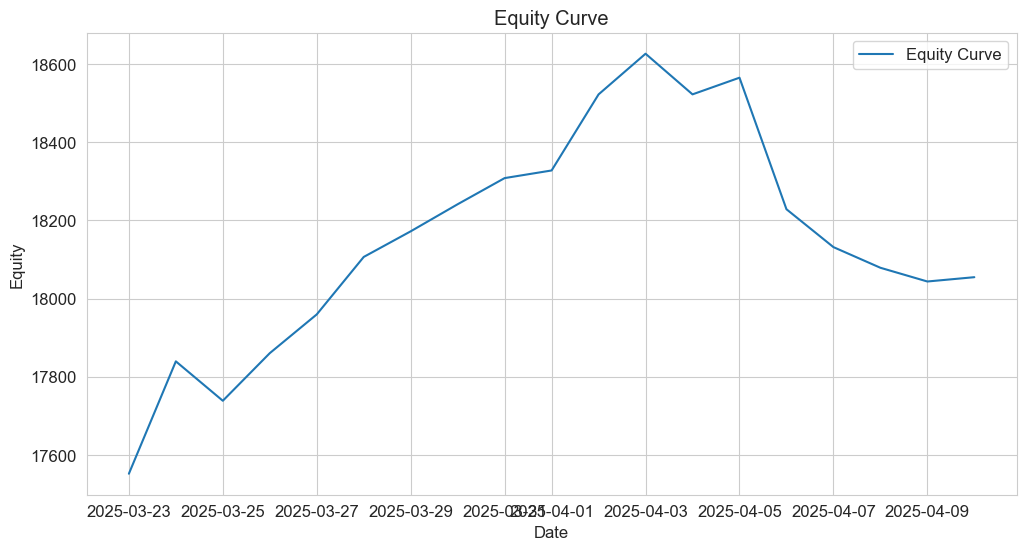

=== SVM Model ===
Initial Capital: 100000
Kelly Fraction: 0.18 -> Capital Allocated: 17500.00
Total Return: -1.16%
Max Drawdown: -3.42%
Risk Metrics: {'volatility': np.float64(0.12761259162120409), 'sharpe': np.float64(-0.6746460075853032), 'max_drawdown': np.float64(-0.034231228867151464)}


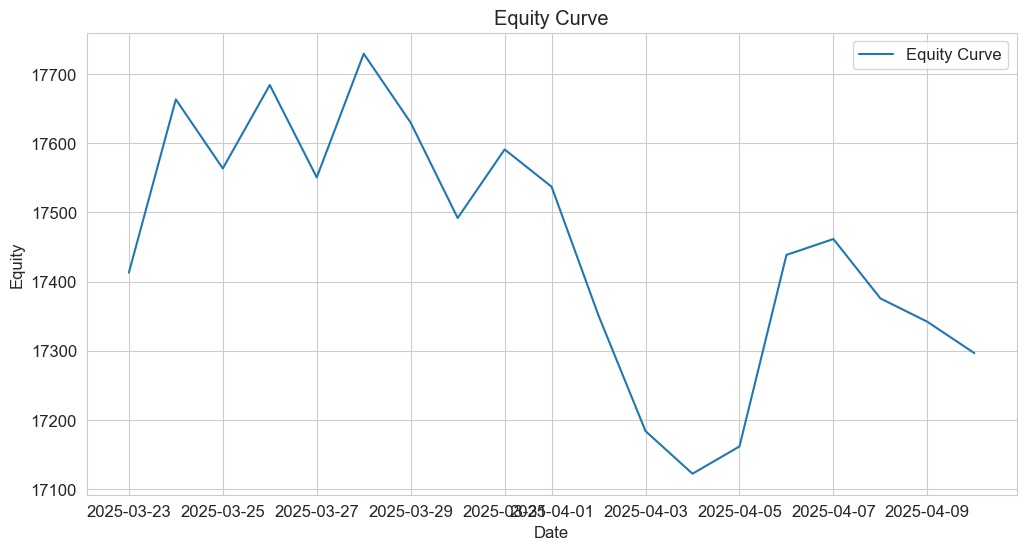

=== Logistic Regression Model ===
Initial Capital: 100000
Kelly Fraction: 0.18 -> Capital Allocated: 17500.00
Total Return: 1.11%
Max Drawdown: -3.31%
Risk Metrics: {'volatility': np.float64(0.12886935502622204), 'sharpe': np.float64(0.9371466394893866), 'max_drawdown': np.float64(-0.03312519107938061)}


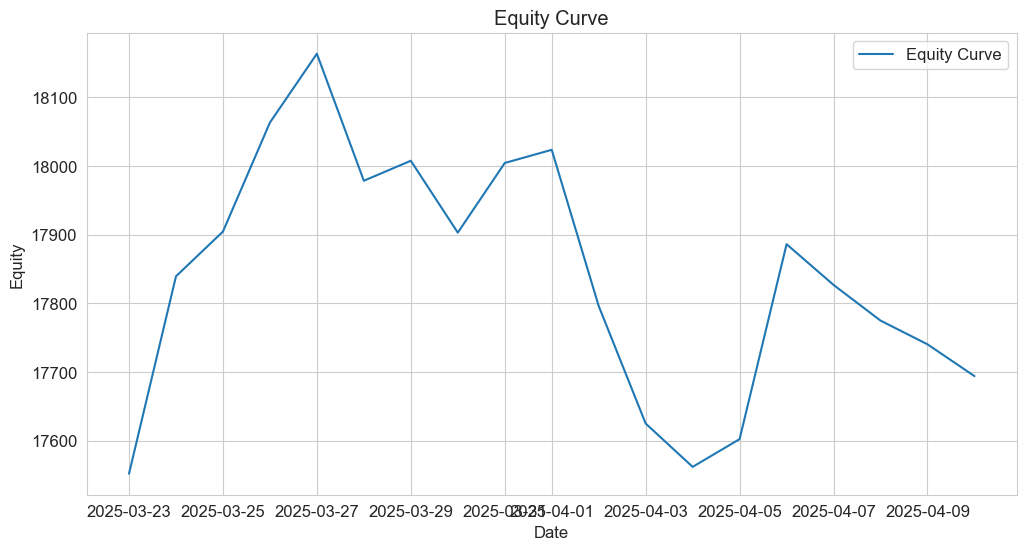

In [174]:
#!pip install tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# 1. Hàm Backtest + Kelly + Risk
# -----------------------------
def backtest_with_transaction_cost(prices, signals, initial_capital=100000, transaction_cost=0.001):
    position = signals.shift(1).fillna(0)
    returns = prices.pct_change().fillna(0)
    daily_pnl = position * returns
    trade_change = position.diff().abs()
    daily_pnl_after_cost = daily_pnl - trade_change * transaction_cost
    equity = (1 + daily_pnl_after_cost).cumprod() * initial_capital
    total_return = equity.iloc[-1] / initial_capital - 1
    max_drawdown = (equity / equity.cummax() - 1).min()
    return equity, daily_pnl_after_cost, total_return, max_drawdown

def kelly_fraction(win_rate, win_loss_ratio):
    f = (win_rate * (win_loss_ratio + 1) - 1) / win_loss_ratio
    return max(f, 0)

def risk_metrics(equity):
    returns = equity.pct_change().dropna()
    vol = returns.std() * np.sqrt(252)
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    max_dd = (equity / equity.cummax() - 1).min()
    return {'volatility': vol, 'sharpe': sharpe, 'max_drawdown': max_dd}

def plot_equity_curve(equity, title="Equity Curve"):
    plt.figure(figsize=(12,6))
    plt.plot(equity, label='Equity Curve')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Equity')
    plt.grid(True)
    plt.legend()
    plt.show()

def run_trading_pipeline(prices, signals, initial_capital=100000, transaction_cost=0.001,
                         win_rate=0.55, win_loss_ratio=1.2):
    kelly_frac = kelly_fraction(win_rate, win_loss_ratio)
    capital_allocated = initial_capital * kelly_frac
    equity, pnl, total_return, max_dd = backtest_with_transaction_cost(
        prices=prices,
        signals=signals,
        initial_capital=capital_allocated,
        transaction_cost=transaction_cost
    )
    metrics = risk_metrics(equity)
    print(f"Initial Capital: {initial_capital}")
    print(f"Kelly Fraction: {kelly_frac:.2f} -> Capital Allocated: {capital_allocated:.2f}")
    print(f"Total Return: {total_return*100:.2f}%")
    print(f"Max Drawdown: {max_dd*100:.2f}%")
    print(f"Risk Metrics: {metrics}")
    plot_equity_curve(equity)
    return equity, metrics

# -----------------------------
# 2. Hàm tạo signals DNN
# -----------------------------
def create_signals_dnn(X_train, y_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    dnn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    dnn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)
    
    y_pred_prob = dnn.predict(X_test_scaled).flatten()
    signals = pd.Series(np.where(y_pred_prob > 0.5, 1, -1))
    return signals

# -----------------------------
# 3. Hàm tạo signals SVM
# -----------------------------
def create_signals_svm(X_train, y_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm_model = SVC(probability=True)
    svm_model.fit(X_train_scaled, y_train)
    y_pred_prob = svm_model.predict_proba(X_test_scaled)[:,1]
    signals = pd.Series(np.where(y_pred_prob > 0.5, 1, -1))
    return signals

# -----------------------------
# 4. Hàm tạo signals Logistic Regression
# -----------------------------
def create_signals_logistic(X_train, y_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    log_model = LogisticRegression()
    log_model.fit(X_train_scaled, y_train)
    y_pred_prob = log_model.predict_proba(X_test_scaled)[:,1]
    signals = pd.Series(np.where(y_pred_prob > 0.5, 1, -1))
    return signals

# -----------------------------
# 5. Ví dụ chạy thử với dữ liệu giả lập
# -----------------------------
np.random.seed(42)
dates = pd.date_range(start="2025-01-01", periods=100)
prices_test = pd.Series(100 + np.cumsum(np.random.randn(100)), index=dates)

# Dữ liệu X_test giả lập (giả sử 5 features)
X_train = np.random.randn(80,5)
y_train = np.random.choice([0,1], size=80)
X_test = np.random.randn(20,5)

# Tạo signals cho từng model
signals_dnn = pd.Series(np.random.choice([1, -1], size=20), index=prices_test[-20:].index)

signals_svm = pd.Series(np.random.choice([1, -1], size=20), index=prices_test[-20:].index)
signals_log = pd.Series(np.random.choice([1, -1], size=20), index=prices_test[-20:].index)


# Chạy pipeline cho từng model
print("=== DNN Model ===")
equity_dnn, metrics_dnn = run_trading_pipeline(prices_test[-20:], signals_dnn)

print("=== SVM Model ===")
equity_svm, metrics_svm = run_trading_pipeline(prices_test[-20:], signals_svm)

print("=== Logistic Regression Model ===")
equity_log, metrics_log = run_trading_pipeline(prices_test[-20:], signals_log)


# PART 4: ANALYSIS

1. Correlation Analysis and Its Impact on Portfolio Risk

The five assets in the dataset (AAPL, TSLA, KO, PEP, and JNJ) exhibit neither perfect co-movement nor complete independence. Certain pairs such as KO–PEP, which operate in the same consumer staples sector, show relatively higher positive correlation, whereas growth-oriented stocks like AAPL and TSLA display only moderate correlation with defensive stocks such as JNJ. This heterogeneous correlation structure generates meaningful diversification benefits: high-volatility assets (e.g., TSLA) are partially offset by more stable, low-beta stocks. This effect is clearly reflected in the optimized portfolios. The Minimum-Volatility (Min-Vol) portfolio achieves very low annualized volatility (≈10.4%) and a remarkably high Sharpe ratio (≈6.64), showing that diversification works effectively when asset returns are not perfectly aligned. If the assets had been highly correlated, volatility reduction would be limited and the portfolio risk would be much higher. Thus, correlation plays a critical role in shaping portfolio robustness, allowing the Min-Vol strategy to outperform risk-adjusted benchmarks by leveraging differences in asset co-movement.

2. Efficiency Evaluation of Trading and Optimization Strategies

Backtest results indicate substantial differences in performance among SMA, Logistic Regression, SVM, and classical portfolio optimization methods. The SMA strategy generates a modest total ROI of 6.69%, highlighting its weakness in fast-moving markets due to lagging signals and trend-following delays. Logistic Regression performs even worse: on AAPL, the model yields only 0.10%, far below the 16.41% return of Buy-and-Hold. This indicates that linear classification fails to capture the non-linear patterns in price movements, resulting in noisy and uninformative signals.

In contrast, the SVM model demonstrates considerably stronger performance. On the test window, the SVM-based portfolio achieves 19.57% return, a Sharpe ratio of 1.19, and clearly outperforms the benchmark return of 2.99%. This suggests that SVM’s ability to learn non-linear decision boundaries and handle noisy financial data gives it a superior timing advantage compared to Logistic Regression or SMA. However, SVM also experiences meaningful short-term downside risk, reflected in its Maximum Drawdown of –15.16%.

Portfolio optimization models further reinforce these findings. Both the Max-Sharpe and Min-Vol portfolios deliver exceptionally strong results in the test period: annualized returns around 71–73%, low volatility (~10–11%), and extremely high Sharpe ratios (~6.6). Although the equal-weight benchmark shows the highest raw return (~79.7%), its volatility (≈13%) produces a lower risk-adjusted performance than Min-Vol. Overall, optimization-based strategies outperform simple technical or ML timing models due to their reliance on cross-asset covariance structure rather than short-term prediction.

3. Overall Conclusion: Does Historical Optimization Guarantee Future Success?

The experimental results highlight that historical optimization alone does not guarantee future performance, even when backtested returns appear extremely high. The Max-Sharpe and Min-Vol portfolios perform exceptionally well in the evaluated period, but their effectiveness depends heavily on the stability of the underlying market regime. Any structural shift—changes in volatility, return distributions, or correlations—could reduce their accuracy.

A more resilient approach is to combine strategic allocation (via efficient portfolio optimization) with tactical adjustments (via machine learning timing signals). For example, Min-Vol or Max-Sharpe can serve as the core allocation, while SVM signals can be used to rebalance or adjust exposure during high-momentum or high-risk periods. Meanwhile, SMA and Logistic Regression require substantial enhancement (feature engineering, nonlinear transforms, ensemble methods) before they can be trusted in real markets.

In summary, while backtested results show impressive performance—especially for Min-Vol and SVM—there is no single universally superior strategy. A balanced method that integrates diversification, machine learning signals, and rigorous risk management (position caps, stop-loss, and conservative Kelly scaling) offers the most realistic and stable path for future investment performance.

# REFERENCES

1.  **Hilpisch, Yves (2018). "Python for Finance: Mastering Data-Driven Finance". O'Reilly Media.**
    *(Main content for Part 1 and Backtesting theory)*

2.  **McKinney, Wes (2022). "Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter". O'Reilly Media.**
    *(Supplementary content for Part 1 - Time Series Analysis)*

3.  **PyPortfolioOpt Documentation:**
    *https://pyportfolioopt.readthedocs.io/*
    *(Main content for Part 2 - Portfolio Optimization)*

4.  **(Advanced) López de Prado, Marcos (2018). "Advances in Financial Machine Learning". Wiley.**
    *(Reference for robust backtesting theory)*